/Users/Eric/.pyenv/versions/general312/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Selected top 90 genes by |Spearman rho| with VG at Day 15.
Day  1: Q_obs = 0.083 | null = 0.184 ± 0.012 | z = -8.20 | p = 1.0000 | boot = 0.128 ± 0.043 (95% CI [0.058, 0.223])
Day  3: Q_obs = 0.112 | null = 0.182 ± 0.013 | z = -5.51 | p = 1.0000 | boot = 0.159 ± 0.046 (95% CI [0.087, 0.261])
Day  6: Q_obs = 0.180 | null = 0.185 ± 0.014 | z = -0.35 | p = 0.6350 | boot = 0.214 ± 0.058 (95% CI [0.127, 0.346])
Day 10: Q_obs = 0.237 | null = 0.182 ± 0.012 | z =  4.42 | p = 0.0000 | boot = 0.248 ± 0.039 (95% CI [0.178, 0.330])
Day 15: Q_obs = 0.213 | null = 0.184 ± 0.013 | z =  2.31 | p = 0.0100 | boot = 0.221 ± 0.045 (95% CI [0.141, 0.310])

Saved: modularity_with_null_and_CI.csv
Saved: modularity_panel_A_observed_vs_null.png


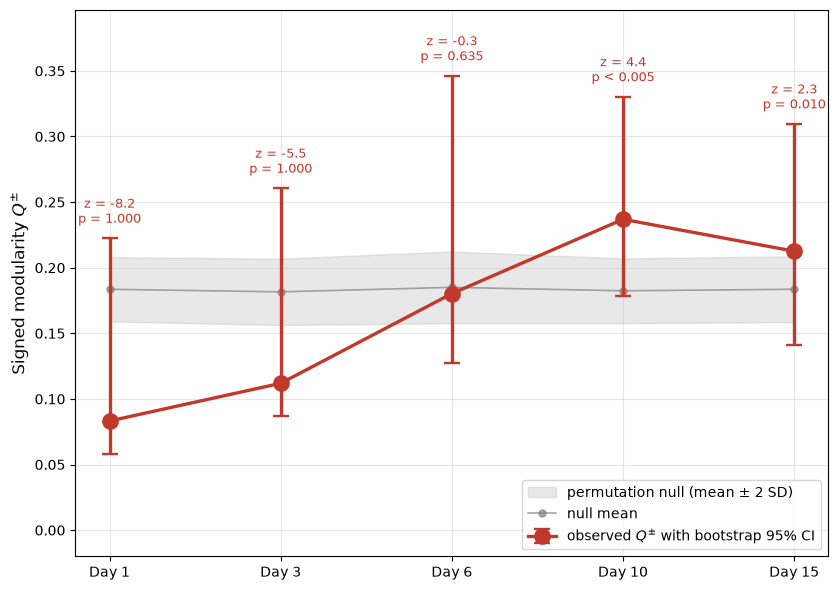


=== Summary ===
 Day  Q_observed  null_mean  null_sd  Q_z_score  p_empirical  boot_mean  boot_sd  boot_CI_lo  boot_CI_hi
   1       0.083      0.184    0.012     -8.201        1.000      0.128    0.043       0.058       0.223
   3       0.112      0.182    0.013     -5.513        1.000      0.159    0.046       0.087       0.261
   6       0.180      0.185    0.014     -0.350        0.635      0.214    0.058       0.127       0.346
  10       0.237      0.182    0.012      4.418        0.000      0.248    0.039       0.178       0.330
  15       0.213      0.184    0.013      2.312        0.010      0.221    0.045       0.141       0.310


In [1]:
#Figure 1A

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, rankdata, norm

# ============================================================
# Configuration
# ============================================================
DATA_PATH = "Expression_raw_v1.xlsx"
AGE_COL = "Age (Days)"
PROTEIN_SUBSTR = "Vg protein"
DAYS = [1, 3, 6, 10, 15]
N_TOP = 90

N_PERMUTATIONS = 200       # null distribution size per day
N_BOOTSTRAP = 200          # bootstrap resamples for CI per day
RANDOM_STATE = 42

OUTPUT_FIG_A = "modularity_panel_A_observed_vs_null.png"
OUTPUT_FIG_B = "modularity_panel_B_distributions.png"
OUTPUT_CSV = "modularity_with_null_and_CI.csv"


# ============================================================
# Load data and select top-N genes by |Spearman rho| with VG at Day 15
# ============================================================
df = pd.read_excel(DATA_PATH)

cols = [c for c in df.columns if PROTEIN_SUBSTR in str(c)]
protein_col = ([c for c in cols if "normalized" in str(c).lower()] or cols)[0]
gene_cols = [c for c in df.select_dtypes(include=[np.number]).columns
             if c not in [AGE_COL, protein_col]]

day15 = df[df[AGE_COL] == 15]
vg15 = day15[protein_col].values
rankings = []
for g in gene_cols:
    g_vals = day15[g].values
    if np.std(g_vals) > 1e-12:
        r, _ = spearmanr(g_vals, vg15)
        rankings.append((g, abs(r)))
    else:
        rankings.append((g, 0.0))
top_genes = [g for g, _ in
             sorted(rankings, key=lambda x: x[1], reverse=True)[:N_TOP]]
print(f"Selected top {N_TOP} genes by |Spearman rho| with VG at Day 15.")


# ============================================================
# Spearman correlation matrix (fast path: rank-then-Pearson)
# ============================================================
def spearman_corr(X):
    n_samples, n_features = X.shape
    ranked = np.apply_along_axis(rankdata, 0, X)
    std = ranked.std(axis=0, ddof=0)
    rho = np.zeros((n_features, n_features))
    valid = std > 1e-12
    if valid.all():
        rho = np.corrcoef(ranked, rowvar=False)
    else:
        sub = ranked[:, valid]
        c = np.corrcoef(sub, rowvar=False)
        idx = np.where(valid)[0]
        rho[np.ix_(idx, idx)] = c
    np.fill_diagonal(rho, 0.0)
    return rho


# ============================================================
# Greedy signed-modularity detection (same as Figure 5)
# ============================================================
def build_signed_modularity_matrix(W):
    W = np.asarray(W, dtype=float)
    Wp = np.clip(W, 0, None)
    Wn = np.clip(-W, 0, None)
    wp = Wp.sum(axis=1); wn = Wn.sum(axis=1)
    twp = wp.sum() if wp.sum() != 0 else 1.0
    twn = wn.sum() if wn.sum() != 0 else 1.0
    B = W - np.outer(wp, wp) / twp + np.outer(wn, wn) / twn
    return B, twp, twn


def signed_Q(B, twp, twn, communities):
    denom = twp + twn
    if denom == 0:
        return 0.0
    Q = 0.0
    for comm in communities:
        idx = np.ix_(comm, comm)
        Q += B[idx].sum()
    return float(Q / denom)


def greedy_signed(W, max_iter=1000, tol=1e-10):
    """Greedy agglomerative signed modularity maximization.
    Vectorized via the community-aggregated B matrix:
        S_ab = sum_{i in a, j in b} B_ij
    Merging communities a, b changes Q by 2 * S_ab / denom, so we can
    pick the best merge by scanning S without recomputing Q from scratch.
    """
    n = W.shape[0]
    B, twp, twn = build_signed_modularity_matrix(W)
    denom = twp + twn
    if denom == 0:
        return [list(range(n))], 0.0

    # Initially each node is its own community: S_ab = B_ab.
    # The diagonal S_aa = B_aa carries the within-community contribution.
    S = B.copy()
    # community membership: list of node lists
    communities = [[i] for i in range(n)]
    active = np.ones(n, dtype=bool)
    curr_Q = np.trace(S) / denom

    for _ in range(max_iter):
        # delta_Q from merging communities a,b is 2 * S[a,b] / denom
        # (off-diagonal sums double when within-community sum absorbs them).
        S_off = S.copy()
        np.fill_diagonal(S_off, -np.inf)
        # mask inactive rows/cols
        S_off[~active, :] = -np.inf
        S_off[:, ~active] = -np.inf
        idx = np.unravel_index(np.argmax(S_off), S_off.shape)
        a, b = idx
        best_delta = 2.0 * S[a, b] / denom
        if best_delta <= tol:
            break

        # Merge b into a: S[a,:] += S[b,:]; S[:,a] += S[:,b]
        S[a, :] += S[b, :]
        S[:, a] += S[:, b]
        # Deactivate community b
        active[b] = False
        S[b, :] = -np.inf
        S[:, b] = -np.inf
        # Move members of b into a
        communities[a].extend(communities[b])
        communities[b] = []
        curr_Q += best_delta

    final = [c for c in communities if c]
    # Recompute Q from scratch for numerical certainty
    final_Q = signed_Q(B, twp, twn, final)
    return final, final_Q


# ============================================================
# Helper: compute optimized Q+- on a given expression matrix
# ============================================================
def Q_from_expression(X):
    """Compute Spearman corr matrix on X, run greedy detection, return Q+-."""
    R = spearman_corr(X)
    W = (R + R.T) / 2.0
    np.fill_diagonal(W, 0.0)
    _, Q = greedy_signed(W)
    return Q


# ============================================================
# Compute observed Q, permutation null, bootstrap CI for each day
# ============================================================
rng = np.random.default_rng(RANDOM_STATE)

records = []
null_dists = {}
boot_dists = {}

for day in DAYS:
    day_df = df[df[AGE_COL] == day].reset_index(drop=True)
    X_full = day_df[top_genes].values.astype(float)
    n_samples = X_full.shape[0]

    # Observed Q
    Q_obs = Q_from_expression(X_full)

    # Permutation null: shuffle each column (gene) independently.
    # This destroys all gene-gene correlations while preserving
    # marginal expression distributions.
    null_Q = np.zeros(N_PERMUTATIONS)
    for b in range(N_PERMUTATIONS):
        Xp = X_full.copy()
        for g in range(Xp.shape[1]):
            Xp[:, g] = rng.permutation(Xp[:, g])
        try:
            null_Q[b] = Q_from_expression(Xp)
        except Exception:
            null_Q[b] = 0.0
    null_dists[day] = null_Q

    null_mean = null_Q.mean()
    null_sd = null_Q.std(ddof=1)
    z = (Q_obs - null_mean) / null_sd if null_sd > 0 else np.nan
    p_emp = float((null_Q >= Q_obs).mean())  # one-sided

    # Bootstrap CI: resample bees with replacement.
    boot_Q = np.zeros(N_BOOTSTRAP)
    for b in range(N_BOOTSTRAP):
        idx = rng.integers(0, n_samples, size=n_samples)
        Xb = X_full[idx]
        if np.any(np.std(Xb, axis=0) < 1e-12):
            boot_Q[b] = np.nan
            continue
        try:
            boot_Q[b] = Q_from_expression(Xb)
        except Exception:
            boot_Q[b] = np.nan
    boot_dists[day] = boot_Q

    boot_clean = boot_Q[np.isfinite(boot_Q)]
    boot_mean = boot_clean.mean()
    boot_sd = boot_clean.std(ddof=1)
    ci_lo, ci_hi = np.percentile(boot_clean, [2.5, 97.5])

    records.append({
        "Day": day,
        "Q_observed": Q_obs,
        "null_mean": null_mean,
        "null_sd": null_sd,
        "Q_z_score": z,
        "p_empirical": p_emp,
        "boot_mean": boot_mean,
        "boot_sd": boot_sd,
        "boot_CI_lo": ci_lo,
        "boot_CI_hi": ci_hi,
    })

    print(f"Day {day:>2}: Q_obs = {Q_obs:.3f} | "
          f"null = {null_mean:.3f} ± {null_sd:.3f} | "
          f"z = {z:5.2f} | p = {p_emp:.4f} | "
          f"boot = {boot_mean:.3f} ± {boot_sd:.3f} "
          f"(95% CI [{ci_lo:.3f}, {ci_hi:.3f}])")

results = pd.DataFrame(records)
results.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved: {OUTPUT_CSV}")

 
# ============================================================
# Figure A: observed Q +/- bootstrap CI vs permutation null band
# ============================================================
fig, ax = plt.subplots(figsize=(8.5, 6))
xs = np.arange(len(DAYS))
 
null_mu = results["null_mean"].values
null_sd = results["null_sd"].values
ax.fill_between(
    xs, null_mu - 2 * null_sd, null_mu + 2 * null_sd,
    color="gray", alpha=0.18, label="permutation null (mean ± 2 SD)",
)
ax.plot(xs, null_mu, "o-", color="gray", lw=1.2, ms=5,
        alpha=0.7, label="null mean")
 
boot_mu = results["boot_mean"].values
boot_lo = results["boot_CI_lo"].values
boot_hi = results["boot_CI_hi"].values
yerr = np.vstack([results["Q_observed"] - boot_lo,
                  boot_hi - results["Q_observed"]])
 
ax.errorbar(
    xs, results["Q_observed"], yerr=yerr,
    fmt="o-", color="#c0392b", lw=2.4, ms=11,
    capsize=6, capthick=1.7,
    label=r"observed $Q^{\pm}$ with bootstrap 95% CI",
)
 
for i, (z, p) in enumerate(zip(results["Q_z_score"], results["p_empirical"])):
    if p < 1.0 / N_PERMUTATIONS:
        label = f"z = {z:.1f}\np < {1.0/N_PERMUTATIONS:.3f}"
    else:
        label = f"z = {z:.1f}\np = {p:.3f}"
    ax.annotate(
        label,
        xy=(xs[i], boot_hi[i]),          # top of the error bar
        xytext=(0, 8), textcoords="offset points",
        ha="center", va="bottom",        # grow upward from the anchor
        fontsize=9, color="#c0392b",
    )

 
ax.set_xticks(xs)
ax.set_xticklabels([f"Day {d}" for d in DAYS])
ax.set_ylabel(r"Signed modularity $Q^{\pm}$", fontsize=12)
ax.set_title(
    "",
    fontsize=12,)
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
#ymax = max(results["Q_observed"].max(),(null_mu + 2 * null_sd).max()) + 0.07
ymax = max(boot_hi.max(), (null_mu + 2 * null_sd).max()) + 0.05
ax.set_ylim(-0.02, ymax)
plt.tight_layout()
plt.savefig(OUTPUT_FIG_A, dpi=200, bbox_inches="tight")
print(f"Saved: {OUTPUT_FIG_A}")
plt.show()
 
 
print("\n=== Summary ===")
print(results.round(3).to_string(index=False))

/Users/Eric/.pyenv/versions/general312/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Using all 90 genes (N_TOP = 90; ranking does not remove any gene).
Day  1: lambda1 = 0.067 | null 0.506±0.022 | z = -19.67 | p(lower) = 0.0010 | boot 95% CI [0.036, 0.180]
        gap (l2-l1) = 0.557 | null 0.048±0.027 | z = +19.01 | p(upper) = 0.0010
        lambda3 = 0.751 | null 0.592±0.015 | z = +10.53 | p(two-sided) = 0.0010 | boot 95% CI [0.579, 0.820]
        gap (l3-l2) = 0.127 | null 0.038±0.020 | z = +4.41 | p(upper) = 0.0010
Day  3: lambda1 = 0.083 | null 0.506±0.023 | z = -18.54 | p(lower) = 0.0010 | boot 95% CI [0.042, 0.229]
        gap (l2-l1) = 0.491 | null 0.050±0.027 | z = +16.57 | p(upper) = 0.0010
        lambda3 = 0.737 | null 0.593±0.015 | z = +9.76 | p(two-sided) = 0.0010 | boot 95% CI [0.536, 0.813]
        gap (l3-l2) = 0.163 | null 0.038±0.020 | z = +6.34 | p(upper) = 0.0010
Day  6: lambda1 = 0.151 | null 0.505±0.022 | z = -16.32 | p(lower) = 0.0010 | boot 95% CI [0.064, 0.260]
        gap (l2-l1) = 0.369 | null 0.048±0.025 | z = +12.59 | p(upper) = 0.0010
   

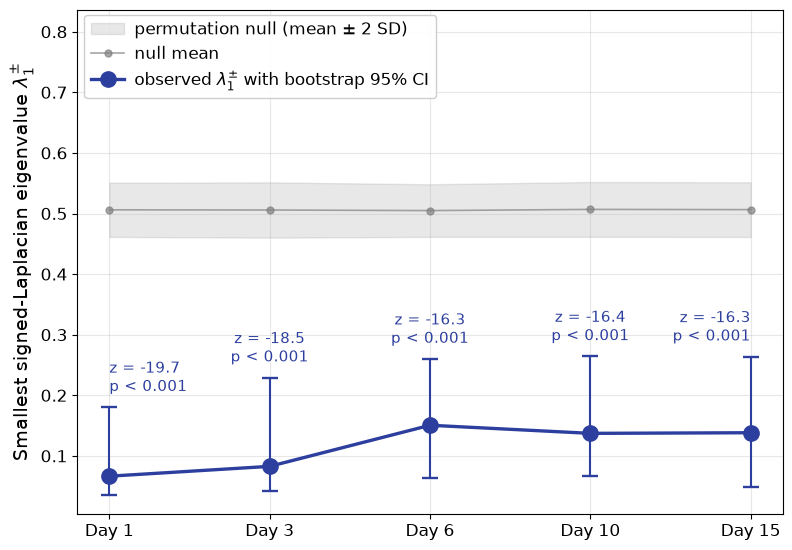

Saved: lambda21_panel_C_spectral_gap.png


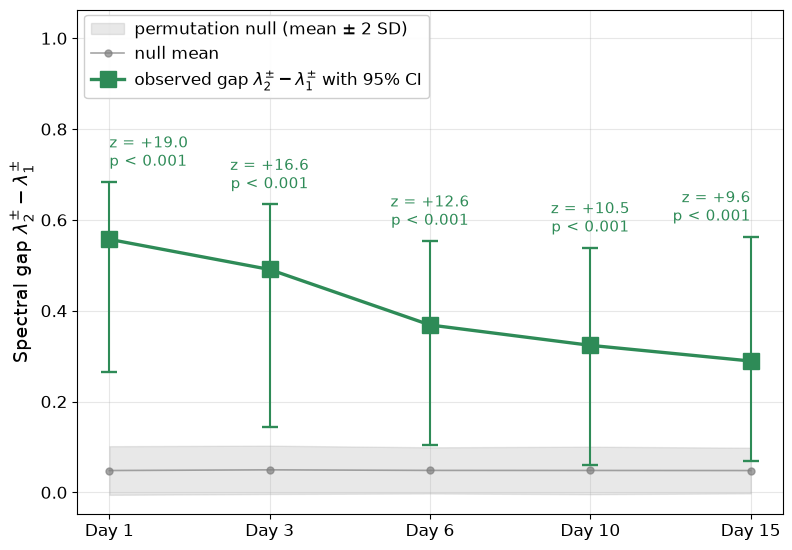

Saved: lambda3_panel_B_observed_vs_null.png


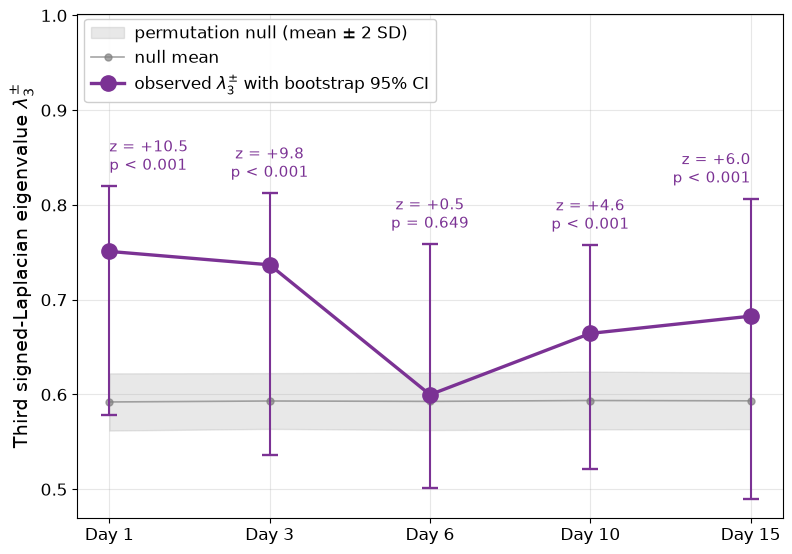

Saved: lambda32_panel_D_spectral_gap.png


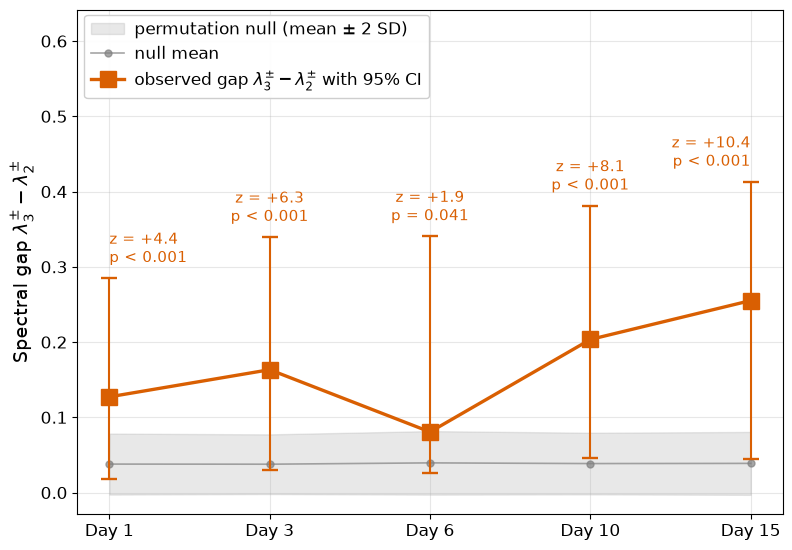

In [2]:
# Figures 1B, 1C + additional lambda_3 and lambda_3-lambda_2 figures

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, rankdata
from scipy.linalg import eigh

# ============================================================
# Configuration
# ============================================================
DATA_PATH = "Expression_raw_v1.xlsx"
AGE_COL = "Age (Days)"
PROTEIN_SUBSTR = "Vg protein"
DAYS = [1, 3, 6, 10, 15]
N_TOP = 90

N_PERMUTATIONS = 1000
N_BOOTSTRAP = 1000
RANDOM_STATE = 42

# Keep the old output-variable notation.
# A = lambda_1
# B = lambda_3
# C = lambda_2 - lambda_1
# D = lambda_3 - lambda_2
OUTPUT_FIG_A = "lambda1_panel_A_observed_vs_null.png"
OUTPUT_FIG_B = "lambda3_panel_B_observed_vs_null.png"
OUTPUT_FIG_C = "lambda21_panel_C_spectral_gap.png"
OUTPUT_FIG_D = "lambda32_panel_D_spectral_gap.png"
OUTPUT_CSV = "signed_spectrum_with_null_and_CI.csv"

# Global font sizes
plt.rcParams.update({
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})


# ============================================================
# Spearman correlation matrix
# ============================================================
def spearman_corr(X):
    ranked = np.apply_along_axis(rankdata, 0, X)

    # Return None if a bootstrap resample makes a gene constant.
    if np.any(np.std(ranked, axis=0) < 1e-12):
        return None

    rho = np.corrcoef(ranked, rowvar=False)
    np.fill_diagonal(rho, 0.0)
    return rho


# ============================================================
# Signed normalized Laplacian and its first three eigenvalues
# ============================================================
def signed_lambda2_lambda3(W):
    """
    Retain the original function name for notebook compatibility.

    Returns (lambda_1, lambda_2, lambda_3) of the symmetric
    normalized signed Laplacian

        L_sym = I - Dbar^{-1/2} W Dbar^{-1/2}

    where Dbar_jj = sum_k |W_jk|.
    """
    n = W.shape[0]

    dbar = np.sum(np.abs(W), axis=1)
    invsqrt = np.where(
        dbar > 1e-12,
        1.0 / np.sqrt(np.maximum(dbar, 1e-12)),
        0.0
    )

    Dh = np.diag(invsqrt)
    Lsym = np.eye(n) - Dh @ W @ Dh
    Lsym = (Lsym + Lsym.T) / 2.0

    vals = eigh(Lsym, eigvals_only=True)
    vals = np.sort(np.real(vals))

    return float(vals[0]), float(vals[1]), float(vals[2])


def lambda23_from_expression(X):
    """
    Retain the original function name for notebook compatibility.

    Returns:
        lambda_1, lambda_2, lambda_3
    """
    R = spearman_corr(X)

    if R is None:
        return None

    W = (R + R.T) / 2.0
    np.fill_diagonal(W, 0.0)

    return signed_lambda2_lambda3(W)


# ============================================================
# Helpers
# ============================================================
def corrected_empirical_p(null_values, observed, tail):
    """
    Finite-permutation corrected empirical p-value:

        p = (1 + count) / (B + 1)

    tail:
        "lower"     observed unusually small
        "upper"     observed unusually large
        "two-sided" observed unusually far from null mean
    """
    x = np.asarray(null_values, dtype=float)
    x = x[np.isfinite(x)]

    if tail == "lower":
        k = np.sum(x <= observed)

    elif tail == "upper":
        k = np.sum(x >= observed)

    elif tail == "two-sided":
        mu = np.mean(x)
        d_obs = abs(observed - mu)
        k = np.sum(np.abs(x - mu) >= d_obs)

    else:
        raise ValueError(
            "tail must be 'lower', 'upper', or 'two-sided'"
        )

    return (1 + k) / (len(x) + 1)


def percentile_ci(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return np.percentile(x, [2.5, 97.5])


# ============================================================
# Load all 90 genes
# ============================================================
df = pd.read_excel(DATA_PATH)

# Keep behavior consistent with later notebook cells.
df.columns = [
    c.strip() if isinstance(c, str) else c
    for c in df.columns
]

cols = [
    c for c in df.columns
    if PROTEIN_SUBSTR in str(c)
]

protein_col = (
    [c for c in cols if "normalized" in str(c).lower()]
    or cols
)[0]

gene_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in [AGE_COL, protein_col]
]

if len(gene_cols) != 90:
    raise ValueError(
        f"Expected 90 gene columns, found {len(gene_cols)}."
    )


# ============================================================
# Preserve original top_genes notation
#
# Since there are exactly 90 genes and N_TOP = 90,
# this ranking does not exclude any gene.
# ============================================================
day15 = df[df[AGE_COL] == 15]
vg15 = day15[protein_col].values

ranks = []

for g in gene_cols:
    g_vals = day15[g].values

    if np.std(g_vals) > 1e-12:
        r, _ = spearmanr(g_vals, vg15)
        ranks.append((g, abs(r)))
    else:
        ranks.append((g, 0.0))

top_genes = [
    g for g, _ in
    sorted(ranks, key=lambda x: x[1], reverse=True)[:N_TOP]
]

print(
    f"Using all {len(top_genes)} genes "
    f"(N_TOP = {N_TOP}; ranking does not remove any gene)."
)


# ============================================================
# Compute observed spectrum, permutation null,
# and bootstrap CI per day
# ============================================================
rng = np.random.default_rng(RANDOM_STATE)

records = []

# Preserve old-style dictionaries while extending them.
null_l1 = {}
null_l2 = {}
null_l3 = {}
null_gap = {}       # now lambda_2 - lambda_1
null_gap32 = {}     # lambda_3 - lambda_2

boot_l1 = {}
boot_l2 = {}
boot_l3 = {}
boot_gap = {}       # now lambda_2 - lambda_1
boot_gap32 = {}     # lambda_3 - lambda_2


for day in DAYS:

    X_full = (
        df[df[AGE_COL] == day][top_genes]
        .values
        .astype(float)
    )

    n_samples = X_full.shape[0]

    obs = lambda23_from_expression(X_full)

    if obs is None:
        raise RuntimeError(
            f"Observed Day {day} matrix contains a constant gene."
        )

    l1_obs, l2_obs, l3_obs = obs

    # Correct first gap:
    gap_obs = l2_obs - l1_obs

    # Additional second gap:
    gap32_obs = l3_obs - l2_obs


    # --------------------------------------------------------
    # Permutation null
    # --------------------------------------------------------
    null_l1_arr = []
    null_l2_arr = []
    null_l3_arr = []
    null_gap_arr = []
    null_gap32_arr = []

    for b in range(N_PERMUTATIONS):

        Xp = X_full.copy()

        # Independently permute each gene across bees.
        for g in range(Xp.shape[1]):
            Xp[:, g] = rng.permutation(Xp[:, g])

        st = lambda23_from_expression(Xp)

        if st is None:
            continue

        l1p, l2p, l3p = st

        null_l1_arr.append(l1p)
        null_l2_arr.append(l2p)
        null_l3_arr.append(l3p)
        null_gap_arr.append(l2p - l1p)
        null_gap32_arr.append(l3p - l2p)


    null_l1[day] = np.asarray(null_l1_arr)
    null_l2[day] = np.asarray(null_l2_arr)
    null_l3[day] = np.asarray(null_l3_arr)
    null_gap[day] = np.asarray(null_gap_arr)
    null_gap32[day] = np.asarray(null_gap32_arr)


    # --------------------------------------------------------
    # Bootstrap CI: bees with replacement
    #
    # Continue until N_BOOTSTRAP VALID replicates are obtained.
    # --------------------------------------------------------
    boot_l1_arr = []
    boot_l2_arr = []
    boot_l3_arr = []
    boot_gap_arr = []
    boot_gap32_arr = []

    attempts = 0
    max_attempts = 50 * N_BOOTSTRAP

    while (
        len(boot_l1_arr) < N_BOOTSTRAP
        and attempts < max_attempts
    ):

        attempts += 1

        idx = rng.integers(
            0,
            n_samples,
            size=n_samples
        )

        Xb = X_full[idx]

        st = lambda23_from_expression(Xb)

        if st is None:
            continue

        l1b, l2b, l3b = st

        boot_l1_arr.append(l1b)
        boot_l2_arr.append(l2b)
        boot_l3_arr.append(l3b)
        boot_gap_arr.append(l2b - l1b)
        boot_gap32_arr.append(l3b - l2b)


    if len(boot_l1_arr) < N_BOOTSTRAP:
        raise RuntimeError(
            f"Day {day}: only "
            f"{len(boot_l1_arr)} valid bootstrap replicates."
        )


    boot_l1[day] = np.asarray(boot_l1_arr)
    boot_l2[day] = np.asarray(boot_l2_arr)
    boot_l3[day] = np.asarray(boot_l3_arr)
    boot_gap[day] = np.asarray(boot_gap_arr)
    boot_gap32[day] = np.asarray(boot_gap32_arr)


    # ========================================================
    # Summaries for lambda_1
    # ========================================================
    l1_null_mu = null_l1[day].mean()
    l1_null_sd = null_l1[day].std(ddof=1)

    l1_z = (
        (l1_obs - l1_null_mu) / l1_null_sd
        if l1_null_sd > 0
        else np.nan
    )

    # Lower is more balanced.
    l1_p_below = corrected_empirical_p(
        null_l1[day],
        l1_obs,
        "lower"
    )

    l1_boot_mu = boot_l1[day].mean()
    l1_boot_sd = boot_l1[day].std(ddof=1)
    l1_ci_lo, l1_ci_hi = percentile_ci(
        boot_l1[day]
    )


    # ========================================================
    # Summaries for lambda_2
    # Keep for completeness/compatibility
    # ========================================================
    l2_null_mu = null_l2[day].mean()
    l2_null_sd = null_l2[day].std(ddof=1)

    l2_z = (
        (l2_obs - l2_null_mu) / l2_null_sd
        if l2_null_sd > 0
        else np.nan
    )

    l2_p_two = corrected_empirical_p(
        null_l2[day],
        l2_obs,
        "two-sided"
    )

    l2_boot_mu = boot_l2[day].mean()
    l2_boot_sd = boot_l2[day].std(ddof=1)
    l2_ci_lo, l2_ci_hi = percentile_ci(
        boot_l2[day]
    )


    # ========================================================
    # Summaries for lambda_3
    # ========================================================
    l3_null_mu = null_l3[day].mean()
    l3_null_sd = null_l3[day].std(ddof=1)

    l3_z = (
        (l3_obs - l3_null_mu) / l3_null_sd
        if l3_null_sd > 0
        else np.nan
    )

    # No directional biological hypothesis for lambda_3 itself.
    l3_p_two = corrected_empirical_p(
        null_l3[day],
        l3_obs,
        "two-sided"
    )

    l3_boot_mu = boot_l3[day].mean()
    l3_boot_sd = boot_l3[day].std(ddof=1)
    l3_ci_lo, l3_ci_hi = percentile_ci(
        boot_l3[day]
    )


    # ========================================================
    # Summaries for corrected first gap:
    # lambda_2 - lambda_1
    # ========================================================
    gap_null_mu = null_gap[day].mean()
    gap_null_sd = null_gap[day].std(ddof=1)

    gap_z = (
        (gap_obs - gap_null_mu) / gap_null_sd
        if gap_null_sd > 0
        else np.nan
    )

    gap_p_above = corrected_empirical_p(
        null_gap[day],
        gap_obs,
        "upper"
    )

    gap_boot_mu = boot_gap[day].mean()
    gap_boot_sd = boot_gap[day].std(ddof=1)
    gap_ci_lo, gap_ci_hi = percentile_ci(
        boot_gap[day]
    )


    # ========================================================
    # Summaries for second gap:
    # lambda_3 - lambda_2
    # ========================================================
    gap32_null_mu = null_gap32[day].mean()
    gap32_null_sd = null_gap32[day].std(ddof=1)

    gap32_z = (
        (gap32_obs - gap32_null_mu) / gap32_null_sd
        if gap32_null_sd > 0
        else np.nan
    )

    gap32_p_above = corrected_empirical_p(
        null_gap32[day],
        gap32_obs,
        "upper"
    )

    gap32_boot_mu = boot_gap32[day].mean()
    gap32_boot_sd = boot_gap32[day].std(ddof=1)
    gap32_ci_lo, gap32_ci_hi = percentile_ci(
        boot_gap32[day]
    )


    # ========================================================
    # Store results
    # ========================================================
    records.append({

        "Day": day,

        # Eigenvalues
        "lambda1_obs": l1_obs,
        "lambda2_obs": l2_obs,
        "lambda3_obs": l3_obs,

        # lambda_1
        "l1_null_mean": l1_null_mu,
        "l1_null_sd": l1_null_sd,
        "l1_z": l1_z,
        "l1_p_below_null": l1_p_below,
        "l1_boot_mean": l1_boot_mu,
        "l1_boot_sd": l1_boot_sd,
        "l1_boot_CI_lo": l1_ci_lo,
        "l1_boot_CI_hi": l1_ci_hi,

        # lambda_2
        "l2_null_mean": l2_null_mu,
        "l2_null_sd": l2_null_sd,
        "l2_z": l2_z,
        "l2_p_two_sided": l2_p_two,
        "l2_boot_mean": l2_boot_mu,
        "l2_boot_sd": l2_boot_sd,
        "l2_boot_CI_lo": l2_ci_lo,
        "l2_boot_CI_hi": l2_ci_hi,

        # lambda_3
        "l3_null_mean": l3_null_mu,
        "l3_null_sd": l3_null_sd,
        "l3_z": l3_z,
        "l3_p_two_sided": l3_p_two,
        "l3_boot_mean": l3_boot_mu,
        "l3_boot_sd": l3_boot_sd,
        "l3_boot_CI_lo": l3_ci_lo,
        "l3_boot_CI_hi": l3_ci_hi,

        # Keep old "gap_*" notation for the corrected primary gap.
        "gap_obs": gap_obs,
        "gap_null_mean": gap_null_mu,
        "gap_null_sd": gap_null_sd,
        "gap_z": gap_z,
        "gap_p_above_null": gap_p_above,
        "gap_boot_mean": gap_boot_mu,
        "gap_boot_sd": gap_boot_sd,
        "gap_boot_CI_lo": gap_ci_lo,
        "gap_boot_CI_hi": gap_ci_hi,

        # New gap32 notation.
        "gap32_obs": gap32_obs,
        "gap32_null_mean": gap32_null_mu,
        "gap32_null_sd": gap32_null_sd,
        "gap32_z": gap32_z,
        "gap32_p_above_null": gap32_p_above,
        "gap32_boot_mean": gap32_boot_mu,
        "gap32_boot_sd": gap32_boot_sd,
        "gap32_boot_CI_lo": gap32_ci_lo,
        "gap32_boot_CI_hi": gap32_ci_hi,

        "n_valid_boot": len(boot_l1[day]),
        "n_null": len(null_l1[day]),
    })


    print(
        f"Day {day:>2}: "
        f"lambda1 = {l1_obs:.3f} | "
        f"null {l1_null_mu:.3f}±{l1_null_sd:.3f} | "
        f"z = {l1_z:+5.2f} | "
        f"p(lower) = {l1_p_below:.4f} | "
        f"boot 95% CI [{l1_ci_lo:.3f}, {l1_ci_hi:.3f}]"
    )

    print(
        f"        "
        f"gap (l2-l1) = {gap_obs:.3f} | "
        f"null {gap_null_mu:.3f}±{gap_null_sd:.3f} | "
        f"z = {gap_z:+5.2f} | "
        f"p(upper) = {gap_p_above:.4f}"
    )

    print(
        f"        "
        f"lambda3 = {l3_obs:.3f} | "
        f"null {l3_null_mu:.3f}±{l3_null_sd:.3f} | "
        f"z = {l3_z:+5.2f} | "
        f"p(two-sided) = {l3_p_two:.4f} | "
        f"boot 95% CI [{l3_ci_lo:.3f}, {l3_ci_hi:.3f}]"
    )

    print(
        f"        "
        f"gap (l3-l2) = {gap32_obs:.3f} | "
        f"null {gap32_null_mu:.3f}±{gap32_null_sd:.3f} | "
        f"z = {gap32_z:+5.2f} | "
        f"p(upper) = {gap32_p_above:.4f}"
    )


results = pd.DataFrame(records)

results.to_csv(
    OUTPUT_CSV,
    index=False
)

print(f"\nSaved: {OUTPUT_CSV}")


# ============================================================
# Plotting helpers
# ============================================================

FIGSIZE = (8.5, 6)
DPI = 200

SUBPLOT_KW = dict(
    left=0.14,
    right=0.97,
    bottom=0.13,
    top=0.97
)

LEGEND_RESERVE = 0.28


def _draw_original_style_interval(
    ax,
    xvals,
    lo,
    hi,
    color,
    capsize_points=6,
    capthick=1.7,
    elinewidth=1.5
):
    """
    Same appearance as the old error bars, but works even
    when a percentile CI does not contain the observed value.
    """
    ax.vlines(
        xvals,
        lo,
        hi,
        color=color,
        linewidth=elinewidth
    )

    ax.plot(
        xvals,
        lo,
        linestyle="none",
        marker="_",
        color=color,
        markersize=2 * capsize_points,
        markeredgewidth=capthick
    )

    ax.plot(
        xvals,
        hi,
        linestyle="none",
        marker="_",
        color=color,
        markersize=2 * capsize_points,
        markeredgewidth=capthick
    )


def _ylim_with_reserved_top(
    data_min,
    data_max,
    reserve=LEGEND_RESERVE,
    bottom_pad=0.06,
    annotation_pad=0.04
):
    """
    Reserve the upper part of the axes for the inset legend.
    """
    data_min = float(data_min)
    data_max = float(data_max)

    span = max(
        data_max - data_min,
        1e-9
    )

    content_min = (
        data_min
        - bottom_pad * span
    )

    content_max = (
        data_max
        + annotation_pad * span
    )

    ymax = (
        content_min
        + (content_max - content_min)
        / (1.0 - reserve)
    )

    return content_min, ymax


def _inside_clean_legend(ax):

    return ax.legend(
        loc="upper left",
        bbox_to_anchor=(0.01, 0.99),
        borderaxespad=0.0,
        frameon=True,
        framealpha=0.95,
        handlelength=2.0,
        handletextpad=0.6,
        labelspacing=0.45,
    )


def _format_p(p):

    floor = 1.0 / (N_PERMUTATIONS + 1)

    if p <= floor + 1e-15:

        return f"p < {floor:.3f}"

    return f"p = {p:.3f}"


xs = np.arange(len(DAYS))

n_days = len(DAYS)


def plot_spectral_metric(
    obs_col,
    null_mean_col,
    null_sd_col,
    ci_lo_col,
    ci_hi_col,
    z_col,
    p_col,
    ylabel,
    observed_label,
    color,
    marker,
    output_file,
    annotate_above=True,
    annotation_pad=0.10
):

    fig, ax = plt.subplots(
        figsize=FIGSIZE
    )

    fig.subplots_adjust(
        **SUBPLOT_KW
    )


    null_mu = (
        results[null_mean_col]
        .to_numpy()
    )

    null_sd = (
        results[null_sd_col]
        .to_numpy()
    )


    ax.fill_between(
        xs,
        null_mu - 2 * null_sd,
        null_mu + 2 * null_sd,
        color="gray",
        alpha=0.18,
        label="permutation null (mean ± 2 SD)",
    )


    ax.plot(
        xs,
        null_mu,
        "o-",
        color="gray",
        lw=1.2,
        ms=5,
        alpha=0.7,
        label="null mean"
    )


    obs = (
        results[obs_col]
        .to_numpy()
    )

    lo = (
        results[ci_lo_col]
        .to_numpy()
    )

    hi = (
        results[ci_hi_col]
        .to_numpy()
    )


    _draw_original_style_interval(
        ax,
        xs,
        lo,
        hi,
        color=color
    )


    ax.plot(
        xs,
        obs,
        marker + "-",
        color=color,
        lw=2.4,
        ms=11,
        label=observed_label
    )


    for i, (z, p) in enumerate(
        zip(
            results[z_col],
            results[p_col]
        )
    ):

        label = (
            f"z = {z:+.1f}\n"
            f"{_format_p(p)}"
        )


        if i == 0:

            ha = "left"

        elif i == n_days - 1:

            ha = "right"

        else:

            ha = "center"


        if annotate_above:

            xy = (
                xs[i],
                hi[i]
            )

            xytext = (
                0,
                8
            )

            va = "bottom"

        else:

            xy = (
                xs[i],
                lo[i]
            )

            xytext = (
                0,
                -10
            )

            va = "top"


        ax.annotate(
            label,
            xy=xy,
            xytext=xytext,
            textcoords="offset points",
            ha=ha,
            va=va,
            fontsize=11,
            color=color,
        )


    ax.set_xticks(
        xs
    )

    ax.set_xticklabels(
        [
            f"Day {d}"
            for d in DAYS
        ]
    )


    ax.set_ylabel(
        ylabel
    )


    ax.grid(
        alpha=0.3
    )


    content_min = min(
        obs.min(),
        lo.min(),
        (
            null_mu
            - 2 * null_sd
        ).min()
    )

    content_max = max(
        obs.max(),
        hi.max(),
        (
            null_mu
            + 2 * null_sd
        ).max()
    )


    ymin, ymax = (
        _ylim_with_reserved_top(
            content_min,
            content_max,
            reserve=LEGEND_RESERVE,
            bottom_pad=0.06,
            annotation_pad=annotation_pad
        )
    )


    ax.set_ylim(
        ymin,
        ymax
    )


    _inside_clean_legend(
        ax
    )


    fig.savefig(
        output_file,
        dpi=DPI
    )

    print(
        f"Saved: {output_file}"
    )

    plt.show()


# ============================================================
# Figure S7: lambda_1
#
# ============================================================
plot_spectral_metric(

    obs_col="lambda1_obs",

    null_mean_col="l1_null_mean",

    null_sd_col="l1_null_sd",

    ci_lo_col="l1_boot_CI_lo",

    ci_hi_col="l1_boot_CI_hi",

    z_col="l1_z",

    p_col="l1_p_below_null",

    ylabel=(
        r"Smallest signed-Laplacian "
        r"eigenvalue $\lambda_1^{\pm}$"
    ),

    observed_label=(
        r"observed $\lambda_1^{\pm}$ "
        r"with bootstrap 95% CI"
    ),

    color="#2c3e9e",

    marker="o",

    output_file=OUTPUT_FIG_A,

    annotate_above=True,

    annotation_pad=0.10
)


# ============================================================
# Figure 1B: lambda_2 - lambda_1
# ============================================================
plot_spectral_metric(

    obs_col="gap_obs",

    null_mean_col="gap_null_mean",

    null_sd_col="gap_null_sd",

    ci_lo_col="gap_boot_CI_lo",

    ci_hi_col="gap_boot_CI_hi",

    z_col="gap_z",

    p_col="gap_p_above_null",

    ylabel=(
        r"Spectral gap "
        r"$\lambda_2^{\pm}-\lambda_1^{\pm}$"
    ),

    observed_label=(
        r"observed gap "
        r"$\lambda_2^{\pm}-\lambda_1^{\pm}$ "
        r"with 95% CI"
    ),

    color="#2e8b57",

    marker="s",

    output_file=OUTPUT_FIG_C,

    annotate_above=True,

    annotation_pad=0.10
)


# ============================================================
# Figure Additional: lambda_3
# ============================================================
plot_spectral_metric(

    obs_col="lambda3_obs",

    null_mean_col="l3_null_mean",

    null_sd_col="l3_null_sd",

    ci_lo_col="l3_boot_CI_lo",

    ci_hi_col="l3_boot_CI_hi",

    z_col="l3_z",

    p_col="l3_p_two_sided",

    ylabel=(
        r"Third signed-Laplacian "
        r"eigenvalue $\lambda_3^{\pm}$"
    ),

    observed_label=(
        r"observed $\lambda_3^{\pm}$ "
        r"with bootstrap 95% CI"
    ),

    color="#7b3294",

    marker="o",

    output_file=OUTPUT_FIG_B,

    annotate_above=True,

    annotation_pad=0.10
)


# ============================================================
# Figure 1C: lambda_3 - lambda_2
# ============================================================
plot_spectral_metric(

    obs_col="gap32_obs",

    null_mean_col="gap32_null_mean",

    null_sd_col="gap32_null_sd",

    ci_lo_col="gap32_boot_CI_lo",

    ci_hi_col="gap32_boot_CI_hi",

    z_col="gap32_z",

    p_col="gap32_p_above_null",

    ylabel=(
        r"Spectral gap "
        r"$\lambda_3^{\pm}-\lambda_2^{\pm}$"
    ),

    observed_label=(
        r"observed gap "
        r"$\lambda_3^{\pm}-\lambda_2^{\pm}$ "
        r"with 95% CI"
    ),

    color="#d95f02",

    marker="s",

    output_file=OUTPUT_FIG_D,

    annotate_above=True,

    annotation_pad=0.10
)

Number of genes: 90
Day  1: n_sig= 951, density=0.237, mean|r|=0.736, neg_frac=0.006
Day  3: n_sig= 472, density=0.118, mean|r|=0.758, neg_frac=0.011
Day  6: n_sig= 552, density=0.138, mean|r|=0.758, neg_frac=0.013
Day 10: n_sig= 420, density=0.105, mean|r|=0.763, neg_frac=0.050
Day 15: n_sig= 547, density=0.137, mean|r|=0.757, neg_frac=0.038

=== Trend tests across age (Days 1, 3, 6, 10, 15) ===
  Spearman trend in mean_abs      : rho = +0.400, p = 0.5046
  Spearman trend in mean_signed   : rho = -0.600, p = 0.2848
  Spearman trend in mean_pos      : rho = +0.900, p = 0.0374
  Spearman trend in mean_neg_abs  : rho = +0.100, p = 0.8729
  Spearman trend in neg_frac      : rho = +0.900, p = 0.0374
  Spearman trend in density       : rho = -0.500, p = 0.3910

  Cochran-Armitage trend in neg_frac: Z = +5.52, p = 3.4333e-08

  Day-6 → Day-10 transition in mean |r|:
    Day 6 mean |r| = 0.758,  Day 10 mean |r| = 0.763
    Observed Δ = +0.005
    Permutation p (two-sided) = 7.4740e-01,  one-s

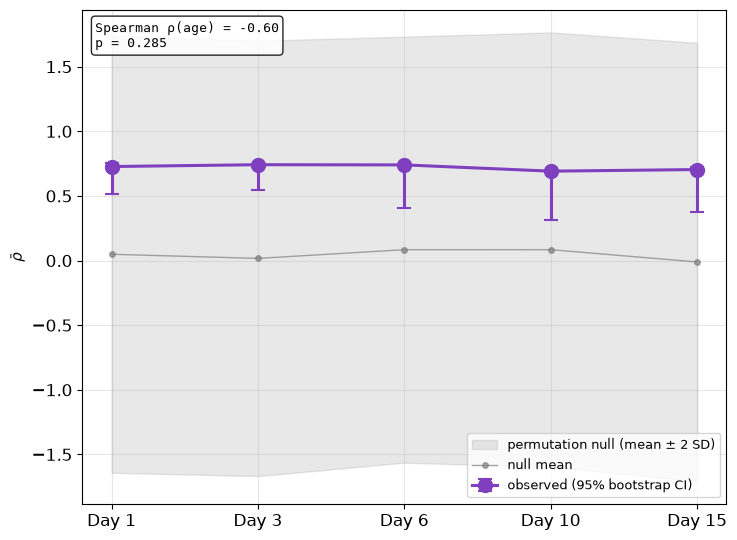

Saved: fig2_panel_mean_abs_rho.png


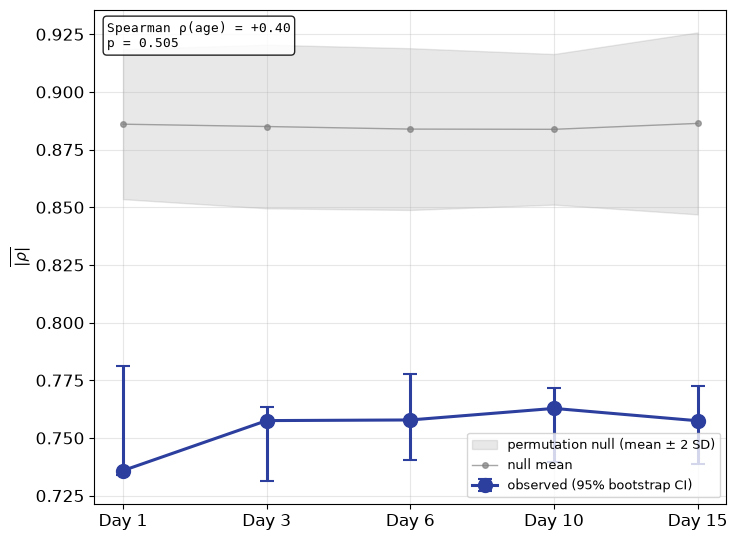

Saved: fig2_panel_neg_frac.png


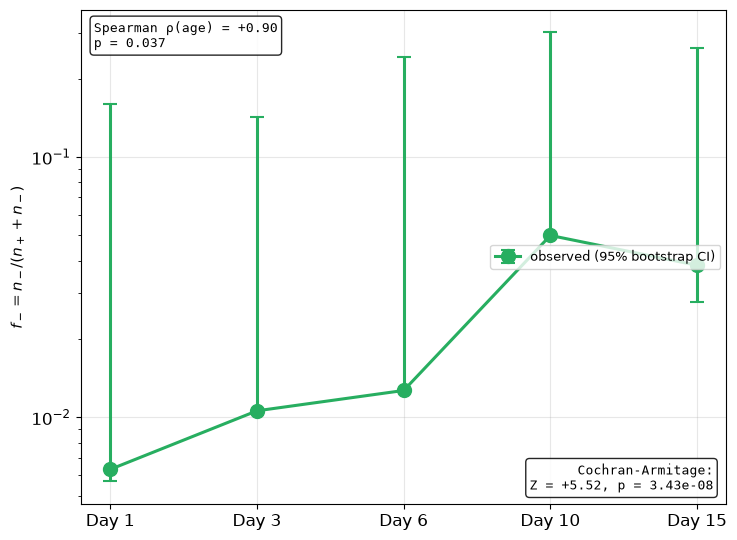

Saved: fig2_day6_day10_transition_test.png


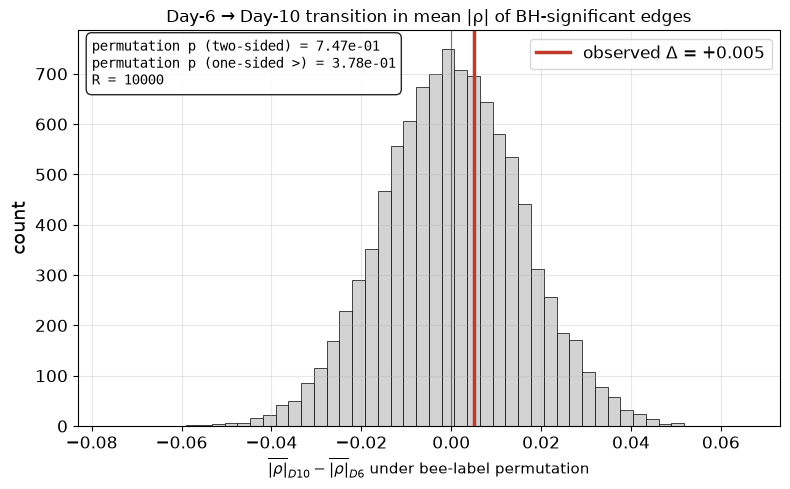

In [7]:
# FIGURE 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, rankdata, t as student_t, norm
from statsmodels.stats.multitest import multipletests


# ============================================================
# Configuration
# ============================================================
DATA_PATH = "Expression_raw_v1.xlsx"
AGE_COL = "Age (Days)"
PROTEIN_SUBSTR = "Vg protein"
DAYS = [1, 3, 6, 10, 15]
ALPHA = 0.05

N_BOOTSTRAP = 1000
N_PERMUTATIONS = 1000
N_TRANSITION_PERMUTATIONS = 10000
RANDOM_STATE = 42

OUTPUT_FIG = "fig2_edge_statistics_augmented.png"
OUTPUT_TRANSITION_FIG = "fig2_day6_day10_transition_test.png"
OUTPUT_CSV = "fig2_edge_statistics_summary.csv"


# ============================================================
# Fast pairwise Spearman + p-values via rank-then-Pearson + t-approximation
# ============================================================
def spearman_matrix_fast(X):
    n_samples, n_features = X.shape
    ranked = np.apply_along_axis(rankdata, 0, X)
    std = ranked.std(axis=0, ddof=0)
    rho = np.zeros((n_features, n_features))
    valid = std > 1e-12
    if valid.all():
        rho = np.corrcoef(ranked, rowvar=False)
    else:
        sub = ranked[:, valid]
        c = np.corrcoef(sub, rowvar=False)
        idx = np.where(valid)[0]
        rho[np.ix_(idx, idx)] = c
    np.fill_diagonal(rho, 1.0)

    n = n_samples
    with np.errstate(divide="ignore", invalid="ignore"):
        denom = 1.0 - rho ** 2
        denom = np.clip(denom, 1e-30, None)
        t_stat = rho * np.sqrt((n - 2) / denom)
    pval = 2.0 * student_t.sf(np.abs(t_stat), df=max(n - 2, 1))
    np.fill_diagonal(pval, 0.0)
    return rho, pval


def metrics_from_expression(X, alpha=ALPHA):
    """Return four edge statistics on BH-significant pairs.

    Returns a dict with:
      mean_abs    : mean |r| over BH-significant pairs
      mean_pos    : mean r over significant positive pairs
      mean_neg_abs: mean |r| over significant negative pairs
      neg_frac    : fraction of significant pairs that are negative
      density     : fraction of all pairs that are significant
      n_sig       : number of significant pairs
    """
    n_samples, n_features = X.shape
    if n_samples < 3 or n_features < 2:
        return dict(mean_abs=np.nan, mean_signed=np.nan, mean_pos=np.nan, mean_neg_abs=np.nan,
                    neg_frac=np.nan, density=np.nan, n_sig=0)
    if np.any(np.std(X, axis=0) < 1e-12):
        # Drop zero-variance columns
        keep = np.std(X, axis=0) > 1e-12
        X = X[:, keep]
        n_features = X.shape[1]
    rho, p = spearman_matrix_fast(X)
    iu = np.triu_indices(n_features, k=1)
    r_flat = rho[iu]
    p_flat = p[iu]
    p_flat = np.where(np.isfinite(p_flat), p_flat, 1.0)
    if len(p_flat) == 0:
        return dict(mean_abs=np.nan, mean_signed=np.nan, mean_pos=np.nan, mean_neg_abs=np.nan,
                    neg_frac=np.nan, density=0.0, n_sig=0)
    _, q_flat, _, _ = multipletests(p_flat, method="fdr_bh")
    sig = q_flat < alpha
    n_sig = int(sig.sum())
    if n_sig == 0:
        return dict(mean_abs=np.nan, mean_signed=np.nan, mean_pos=np.nan, mean_neg_abs=np.nan,
                    neg_frac=0.0, density=0.0, n_sig=0)
    r_sig = r_flat[sig]
    pos_mask = r_sig > 0
    neg_mask = r_sig < 0
    return dict(
        mean_abs=float(np.mean(np.abs(r_sig))),
        mean_signed=float(np.mean(r_sig)),
        mean_pos=float(np.mean(r_sig[pos_mask])) if pos_mask.any() else np.nan,
        mean_neg_abs=float(np.mean(np.abs(r_sig[neg_mask])))
                     if neg_mask.any() else np.nan,
        neg_frac=float(neg_mask.mean()),
        density=float(sig.mean()),
        n_sig=n_sig,
    )


# ============================================================
# Load and identify gene set
# ============================================================
df = pd.read_excel(DATA_PATH)
df.columns = df.columns.str.strip()
cols = [c for c in df.columns if PROTEIN_SUBSTR in str(c)]
protein_col = ([c for c in cols if "normalized" in str(c).lower()] or cols)[0]
gene_cols = [c for c in df.columns
             if c not in [AGE_COL, protein_col]
             and pd.api.types.is_numeric_dtype(df[c])]
print(f"Number of genes: {len(gene_cols)}")


# ============================================================
# Per-day observed metrics + bootstrap CIs + permutation null
# ============================================================
rng = np.random.default_rng(RANDOM_STATE)

records = []
boot_dists = {d: {} for d in DAYS}
null_dists = {d: {} for d in DAYS}

for day in DAYS:
    sub = df[df[AGE_COL] == day][gene_cols].copy()
    sub = sub.dropna(axis=1, how="any")              # drop genes missing on this day
    sub = sub.loc[:, sub.std(axis=0) > 1e-12]        # drop zero-variance genes
    X = sub.values.astype(float)
    n_bees = X.shape[0]

    obs = metrics_from_expression(X)

    # Bootstrap: bees with replacement
    boot_records = []
    for b in range(N_BOOTSTRAP):
        idx = rng.integers(0, n_bees, size=n_bees)
        Xb = X[idx]
        if np.any(np.std(Xb, axis=0) < 1e-12):
            continue
        boot_records.append(metrics_from_expression(Xb))
    boot_df = pd.DataFrame(boot_records)

    # Permutation null: shuffle each gene independently across bees
    null_records = []
    for r in range(N_PERMUTATIONS):
        Xp = X.copy()
        for g in range(Xp.shape[1]):
            Xp[:, g] = rng.permutation(Xp[:, g])
        null_records.append(metrics_from_expression(Xp))
    null_df = pd.DataFrame(null_records)

    rec = {"Day": day, "n_bees": n_bees, "n_genes": X.shape[1], **obs}
    for col in ["mean_abs", "mean_signed", "mean_pos", "mean_neg_abs",
                "neg_frac", "density", "n_sig"]:
        bvals = boot_df[col].dropna()
        nvals = null_df[col].dropna()
        if len(bvals):
            rec[f"{col}_boot_lo"] = float(bvals.quantile(0.025))
            rec[f"{col}_boot_hi"] = float(bvals.quantile(0.975))
        else:
            rec[f"{col}_boot_lo"] = np.nan
            rec[f"{col}_boot_hi"] = np.nan
        if len(nvals):
            rec[f"{col}_null_mean"] = float(nvals.mean())
            rec[f"{col}_null_sd"] = float(nvals.std(ddof=1))
            obs_val = rec.get(col, np.nan)
            if np.isfinite(obs_val) and len(nvals) >= 1:
                # one-sided p (greater) for mean_abs, density, n_sig, neg_frac
                rec[f"{col}_p_above"] = float(np.mean(nvals.values >= obs_val))
                rec[f"{col}_p_below"] = float(np.mean(nvals.values <= obs_val))
        else:
            rec[f"{col}_null_mean"] = np.nan
            rec[f"{col}_null_sd"] = np.nan
    boot_dists[day] = boot_df
    null_dists[day] = null_df
    records.append(rec)

    print(f"Day {day:>2}: n_sig={obs['n_sig']:>4}, "
          f"density={obs['density']:.3f}, "
          f"mean|r|={obs['mean_abs']:.3f}, "
          f"neg_frac={obs['neg_frac']:.3f}")

results = pd.DataFrame(records)
results.to_csv(OUTPUT_CSV, index=False)


# ============================================================
# Trend tests across age
# ============================================================
print("\n=== Trend tests across age (Days 1, 3, 6, 10, 15) ===")
days_arr = np.array(DAYS)

trend_summary = {}
for col in ["mean_abs", "mean_signed", "mean_pos", "mean_neg_abs",
            "neg_frac", "density"]:
    obs_vals = results[col].values
    rho, p_sp = spearmanr(days_arr, obs_vals, nan_policy="omit")
    print(f"  Spearman trend in {col:<14}: rho = {rho:+.3f}, p = {p_sp:.4f}")
    trend_summary[col] = (rho, p_sp)

# Cochran-Armitage on neg_frac (proportion of significant pairs that are negative)
neg_counts = np.array([
    int(round(results.loc[results["Day"] == d, "neg_frac"].iloc[0]
               * results.loc[results["Day"] == d, "n_sig"].iloc[0]))
    for d in DAYS
])
total_counts = results.loc[results["Day"].isin(DAYS), "n_sig"].values

# Cochran-Armitage: Z statistic for trend in proportions with scores w_a = a (day)
def cochran_armitage(neg_counts, total_counts, scores):
    n = total_counts.sum()
    if n == 0:
        return np.nan, np.nan
    p = neg_counts.sum() / n
    num = np.sum(scores * (neg_counts - total_counts * p))
    var = p * (1 - p) * (
        np.sum(total_counts * scores ** 2) -
        (np.sum(total_counts * scores)) ** 2 / n
    )
    if var <= 0:
        return np.nan, np.nan
    Z = num / np.sqrt(var)
    p_two = 2 * (1 - norm.cdf(abs(Z)))
    return Z, p_two

ca_Z, ca_p = cochran_armitage(neg_counts, total_counts, days_arr)
print(f"\n  Cochran-Armitage trend in neg_frac: Z = {ca_Z:+.2f}, p = {ca_p:.4e}")


# ============================================================
# Day-6 → Day-10 transition test on mean |r|
# ============================================================
X6 = df[df[AGE_COL] == 6][gene_cols].dropna(axis=1).values
X10 = df[df[AGE_COL] == 10][gene_cols].dropna(axis=1).values
common_genes = sorted(set(df[df[AGE_COL] == 6][gene_cols].dropna(axis=1).columns) &
                       set(df[df[AGE_COL] == 10][gene_cols].dropna(axis=1).columns))
X6 = df[df[AGE_COL] == 6][common_genes].values
X10 = df[df[AGE_COL] == 10][common_genes].values
m6, m10 = X6.shape[0], X10.shape[0]
obs6 = metrics_from_expression(X6)["mean_abs"]
obs10 = metrics_from_expression(X10)["mean_abs"]
obs_diff = obs10 - obs6

X_pool = np.vstack([X6, X10])
m = m6 + m10
null_diffs = np.zeros(N_TRANSITION_PERMUTATIONS)
for r in range(N_TRANSITION_PERMUTATIONS):
    perm = rng.permutation(m)
    Xa = X_pool[perm[:m6]]
    Xb = X_pool[perm[m6:]]
    if np.any(np.std(Xa, axis=0) < 1e-12) or np.any(np.std(Xb, axis=0) < 1e-12):
        null_diffs[r] = np.nan
        continue
    null_diffs[r] = (
        metrics_from_expression(Xb)["mean_abs"]
        - metrics_from_expression(Xa)["mean_abs"]
    )
null_diffs = null_diffs[np.isfinite(null_diffs)]
p_two = float(np.mean(np.abs(null_diffs) >= abs(obs_diff)))
p_one = float(np.mean(null_diffs >= obs_diff))
print(f"\n  Day-6 → Day-10 transition in mean |r|:")
print(f"    Day 6 mean |r| = {obs6:.3f},  Day 10 mean |r| = {obs10:.3f}")
print(f"    Observed Δ = {obs_diff:+.3f}")
print(f"    Permutation p (two-sided) = {p_two:.4e},  one-sided (>) = {p_one:.4e}")


# ============================================================
# Augmented Figure 2: 1x3 panel
#   (A) mean signed r        with null + bootstrap CI
#   (B) mean |r|             with null + bootstrap CI
#   (C) fraction neg edges   with bootstrap CI ONLY (null band omitted)
# ============================================================
def plot_panel(ax, statistic, title, ylabel, color, show_null=True):
    obs = results[statistic].values
    lo = results[f"{statistic}_boot_lo"].values
    hi = results[f"{statistic}_boot_hi"].values
    null_mu = results[f"{statistic}_null_mean"].values
    null_sd = results[f"{statistic}_null_sd"].values

    xs = np.arange(len(DAYS))
    if show_null:
        ax.fill_between(
            xs, null_mu - 2 * null_sd, null_mu + 2 * null_sd,
            color="gray", alpha=0.18, label="permutation null (mean ± 2 SD)",
        )
        ax.plot(xs, null_mu, "o-", color="gray", lw=1.0, ms=4, alpha=0.7,
                label="null mean")

    yerr = np.vstack([np.maximum(obs - lo, 0.0), np.maximum(hi - obs, 0.0)])
    ax.errorbar(
        xs, obs, yerr=yerr,
        fmt="o-", color=color, lw=2.2, ms=10,
        capsize=5, capthick=1.5,
        label="observed (95% bootstrap CI)",
    )

    rho, p_sp = trend_summary.get(statistic, (np.nan, np.nan))
    if np.isfinite(rho):
        ax.text(0.02, 0.98,
                f"Spearman ρ(age) = {rho:+.2f}\np = {p_sp:.3f}",
                transform=ax.transAxes, ha="left", va="top",
                fontsize=9, family="monospace",
                bbox=dict(boxstyle="round,pad=0.3",
                          fc="white", ec="black", alpha=0.85))

    ax.set_xticks(xs)
    ax.set_xticklabels([f"Day {d}" for d in DAYS])
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3)


# Three separate figures, each with rho notation in titles/labels.
panels = [
    {
        "stat": "mean_signed",
        "title": "",
        #"title": r"Mean signed $\rho$ on BH-significant edges",
        "ylabel": r"$\bar{\rho}$",
        "color": "#7f3fbf",
        "show_null": True,
        "out": "fig2_panel_mean_signed_rho.png",
    },
    {
        "stat": "mean_abs",
        "title": "",
        #"title": r"Mean $|\rho|$ on BH-significant edges",
        "ylabel": r"$\overline{|\rho|}$",
        "color": "#2c3e9e",
        "show_null": True,
        "out": "fig2_panel_mean_abs_rho.png",
    },
    {
        "stat": "neg_frac",
        "title": "",
        #"title": "Fraction of negative edges",
        "ylabel": r"$f_- = n_- / (n_+ + n_-)$",
        "color": "#27ae60",
        "show_null": False,
        "out": "fig2_panel_neg_frac.png",
    },
]

for p in panels:
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    plot_panel(ax, p["stat"], p["title"], p["ylabel"],
               p["color"], show_null=p["show_null"])

    # Cochran-Armitage annotation only on the neg_frac panel
    if p["stat"] == "neg_frac":
        ax.set_yscale('log') 
        ax.text(0.98, 0.02,
                f"Cochran-Armitage:\nZ = {ca_Z:+.2f}, p = {ca_p:.2e}",
                transform=ax.transAxes, ha="right", va="bottom",
                fontsize=9, family="monospace",
                bbox=dict(boxstyle="round,pad=0.3",
                          fc="white", ec="black", alpha=0.85))

    ax.legend(loc="lower right" if p["stat"] != "neg_frac" else "center right",
              fontsize=9)
    plt.tight_layout()
    plt.savefig(p["out"], dpi=200, bbox_inches="tight")
    print(f"Saved: {p['out']}")
    plt.show()
    plt.close(fig)


# ============================================================
# Standalone transition-test figure
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(null_diffs, bins=50, color="lightgray", edgecolor="black", lw=0.5)
ax.axvline(0, color="black", lw=0.8, alpha=0.5)
ax.axvline(obs_diff, color="#c0392b", lw=2.5,
           label=f"observed Δ = {obs_diff:+.3f}")
ax.set_xlabel(r"$\overline{|\rho|}_{D10} - \overline{|\rho|}_{D6}$ under bee-label permutation",
              fontsize=11)
ax.set_ylabel("count")
ax.set_title("Day-6 → Day-10 transition in mean |ρ| of BH-significant edges",
             fontsize=12)
ax.text(0.02, 0.98,
        f"permutation p (two-sided) = {p_two:.2e}\n"
        f"permutation p (one-sided >) = {p_one:.2e}\n"
        f"R = {N_TRANSITION_PERMUTATIONS}",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=10, family="monospace",
        bbox=dict(boxstyle="round,pad=0.4",
                  fc="white", ec="black", alpha=0.85))
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_TRANSITION_FIG, dpi=200, bbox_inches="tight")
print(f"Saved: {OUTPUT_TRANSITION_FIG}")
plt.show()

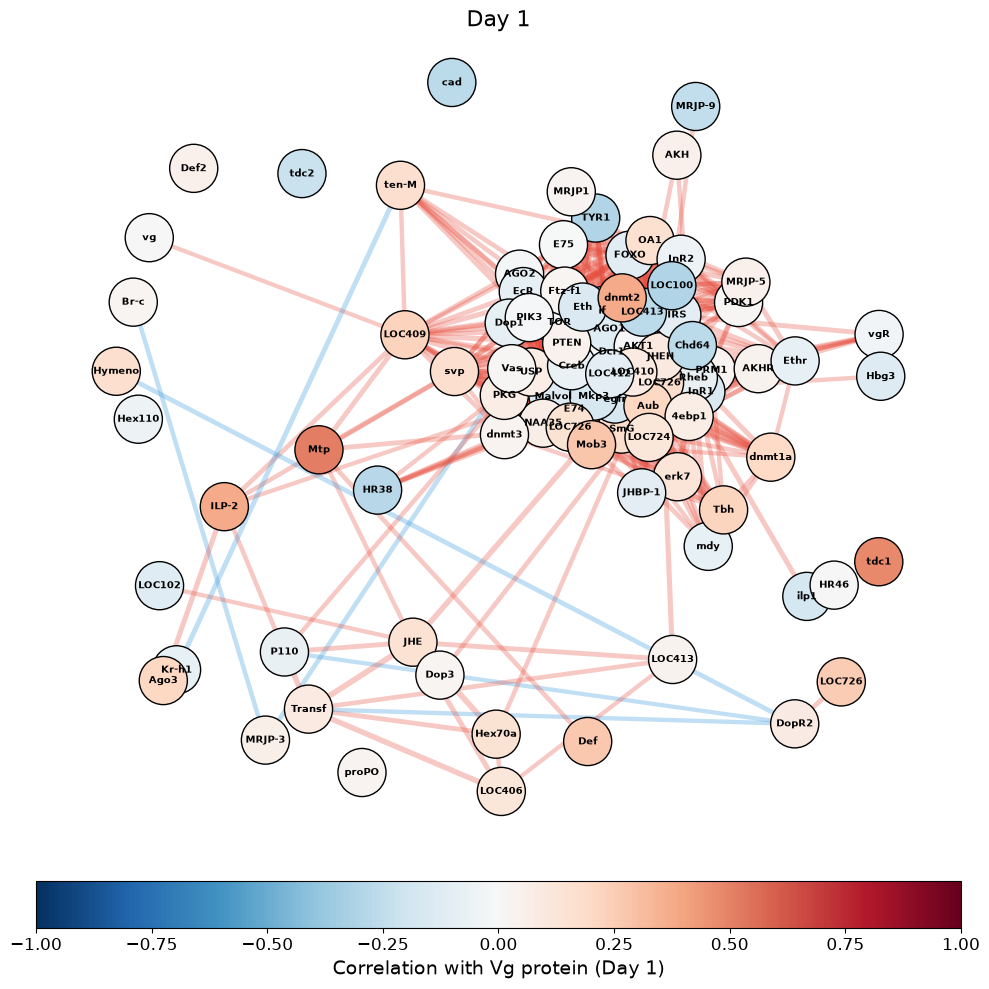

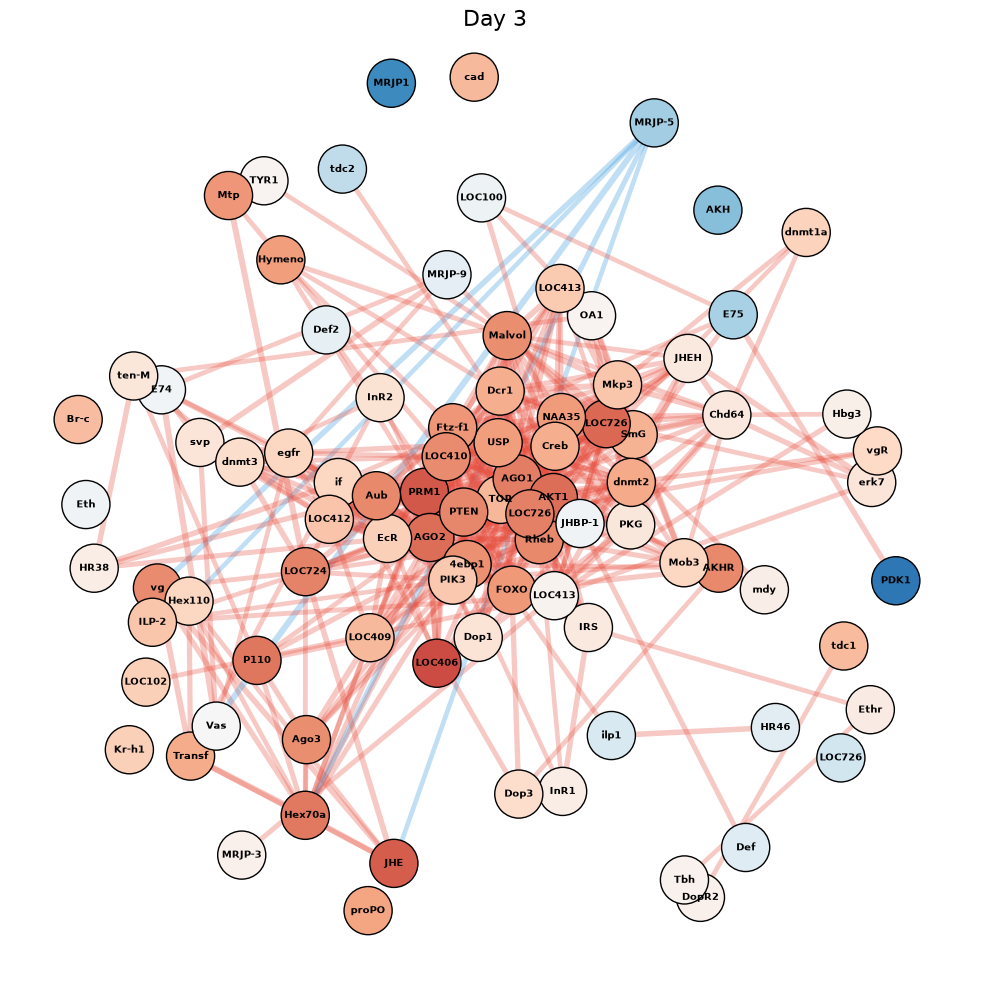

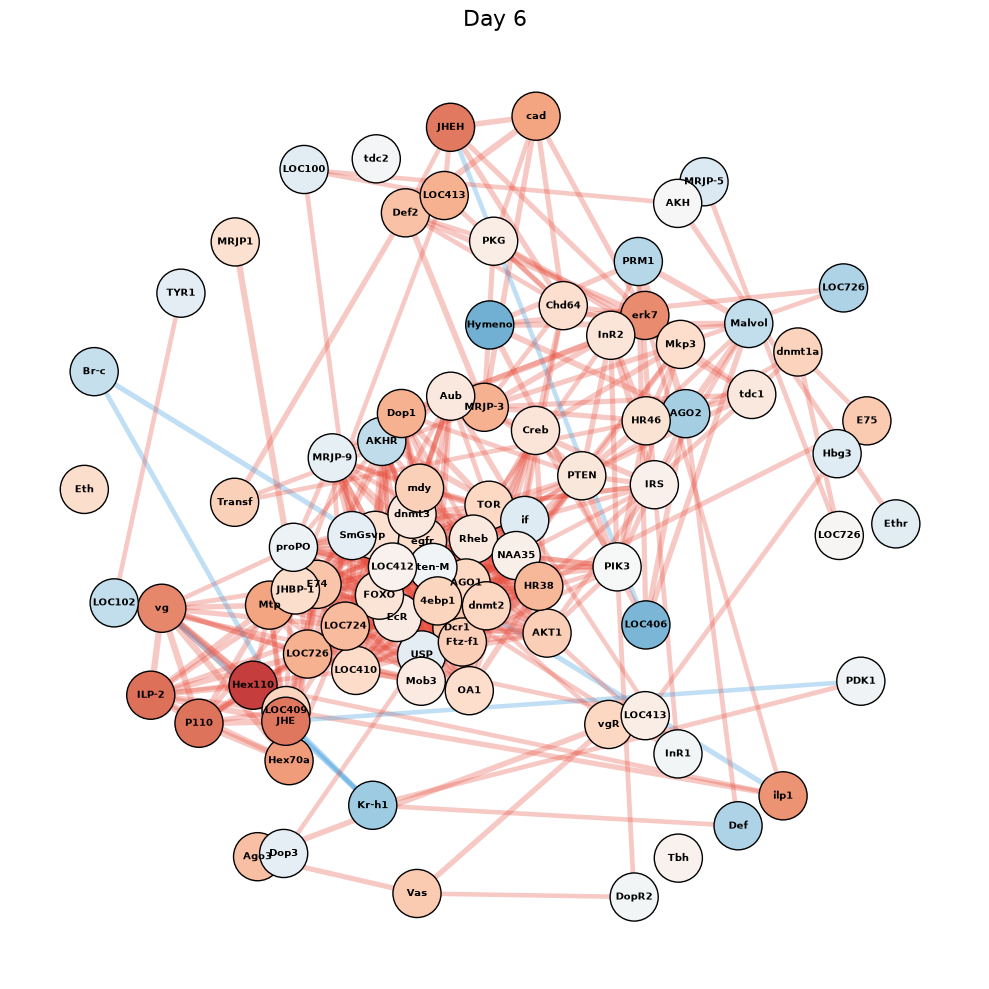

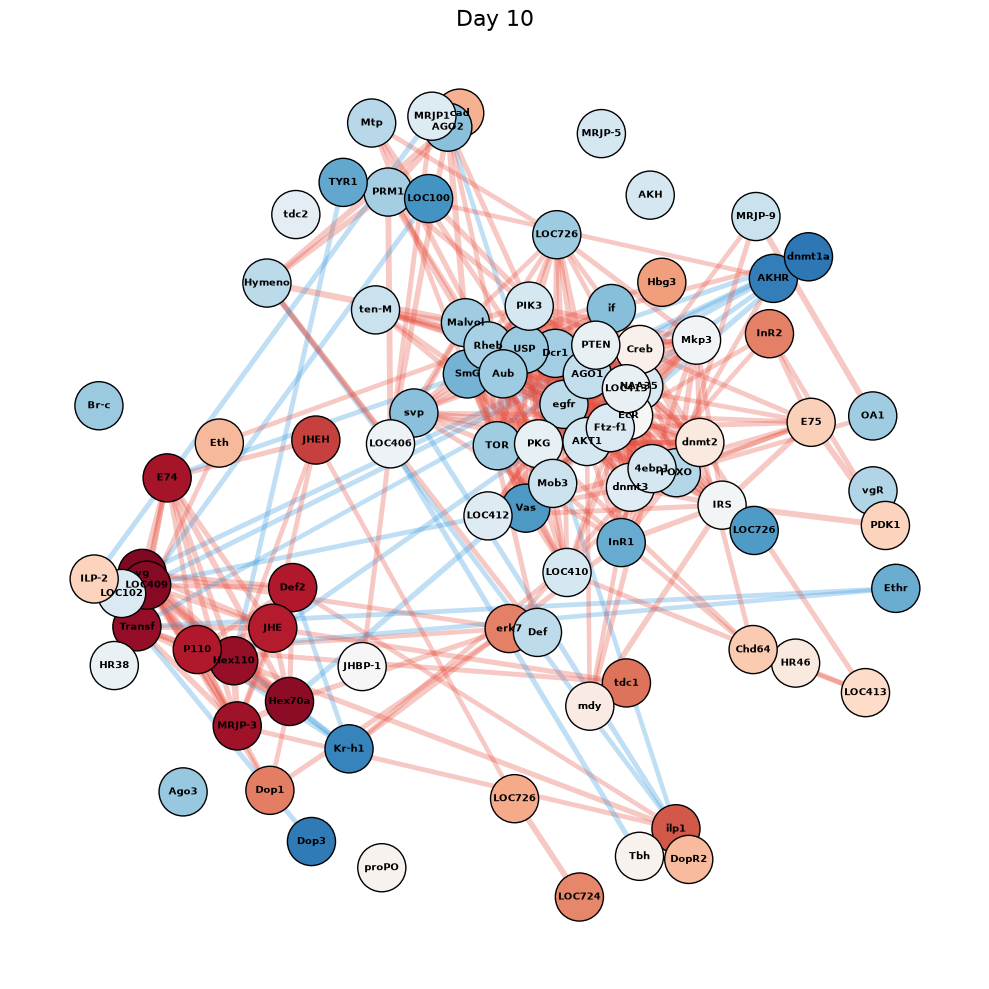

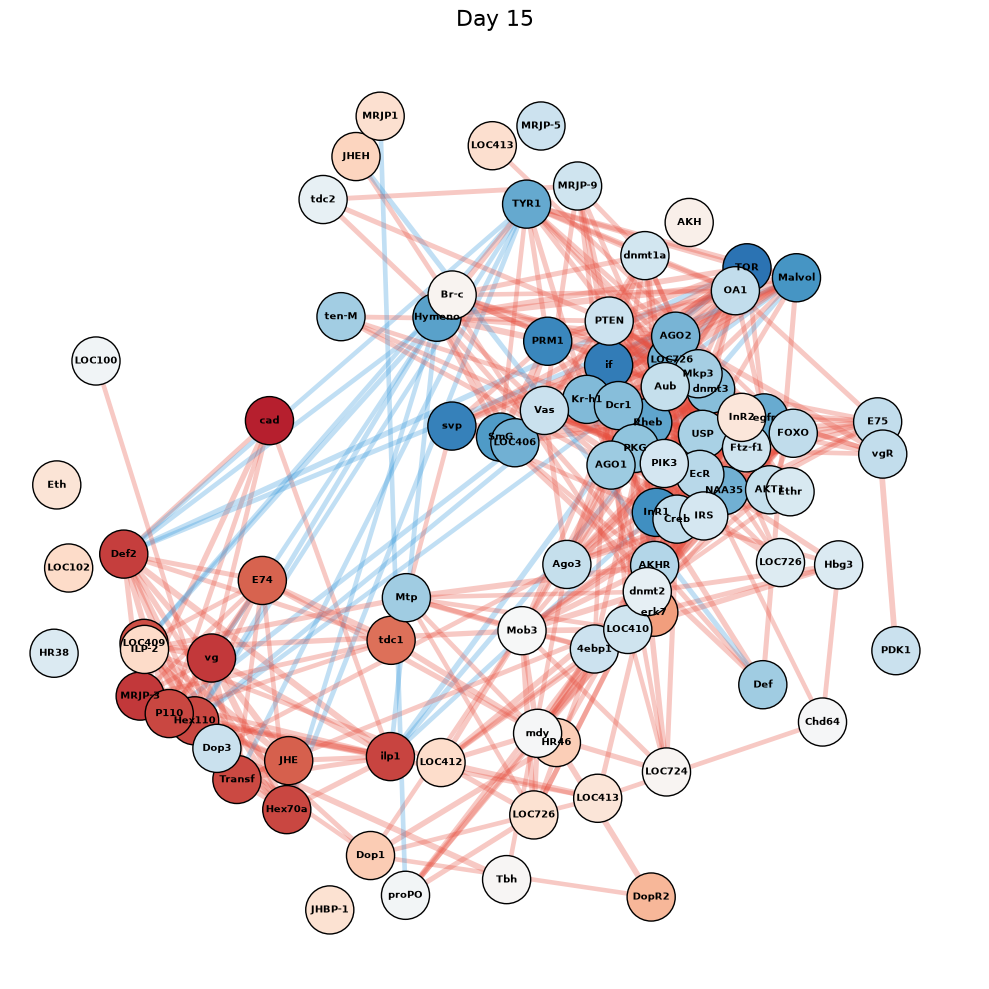

Completed: 5 individual plots generated for top 90 genes.
Genes included: ['cad', 'TOR', 'MRJP-3', 'vg', 'if', 'Def2', 'ilp1', 'svp', 'Hex110', 'P110', 'Hex70a', 'Transferrin1', 'PRM1', 'LOC409966', 'InR1', 'JHE', 'E74', 'Malvolio', 'SmG', 'tdc1', 'Hymenoptaecin', 'Rheb', 'TYR1', 'egfr', 'LOC406144', 'LOC726899 GB52437', 'NAA35', 'AGO2', 'Kr-h1', 'Dcr1', 'dnmt3', 'erk7', 'PKG', 'AGO1', 'Mtp', 'Def', 'ten-M', 'Mkp3', 'DopR2', 'USP', 'AKHR', 'EcR', 'Dop1', 'FOXO', 'OA1', 'Creb', 'E75', 'vgR', 'HR46', 'Ago3', 'Aub', 'AKT1', 'PDK1', 'JHEH', 'Vas', 'Dop3', 'PTEN', 'MRJP-5', '4ebp1', 'Ftz-f1', 'MRJP-9', 'LOC410022', 'LOC102655054', 'dnmt1a', 'ILP-2', 'PIK3', 'LOC412541', 'IRS', 'LOC413670', 'MRJP1', 'Ethr', 'LOC726781', 'JHBP-1', 'Hbg3', 'HR38', 'LOC726648', 'Eth', 'LOC413141', 'InR2', 'dnmt2', 'tdc2', 'AKH', 'LOC100577942', 'proPO', 'Br-c', 'LOC724829', 'mdy', 'Tbh', 'Chd64', 'Mob3']


In [9]:
#FIGURE 3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests
import networkx as nx

# Load data
DATA_PATH = "Expression_raw_v1.xlsx"
df = pd.read_excel(DATA_PATH)

AGE_COL = "Age (Days)"
PROTEIN_SUBSTR = "Vg protein"
DAYS = [1, 3, 6, 10, 15]
N = 90 # Tunable Top N

# Identify protein and gene columns
cols = [c for c in df.columns if PROTEIN_SUBSTR in str(c)]
protein_col = [c for c in cols if "normalized" in str(c).lower()][0] if any("normalized" in str(c).lower() for c in cols) else cols[0]
gene_cols = [c for c in df.columns if c not in [AGE_COL, protein_col]]

# Rank genes by absolute correlation with Vg protein at Day 15 (most mature state)
day15_data = df[df[AGE_COL] == 15]
vg15 = day15_data[protein_col].astype(float).values
abs_cors = []
for g in gene_cols:
    g_data = day15_data[g].astype(float).values
    if np.std(g_data) > 1e-12:
        #r, _ = pearsonr(g_data, vg15)
        r, _ = spearmanr(g_data, vg15)
        abs_cors.append((g, abs(r)))
    else:
        abs_cors.append((g, 0.0))

top_n_genes = [g for g, r in sorted(abs_cors, key=lambda x: x[1], reverse=True)[:N]]

# Create individual plots
for day in DAYS:
    day_df = df[df[AGE_COL] == day]
    vg_day = day_df[protein_col].astype(float).values
    
    node_corrs = []
    labels = {}
    for g in top_n_genes:
        g_data = day_df[g].astype(float).values
        if np.std(g_data) > 1e-12 and np.std(vg_day) > 1e-12:
            #r, _ = pearsonr(g_data, vg_day)
            r, _ = spearmanr(g_data, vg_day)
            node_corrs.append(r if np.isfinite(r) else 0)
        else:
            node_corrs.append(0)
        labels[g] = g[:6]

    G = nx.Graph()
    G.add_nodes_from(top_n_genes)
    
    edge_list = []
    edge_colors = []
    edge_widths = []
    
    # Collect all pairwise correlations among Top N for this day
    pair_data = []
    for i in range(len(top_n_genes)):
        for j in range(i + 1, len(top_n_genes)):
            g1, g2 = top_n_genes[i], top_n_genes[j]
            d1, d2 = day_df[g1].values, day_df[g2].values
            if np.std(d1) > 1e-12 and np.std(d2) > 1e-12:
                #r, p = pearsonr(d1, d2)
                r, p = spearmanr(d1, d2)
                pair_data.append((g1, g2, float(r) if np.isfinite(r) else 0.0,
                                   float(p) if np.isfinite(p) else 1.0))
            else:
                pair_data.append((g1, g2, 0.0, 1.0))

    # Apply Benjamini-Hochberg correction across all pairs for this day
    if pair_data:
        p_raw = [d[3] for d in pair_data]
        _, q_vals, _, _ = multipletests(p_raw, method='fdr_bh')
    else:
        q_vals = []

    for idx, (g1, g2, r, _) in enumerate(pair_data):
        q = q_vals[idx]
        if q < 0.05 and np.abs(r) > 0.5:
            G.add_edge(g1, g2, weight=r)
            edge_list.append((g1, g2))
            edge_colors.append('#e74c3c' if r > 0 else '#3498db')
            edge_widths.append(abs(r) * 5)

    # Use a consistent figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))
    pos = nx.spring_layout(G, k=0.7, iterations=50, seed=42)
    
    # Draw graph elements
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edge_list, edge_color=edge_colors, width=edge_widths, alpha=0.3)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1200, node_color=node_corrs, 
                           cmap='RdBu_r', vmin=-1, vmax=1, edgecolors='black', linewidths=1)
    nx.draw_networkx_labels(G, pos, ax=ax, labels=labels, font_size=7, font_weight='bold')

    ax.set_title(f'Day {day}', fontsize=16)
    ax.axis('off')
    if day==1:
        # Colorbar fix: pass 'ax=ax' to tell matplotlib where to steal space
        sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=-1, vmax=1))
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.06, pad=0.02)
        cbar.set_label(f'Correlation with Vg protein (Day {day})')
    
    plt.tight_layout()
    #plt.savefig(f'top_{N}_network_day_{day}.png')
    plt.show()
    plt.close()

print(f"Completed: 5 individual plots generated for top {N} genes.")
print("Genes included:", top_n_genes)

=== Per-day descriptive statistics ===
      n   mean     SD  median    IQR    min     max     CV    QCD  Shapiro_W  Shapiro_p
Day                                                                                    
1    16  1.545  0.660   1.599  0.379  0.284   2.825  0.427  0.237      0.915      0.140
3    16  2.001  0.922   1.855  1.282  0.386   3.552  0.461  0.691      0.962      0.703
6    16  3.736  2.755   3.325  1.994  0.616  12.624  0.737  0.600      0.764      0.001
10   16  4.402  2.825   4.047  2.685  0.984  11.558  0.642  0.663      0.896      0.069
15   16  4.002  2.416   3.986  3.958  0.933   7.797  0.604  0.993      0.919      0.164

=== Omnibus tests ===
Kruskal-Wallis (mean rank differs):       H = 22.50,  p = 1.59e-04
Levene/Brown-Forsythe (variance differs): W = 4.05,  p = 4.98e-03
Bartlett (parametric variance):           χ² = 39.26, p = 6.15e-08
Spearman age vs Vg (monotone trend):      ρ = +0.48, p = 6.89e-06
Jonckheere-Terpstra (ordered trend):      JT = 1816, Z =

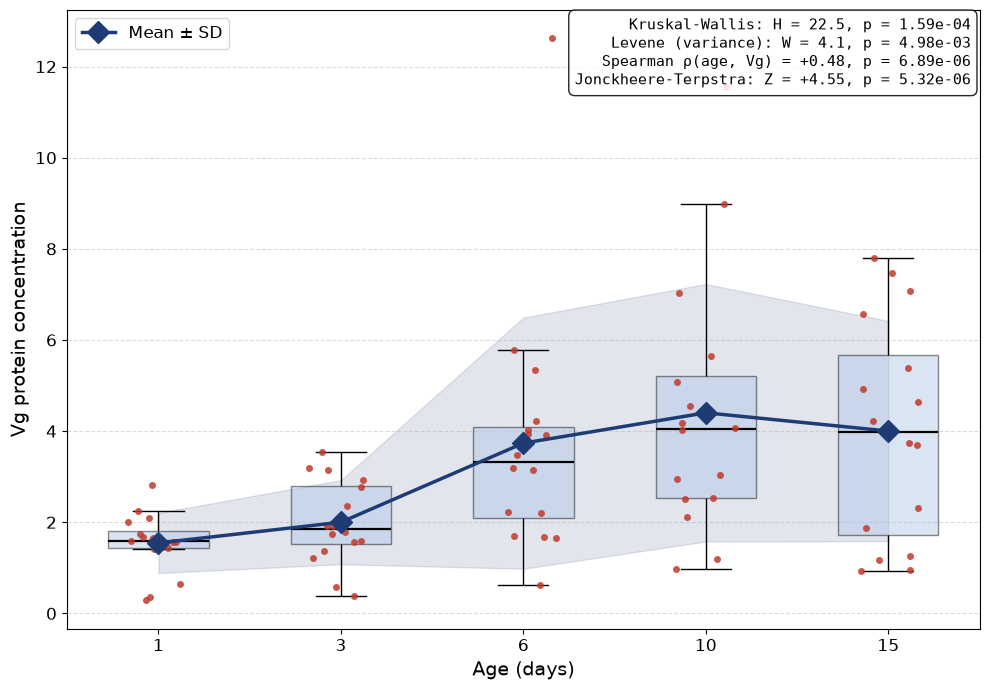

In [12]:
# FIGURE 4

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (
    kruskal, levene, bartlett, spearmanr, mannwhitneyu, shapiro,
)
from sklearn.mixture import GaussianMixture
import scikit_posthocs as sp


# ============================================================
# Configuration
# ============================================================
DATA_PATH = "Expression_raw_v1.xlsx"
AGE_COL = "Age (Days)"
PROTEIN_SUBSTR = "Vg protein"
DAYS = [1, 3, 6, 10, 15]
OUTPUT_FIG = "fig4_Vg_dynamics_augmented.png"
OUTPUT_DUNN_FIG = "fig4_Vg_pairwise_dunn.png"

# Global font sizes
plt.rcParams.update({
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})


# ============================================================
# Load
# ============================================================
df = pd.read_excel(DATA_PATH)
df.columns = df.columns.str.strip()
cols = [c for c in df.columns if PROTEIN_SUBSTR in str(c)]
protein_col = ([c for c in cols if "normalized" in str(c).lower()] or cols)[0]

groups = {d: df.loc[df[AGE_COL] == d, protein_col].dropna().values for d in DAYS}


# ============================================================
# Per-day descriptive stats
# ============================================================
records = []
for d in DAYS:
    g = groups[d]
    med = np.median(g); q1, q3 = np.percentile(g, [25, 75])
    iqr = q3 - q1
    qcd = iqr / med if med > 1e-12 else np.nan
    cv = np.std(g, ddof=1) / np.mean(g) if np.mean(g) > 1e-12 else np.nan
    sw_stat, sw_p = shapiro(g) if len(g) >= 3 else (np.nan, np.nan)
    records.append({
        "Day": d, "n": len(g),
        "mean": np.mean(g), "SD": np.std(g, ddof=1),
        "median": med, "IQR": iqr, "min": g.min(), "max": g.max(),
        "CV": cv, "QCD": qcd,
        "Shapiro_W": sw_stat, "Shapiro_p": sw_p,
    })
desc = pd.DataFrame(records).set_index("Day")
print("=== Per-day descriptive statistics ===")
print(desc.round(3).to_string())


# ============================================================
# Omnibus tests
# ============================================================
group_list = [groups[d] for d in DAYS]

H_kw, p_kw = kruskal(*group_list)
W_lev, p_lev = levene(*group_list, center="median")
W_bart, p_bart = bartlett(*group_list)

# Spearman between age (ordinal) and Vg
ages = df[AGE_COL].values
vg_all = df[protein_col].values
mask = np.isfinite(vg_all)
rho_age, p_age = spearmanr(ages[mask], vg_all[mask])

# Jonckheere-Terpstra (ordered alternative): expressed via U-statistic sum
def jonckheere_terpstra(groups_in_order):
    """JT statistic with normal-approximation two-sided p-value.
    Tests H0: all groups equal vs H1: groups stochastically ordered.
    JT counts concordant pairs across i<j: sum #{x in g_i, y in g_j: x < y}
    (with 0.5 for ties), so JT > E[JT] indicates an *increasing* trend.
    """
    k = len(groups_in_order)
    n_i = [len(g) for g in groups_in_order]
    N = sum(n_i)
    JT = 0.0
    for i in range(k):
        for j in range(i + 1, k):
            xi = groups_in_order[i]; xj = groups_in_order[j]
            # vectorized concordant count
            comp = xj[None, :] - xi[:, None]
            JT += float(np.sum(comp > 0) + 0.5 * np.sum(comp == 0))
    EJT = (N**2 - sum(n**2 for n in n_i)) / 4.0
    VJT = (N**2 * (2*N + 3) - sum(n**2 * (2*n + 3) for n in n_i)) / 72.0
    Z = (JT - EJT) / np.sqrt(VJT)
    from scipy.stats import norm
    p = 2 * (1 - norm.cdf(abs(Z)))
    return JT, Z, p

JT, Z_jt, p_jt = jonckheere_terpstra(group_list)

print("\n=== Omnibus tests ===")
print(f"Kruskal-Wallis (mean rank differs):       H = {H_kw:.2f},  p = {p_kw:.2e}")
print(f"Levene/Brown-Forsythe (variance differs): W = {W_lev:.2f},  p = {p_lev:.2e}")
print(f"Bartlett (parametric variance):           χ² = {W_bart:.2f}, p = {p_bart:.2e}")
print(f"Spearman age vs Vg (monotone trend):      ρ = {rho_age:+.2f}, p = {p_age:.2e}")
print(f"Jonckheere-Terpstra (ordered trend):      JT = {JT:.0f}, Z = {Z_jt:+.2f}, "
      f"p = {p_jt:.2e}")


# ============================================================
# Pairwise post-hoc: Dunn's test (BH-adjusted)
# ============================================================
dunn = sp.posthoc_dunn(df, val_col=protein_col, group_col=AGE_COL,
                       p_adjust="fdr_bh")
dunn = dunn.loc[DAYS, DAYS]
print("\n=== Pairwise Dunn's test (BH-adjusted q-values) ===")
print(dunn.round(4).to_string())


# ============================================================
# Bimodality test on log(Vg) at Day 10 and Day 15
# ============================================================
print("\n=== Bimodality (GMM) on log1p(Vg), Days 10 & 15 ===")
bimodal_records = []
for d in [10, 15]:
    x = np.log1p(groups[d]).reshape(-1, 1)
    gmm1 = GaussianMixture(n_components=1, random_state=0).fit(x)
    gmm2 = GaussianMixture(n_components=2, random_state=0).fit(x)
    bic1, bic2 = gmm1.bic(x), gmm2.bic(x)
    delta = bic1 - bic2
    favor = ("strong evidence for bimodality" if delta > 10
             else "moderate" if delta > 6
             else "weak" if delta > 2 else "none")
    bimodal_records.append({"Day": d, "BIC_k1": bic1, "BIC_k2": bic2,
                             "delta_BIC": delta, "preferred":
                             ("k=2" if delta > 2 else "k=1"),
                             "evidence": favor})
    print(f"Day {d}: BIC k=1 = {bic1:.2f}, BIC k=2 = {bic2:.2f}, "
          f"ΔBIC = {delta:+.2f} ({favor})")


# ============================================================
# Figure 4
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))

# Boxplot underlay (IQR + whiskers, hidden outliers because the strip shows them)
sns.boxplot(
    x=AGE_COL, y=protein_col, data=df, ax=ax,
    width=0.55, showfliers=False,
    boxprops=dict(facecolor="#aec7e8", edgecolor="black", alpha=0.45),
    medianprops=dict(color="black", lw=1.6),
    whiskerprops=dict(color="black", lw=1),
    capprops=dict(color="black", lw=1),
    order=DAYS,
)

# Strip overlay
sns.stripplot(
    x=AGE_COL, y=protein_col, data=df, ax=ax,
    color="#c0392b", alpha=0.85, jitter=0.18, size=5,
    order=DAYS,
)

# Mean line + SD shading
means = desc["mean"].values
sds = desc["SD"].values
xs = np.arange(len(DAYS))
ax.plot(xs, means, marker="D", color="#1f3b73",
        markersize=11, linestyle="-", linewidth=2.5,
        label="Mean ± SD", zorder=10)
ax.fill_between(xs, means - sds, means + sds,
                color="#1f3b73", alpha=0.13, zorder=1)

ax.set_xticks(xs)
ax.set_xticklabels([str(d) for d in DAYS])
ax.set_xlabel("Age (days)")
ax.set_ylabel("Vg protein concentration")
#ax.set_title("Vg protein dynamics and dispersion across age")
ax.grid(True, axis="y", linestyle="--", alpha=0.45)
ax.legend(loc="upper left")

# Annotate omnibus statistics in the corner
text_block = (
    f"Kruskal-Wallis: H = {H_kw:.1f}, p = {p_kw:.2e}\n"
    f"Levene (variance): W = {W_lev:.1f}, p = {p_lev:.2e}\n"
    f"Spearman ρ(age, Vg) = {rho_age:+.2f}, p = {p_age:.2e}\n"
    f"Jonckheere-Terpstra: Z = {Z_jt:+.2f}, p = {p_jt:.2e}"
)
ax.text(
    0.99, 0.99, text_block,
    transform=ax.transAxes, ha="right", va="top",
    fontsize=11, family="monospace",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.85),
)

plt.tight_layout()
plt.savefig(OUTPUT_FIG, dpi=200, bbox_inches="tight")
print(f"\nSaved: {OUTPUT_FIG}")
plt.show()

In [ ]:
#!/usr/bin/env python
"""
Consensus partition pipeline for the bee Vg co-expression dataset.

For each age (Days 1, 3, 6, 10, 15) the script:
  1. Builds a signed Spearman correlation matrix on the bees of that day.
  2. For B bootstrap resamples of bees and three base clustering methods
     (signed-Laplacian spectral, Ward hierarchical on (1 - rho), WGCNA-TOM),
     produces partitions at fixed K = K_BY_DAY[day] obtained from modularity.
  3. Aggregates a co-membership matrix Pi_ij over all (bootstrap x method)
     runs.
  4. Extracts the final partition via Ward-linkage hierarchical clustering
     on (1 - Pi).
  5. Relabels clusters so M1 is the cluster containing the VG protein,
     and remaining clusters are ordered by descending |mean rho(VG)|.
  6. Writes per-day membership CSVs in the same format as the existing
     consensus_clusters_dayD_KK.csv files (columns: feature, cluster,
     stability, Vg_rho, Vg_p, module, module_size, module_mean_Vg_rho,
     module_stability).

Outputs:
  consensus_clusters_day{D}_K{K}.csv      one per day
  consensus_heatmap_day{D}_K{K}.png       co-membership block heatmap per day
"""

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, rankdata, t as student_t
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from scipy.linalg import eigh
from sklearn.cluster import KMeans
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURATION
# ============================================================
EXCEL_FILE = "Expression_raw_v1.xlsx"
AGE_COL = "Age (Days)"
PROTEIN_SUBSTR = "Vg protein"

DAYS = [1, 3, 6, 10, 15]

# Per-day cluster count selected from the K-sweep diagnostics.
K_BY_DAY = {1: 4, 3: 3, 6: 3, 10: 4, 15: 4}

N_BOOTSTRAP = 300                 # resamples per day
EDGE_THRESHOLD = "p"              # "p" raw, "q" BH-FDR, "none"
ALPHA = 0.05
SOFT_BETA = 6                     # WGCNA soft-thresholding power
METHODS = ("spectral", "hierarchical", "wgcna_tom")
FINAL_LINKAGE = "ward"
RANDOM_STATE = 42
VERBOSE = True


# ============================================================
# CORRELATIONS, P-VALUES, BH-FDR, ADJACENCY
# ============================================================
def spearman_matrix(X):
    """Pairwise Spearman rho and two-sided p-values for the columns of X
    (rows = samples). Fast path uses ranked Pearson + t-approximation."""
    n_samples, n_features = X.shape

    if np.isnan(X).any():
        rho = np.zeros((n_features, n_features))
        pval = np.ones((n_features, n_features))
        for i in range(n_features):
            for j in range(i + 1, n_features):
                xi, xj = X[:, i], X[:, j]
                m = np.isfinite(xi) & np.isfinite(xj)
                if m.sum() < 3 or np.std(xi[m]) < 1e-12 or np.std(xj[m]) < 1e-12:
                    continue
                r, p = spearmanr(xi[m], xj[m])
                rho[i, j] = rho[j, i] = r
                pval[i, j] = pval[j, i] = p
        np.fill_diagonal(rho, 1.0)
        np.fill_diagonal(pval, 0.0)
        return rho, pval

    ranked = np.apply_along_axis(rankdata, 0, X)
    std = ranked.std(axis=0, ddof=0)
    rho = np.zeros((n_features, n_features))
    valid = std > 1e-12
    if valid.all():
        rho = np.corrcoef(ranked, rowvar=False)
    else:
        sub = ranked[:, valid]
        c = np.corrcoef(sub, rowvar=False)
        idx = np.where(valid)[0]
        rho[np.ix_(idx, idx)] = c
    np.fill_diagonal(rho, 1.0)

    n = n_samples
    with np.errstate(divide="ignore", invalid="ignore"):
        denom = 1.0 - rho ** 2
        denom = np.clip(denom, 1e-30, None)
        t_stat = rho * np.sqrt((n - 2) / denom)
    pval = 2.0 * student_t.sf(np.abs(t_stat), df=max(n - 2, 1))
    np.fill_diagonal(pval, 0.0)
    return rho, pval


def bh_threshold(pval, alpha):
    """Boolean mask of edges passing BH FDR < alpha (off-diagonal)."""
    n = pval.shape[0]
    iu = np.triu_indices(n, k=1)
    p_flat = np.where(np.isfinite(pval[iu]), pval[iu], 1.0)
    if len(p_flat) == 0:
        return np.zeros_like(pval, dtype=bool)
    _, q_flat, _, _ = multipletests(p_flat, method="fdr_bh")
    qmat = np.ones((n, n))
    qmat[iu] = q_flat
    qmat[iu[1], iu[0]] = q_flat
    np.fill_diagonal(qmat, 0.0)
    return qmat < alpha


def build_signed_adjacency(rho, pval, mode, alpha):
    if mode == "p":
        mask = pval < alpha
    elif mode == "q":
        mask = bh_threshold(pval, alpha)
    elif mode == "none":
        mask = np.ones_like(rho, dtype=bool)
    else:
        raise ValueError(mode)
    adj = np.where(mask, rho, 0.0)
    np.fill_diagonal(adj, 0.0)
    return adj


# ============================================================
# THREE K-CONTROLLED BASE CLUSTERING ALGORITHMS
# ============================================================
def cluster_signed_spectral(adj, K, random_state=0):
    """Signed normalized Laplacian + KMeans on row-normalized eigenvectors."""
    n = adj.shape[0]
    if n <= K:
        return np.arange(n) % K
    dbar = np.sum(np.abs(adj), axis=1)
    invsqrt = np.where(dbar > 1e-12, 1.0 / np.sqrt(np.maximum(dbar, 1e-12)), 0.0)
    Dh = np.diag(invsqrt)
    Lsym = np.eye(n) - Dh @ adj @ Dh
    Lsym = (Lsym + Lsym.T) / 2.0
    vals, vecs = eigh(Lsym)
    U = np.real(vecs[:, :K])
    rn = np.linalg.norm(U, axis=1, keepdims=True)
    rn[rn == 0] = 1.0
    T = U / rn
    km = KMeans(n_clusters=K, n_init=10, random_state=random_state)
    return km.fit_predict(T)


def cluster_hierarchical_signed(rho, K, link="ward"):
    """Hierarchical clustering on the (1 - rho) distance matrix."""
    n = rho.shape[0]
    if n <= K:
        return np.arange(n) % K
    d = 1.0 - rho
    np.fill_diagonal(d, 0.0)
    d = (d + d.T) / 2.0
    d = np.maximum(d, 0.0)
    cond = squareform(d, checks=False)
    Z = linkage(cond, method=link)
    return fcluster(Z, t=K, criterion="maxclust") - 1


def cluster_wgcna_tom(rho, K, beta=6, link="ward"):
    """Soft-thresholded signed adjacency, TOM, hierarchical clustering."""
    n = rho.shape[0]
    if n <= K:
        return np.arange(n) % K
    a = ((1.0 + rho) / 2.0) ** beta
    np.fill_diagonal(a, 0.0)
    deg = a.sum(axis=1)
    L = a @ a
    num = L + a
    min_deg = np.minimum.outer(deg, deg)
    den = min_deg + 1.0 - a
    den = np.where(den > 1e-12, den, 1.0)
    tom = np.clip(num / den, 0.0, 1.0)
    np.fill_diagonal(tom, 1.0)
    diss = 1.0 - tom
    diss = (diss + diss.T) / 2.0
    np.fill_diagonal(diss, 0.0)
    cond = squareform(diss, checks=False)
    Z = linkage(cond, method=link)
    return fcluster(Z, t=K, criterion="maxclust") - 1


# ============================================================
# CONSENSUS CLUSTERING
# ============================================================
def consensus_cluster(
    feature_df,
    K,
    n_bootstrap=300,
    methods=("spectral", "hierarchical", "wgcna_tom"),
    edge_threshold="p",
    alpha=0.05,
    soft_beta=6,
    final_linkage="ward",
    random_state=42,
    verbose=False,
):
    """
    Bootstrap consensus partition at fixed K.

    Parameters
    ----------
    feature_df : DataFrame, rows = samples, cols = features (genes + VG protein).
    K          : number of clusters in final partition.
    n_bootstrap: number of bee resamples.
    methods    : tuple of base methods to use across bootstraps.

    Returns
    -------
    dict with keys: consensus (DataFrame), membership (DataFrame),
    cluster_stability (dict), n_runs (int).
    """
    rng = np.random.default_rng(random_state)
    features = list(feature_df.columns)
    n_features = len(features)
    X_full = feature_df.values.astype(float)
    n_samples = X_full.shape[0]

    co_count = np.zeros((n_features, n_features), dtype=float)
    n_runs = 0

    for b in range(n_bootstrap):
        idx = rng.integers(0, n_samples, size=n_samples)
        Xb = X_full[idx]
        if np.any(np.nanstd(Xb, axis=0) < 1e-10):
            continue
        try:
            rho_b, pval_b = spearman_matrix(Xb)
        except Exception:
            continue
        adj_b = build_signed_adjacency(rho_b, pval_b, edge_threshold, alpha)

        for m in methods:
            try:
                if m == "spectral":
                    lbls = cluster_signed_spectral(adj_b, K, random_state=b)
                elif m == "hierarchical":
                    lbls = cluster_hierarchical_signed(rho_b, K)
                elif m == "wgcna_tom":
                    lbls = cluster_wgcna_tom(rho_b, K, beta=soft_beta)
                else:
                    continue
            except Exception:
                continue
            same = (lbls[:, None] == lbls[None, :]).astype(float)
            co_count += same
            n_runs += 1

        if verbose and (b + 1) % 50 == 0:
            print(f"  bootstrap {b + 1}/{n_bootstrap}")

    if n_runs == 0:
        raise RuntimeError("No successful bootstrap runs.")
    consensus = co_count / n_runs
    np.fill_diagonal(consensus, 1.0)

    # Final partition: hierarchical clustering on (1 - consensus)
    diss = 1.0 - consensus
    np.fill_diagonal(diss, 0.0)
    diss = (diss + diss.T) / 2.0
    cond = squareform(diss, checks=False)
    Z = linkage(cond, method=final_linkage)
    final = fcluster(Z, t=K, criterion="maxclust") - 1

    # Per-feature stability: mean co-membership probability with own cluster mates
    stability = np.zeros(n_features)
    for i in range(n_features):
        c = final[i]
        mates = np.where(final == c)[0]
        mates = mates[mates != i]
        stability[i] = consensus[i, mates].mean() if len(mates) else 1.0

    # Per-cluster stability: mean pairwise consensus among members
    cluster_stability = {}
    for c in np.unique(final):
        members = np.where(final == c)[0]
        if len(members) > 1:
            sub = consensus[np.ix_(members, members)]
            iu = np.triu_indices(len(members), k=1)
            cluster_stability[int(c)] = float(sub[iu].mean())
        else:
            cluster_stability[int(c)] = 1.0

    consensus_df = pd.DataFrame(consensus, index=features, columns=features)
    membership = pd.DataFrame({
        "feature": features,
        "cluster": final,
        "stability": stability,
    })
    return {
        "consensus": consensus_df,
        "membership": membership,
        "cluster_stability": cluster_stability,
        "n_runs": n_runs,
    }


# ============================================================
# VG-AWARE LABELING + OUTPUT FORMATTING
# ============================================================
def label_modules_with_vg(
    membership_df,
    consensus_df,
    feature_df,
    protein_col,
    cluster_stability,
):
    """
    Add Vg_rho, Vg_p, module label, module_size, module_mean_Vg_rho,
    module_stability columns. Cluster containing VG protein becomes M1;
    remaining clusters labeled by descending mean |Vg_rho|.
    """
    features = list(feature_df.columns)
    rho_full, pval_full = spearman_matrix(feature_df.values)
    vg_idx = features.index(protein_col)
    vg_rho = pd.Series(rho_full[:, vg_idx], index=features, name="Vg_rho")
    vg_pv = pd.Series(pval_full[:, vg_idx], index=features, name="Vg_p")

    out = membership_df.copy()
    out["Vg_rho"] = out["feature"].map(vg_rho)
    out["Vg_p"] = out["feature"].map(vg_pv)

    vg_cluster = int(out.loc[out["feature"] == protein_col, "cluster"].iloc[0])
    abs_strength = (
        out.groupby("cluster")["Vg_rho"]
        .agg(lambda s: np.nanmean(np.abs(s)))
        .sort_values(ascending=False)
    )
    order = [vg_cluster] + [c for c in abs_strength.index if c != vg_cluster]
    relabel = {old: f"M{i + 1}" for i, old in enumerate(order)}
    out["module"] = out["cluster"].map(relabel)

    sizes = out.groupby("module")["feature"].count().rename("module_size")
    mean_vg = out.groupby("module")["Vg_rho"].mean().rename("module_mean_Vg_rho")
    cs = pd.Series(
        {relabel[c]: v for c, v in cluster_stability.items()},
        name="module_stability",
    )
    out = (
        out.merge(sizes, on="module")
        .merge(mean_vg, on="module")
        .merge(cs.reset_index().rename(columns={"index": "module"}),
               on="module")
    )
    out = out.sort_values(["module", "stability"],
                          ascending=[True, False]).reset_index(drop=True)
    return out


def plot_consensus_heatmap(membership_df, consensus_df, protein_col,
                           day, K, out_path):
    """Block-ordered consensus heatmap with module boundaries and VG marker."""
    order_idx = []
    for mod in sorted(membership_df["module"].unique(),
                      key=lambda x: int(x[1:])):
        feats = membership_df.loc[membership_df["module"] == mod,
                                  "feature"].tolist()
        order_idx.extend(feats)

    C = consensus_df.loc[order_idx, order_idx].values
    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(C, cmap="magma", vmin=0, vmax=1, aspect="auto")

    boundary = 0
    mods_sorted = sorted(membership_df["module"].unique(),
                         key=lambda x: int(x[1:]))
    for mod in mods_sorted[:-1]:
        boundary += (membership_df["module"] == mod).sum()
        ax.axhline(boundary - 0.5, color="cyan", lw=0.8)
        ax.axvline(boundary - 0.5, color="cyan", lw=0.8)

    if protein_col in order_idx:
        vg_pos = order_idx.index(protein_col)
        ax.axhline(vg_pos, color="lime", lw=0.6, alpha=0.7)
        ax.axvline(vg_pos, color="lime", lw=0.6, alpha=0.7)

    ax.set_xticks(range(len(order_idx)))
    ax.set_xticklabels(order_idx, rotation=90, fontsize=6)
    ax.set_yticks(range(len(order_idx)))
    ax.set_yticklabels(order_idx, fontsize=6)
    ax.set_title(
        f"Day {day}: bootstrap consensus co-membership matrix (K={K})\n"
        "cyan = module boundaries, green = VG protein"
    )
    cb = plt.colorbar(im, ax=ax, shrink=0.7)
    cb.set_label("co-cluster probability")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close()


# ============================================================
# MAIN
# ============================================================
def detect_protein_column(df, protein_substr):
    cols = [c for c in df.columns if protein_substr.lower() in str(c).lower()]
    if not cols:
        raise ValueError(f"No column containing '{protein_substr}' found.")
    normalized = [c for c in cols if "normalized" in str(c).lower()]
    return normalized[0] if normalized else cols[0]


def features_for_day(df, day, age_col, protein_col):
    exclude = {age_col, "Bee_ID", "Day", protein_col}
    gene_cols = [c for c in df.columns
                 if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]
    sub = df[df[age_col] == day].copy().reset_index(drop=True)
    gene_cols = [g for g in gene_cols if sub[g].nunique(dropna=True) > 1]
    features = gene_cols + [protein_col]
    fdf = sub[features].copy()
    for c in features:
        if fdf[c].isna().any():
            fdf[c] = fdf[c].fillna(fdf[c].median())
    return fdf


def main():
    df = pd.read_excel(EXCEL_FILE)
    df.columns = df.columns.str.strip()
    protein_col = detect_protein_column(df, PROTEIN_SUBSTR)
    print(f"VG protein column: {protein_col}\n")

    summaries = []
    for day in DAYS:
        K = K_BY_DAY[day]
        print(f"=== Day {day} (K = {K}) ===")
        fdf = features_for_day(df, day, AGE_COL, protein_col)
        print(f"  bees = {len(fdf)}, features = {fdf.shape[1]}")

        result = consensus_cluster(
            fdf,
            K=K,
            n_bootstrap=N_BOOTSTRAP,
            methods=METHODS,
            edge_threshold=EDGE_THRESHOLD,
            alpha=ALPHA,
            soft_beta=SOFT_BETA,
            final_linkage=FINAL_LINKAGE,
            random_state=RANDOM_STATE,
            verbose=VERBOSE,
        )

        membership = label_modules_with_vg(
            result["membership"],
            result["consensus"],
            fdf,
            protein_col,
            result["cluster_stability"],
        )

        out_csv = f"consensus_clusters_day{day}_K{K}.csv"
        membership.to_csv(out_csv, index=False)
        print(f"  saved: {out_csv}")

        out_png = f"consensus_heatmap_day{day}_K{K}.png"
        plot_consensus_heatmap(membership, result["consensus"],
                               protein_col, day, K, out_png)
        print(f"  saved: {out_png}")

        summary = (
            membership.groupby("module")
            .agg(
                n=("feature", "count"),
                mean_Vg_rho=("Vg_rho", "mean"),
                mean_abs_Vg_rho=("Vg_rho", lambda s: np.nanmean(np.abs(s))),
                module_stability=("module_stability", "first"),
                median_stability=("stability", "median"),
            )
            .round(3)
        )
        summary["Day"] = day
        summaries.append(summary)
        print(summary.to_string(), "\n")

    overall = pd.concat(summaries)
    overall.to_csv("consensus_module_summary_all_days.csv")
    print("Saved: consensus_module_summary_all_days.csv")
    print("Done.")


if __name__ == "__main__":
    main()

Day  1: 90 genes, 4 modules
Day  3: 90 genes, 3 modules
Day  6: 90 genes, 3 modules
Day 10: 90 genes, 4 modules
Day 15: 90 genes, 4 modules

Genes common to all days: 90

=== AMI ===
       1      3      6      10     15
1   1.000  0.041  0.002  0.136  0.116
3   0.041  1.000  0.130  0.035  0.031
6   0.002  0.130  1.000  0.105  0.043
10  0.136  0.035  0.105  1.000  0.259
15  0.116  0.031  0.043  0.259  1.000

=== NMI (geometric) ===
       1      3      6      10     15
1   1.000  0.069  0.032  0.175  0.153
3   0.069  1.000  0.148  0.065  0.060
6   0.032  0.148  1.000  0.134  0.073
10  0.175  0.065  0.134  1.000  0.294
15  0.153  0.060  0.073  0.294  1.000

=== ARI ===
       1      3      6      10     15
1   1.000  0.012  0.009  0.199  0.114
3   0.012  1.000  0.109  0.013  0.042
6   0.009  0.109  1.000  0.086  0.007
10  0.199  0.013  0.086  1.000  0.201
15  0.114  0.042  0.007  0.201  1.000

Saved: consensus_pairwise_AMI_heatmap.png


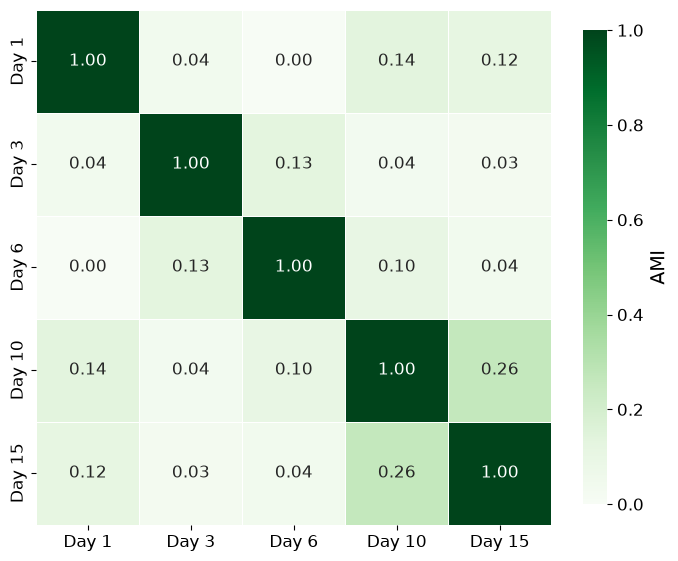

In [6]:
#Figure 5

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    adjusted_mutual_info_score,
    normalized_mutual_info_score,
    adjusted_rand_score,
)

# ============================================================
# Configuration
# ============================================================
DAYS = [1, 3, 6, 10, 15]

CSV_PATHS = {
    1:  "consensus_clusters_day1_K4.csv",
    3:  "consensus_clusters_day3_K3.csv",
    6:  "consensus_clusters_day6_K3.csv",
    10: "consensus_clusters_day10_K4.csv",
    15: "consensus_clusters_day15_K4.csv",
}

VG_FEATURE = "Vg protein normalized"

OUTPUT_AMI_CSV = "consensus_pairwise_AMI.csv"
OUTPUT_AMI_FIG = "consensus_pairwise_AMI_heatmap.png"
OUTPUT_TRIO_FIG = "consensus_pairwise_AMI_NMI_ARI.png"


# ============================================================
# Load consensus partitions
# ============================================================
labels_by_day = {}
for d, path in CSV_PATHS.items():
    df = pd.read_csv(path)
    df = df[df["feature"] != VG_FEATURE].copy()
    labels_by_day[d] = df.set_index("feature")["module"]
    print(f"Day {d:>2}: {len(df)} genes, {df['module'].nunique()} modules")

# Common feature set across all days
common = sorted(set.intersection(*[set(s.index) for s in labels_by_day.values()]))
print(f"\nGenes common to all days: {len(common)}")

# Aligned label vectors
labels_mat = {d: labels_by_day[d].loc[common].values for d in DAYS}


# ============================================================
# Pairwise AMI / NMI / ARI
# ============================================================
n_days = len(DAYS)
AMI = np.zeros((n_days, n_days))
NMI = np.zeros((n_days, n_days))
ARI = np.zeros((n_days, n_days))

for i, di in enumerate(DAYS):
    for j, dj in enumerate(DAYS):
        if i == j:
            AMI[i, j] = NMI[i, j] = ARI[i, j] = 1.0
        else:
            AMI[i, j] = adjusted_mutual_info_score(
                labels_mat[di], labels_mat[dj], average_method="arithmetic"
            )
            NMI[i, j] = normalized_mutual_info_score(
                labels_mat[di], labels_mat[dj], average_method="geometric"
            )
            ARI[i, j] = adjusted_rand_score(labels_mat[di], labels_mat[dj])

AMI_df = pd.DataFrame(AMI, index=DAYS, columns=DAYS).round(3)
NMI_df = pd.DataFrame(NMI, index=DAYS, columns=DAYS).round(3)
ARI_df = pd.DataFrame(ARI, index=DAYS, columns=DAYS).round(3)

print("\n=== AMI ===")
print(AMI_df.to_string())
print("\n=== NMI (geometric) ===")
print(NMI_df.to_string())
print("\n=== ARI ===")
print(ARI_df.to_string())

AMI_df.to_csv(OUTPUT_AMI_CSV)


# ============================================================
# Standalone AMI heatmap
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    AMI_df,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    vmin=0, vmax=1,
    ax=ax,
    cbar_kws={"shrink": 0.85, "label": "AMI"},
    xticklabels=[f"Day {d}" for d in DAYS],
    yticklabels=[f"Day {d}" for d in DAYS],
    annot_kws={"size": 12},
    linewidths=0.5,
    linecolor="white",
    square=True,
)
ax.set_xlabel("")
ax.set_ylabel("")
#ax.set_title(
#    "Pairwise consensus-partition similarity across age\n"
#    "Adjusted Mutual Information (chance-corrected)",
#    fontsize=12,)
plt.tight_layout()
plt.savefig(OUTPUT_AMI_FIG, dpi=200, bbox_inches="tight")
print(f"\nSaved: {OUTPUT_AMI_FIG}")
plt.show()



Day  1: 90 genes, modules = ['M1', 'M2', 'M3', 'M4']
Day  3: 90 genes, modules = ['M1', 'M2', 'M3']
Day  6: 90 genes, modules = ['M1', 'M2', 'M3']
Day 10: 90 genes, modules = ['M1', 'M2', 'M3', 'M4']
Day 15: 90 genes, modules = ['M1', 'M2', 'M3', 'M4']

=== Per-day module summary (post-labeling) ===

Day 1 (aligned):
                 n  mean_rho_VG
module_aligned                 
M1              32        0.024
M2              30       -0.045
M3              15        0.116
M4              13        0.033

Day 3 (aligned):
                 n  mean_rho_VG
module_aligned                 
M1              32        0.211
M2              29       -0.038
M4              29        0.444

Day 6 (aligned):
                 n  mean_rho_VG
module_aligned                 
M1              33        0.076
M2              18       -0.023
M4              39        0.204

Day 10 (aligned):
                 n  mean_rho_VG
module_aligned                 
M1              17         0.72
M2              15

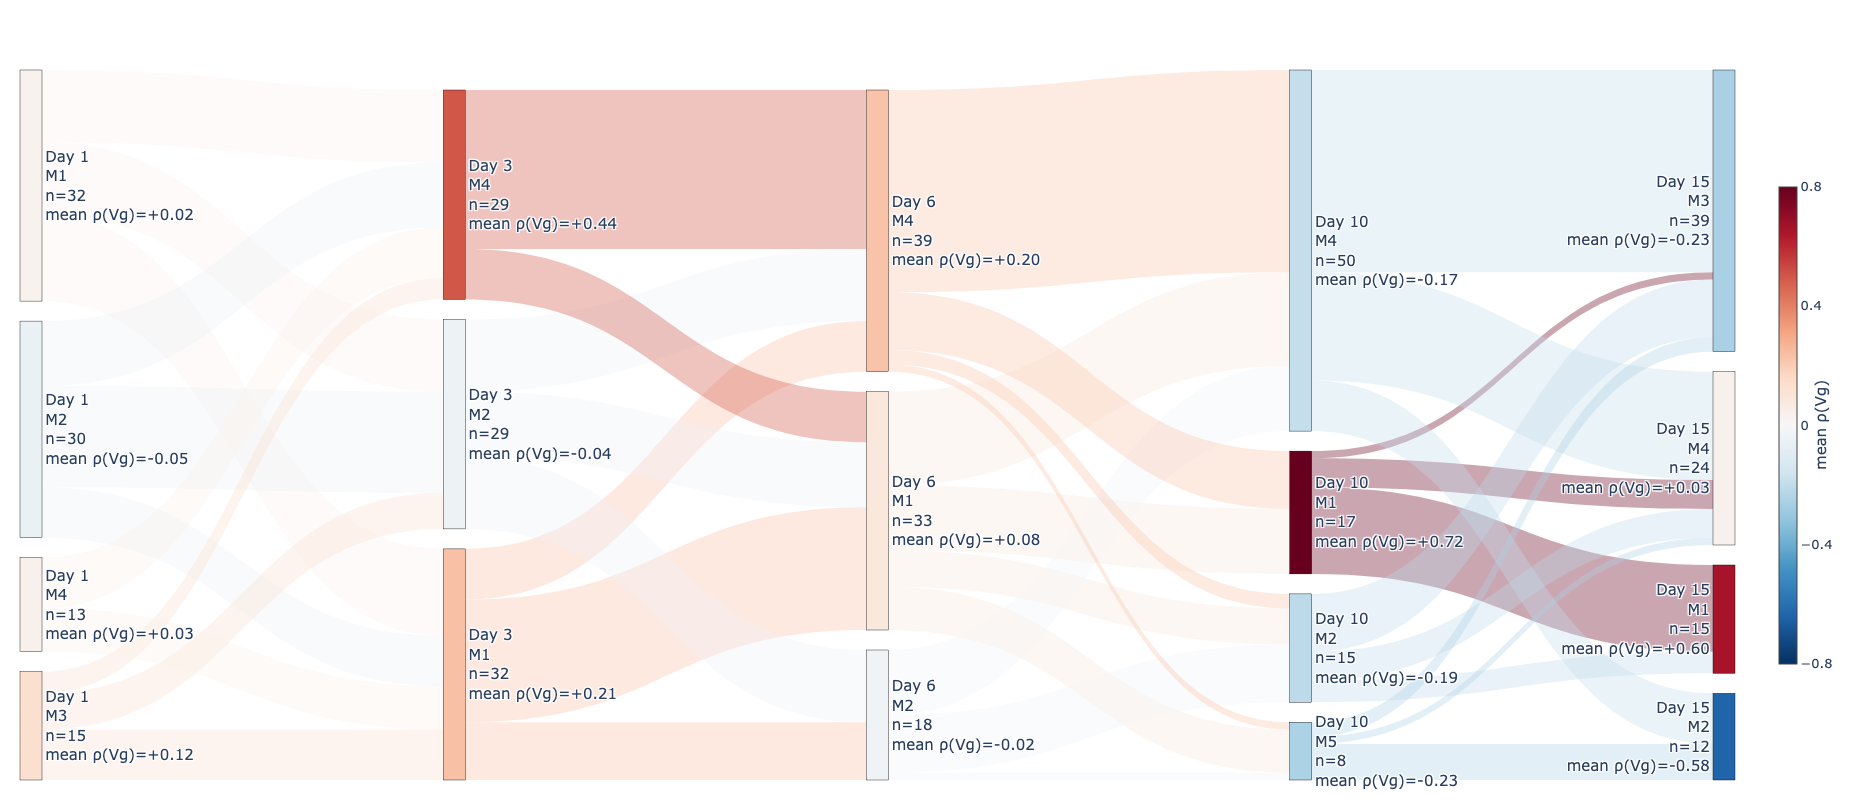

In [7]:
#Figure 6

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm
from scipy.optimize import linear_sum_assignment


# ============================================================
# Configuration
# ============================================================
DAYS = [1, 3, 6, 10, 15]

CSV_PATHS = {
    1:  "consensus_clusters_day1_K4.csv",
    3:  "consensus_clusters_day3_K3.csv",
    6:  "consensus_clusters_day6_K3.csv",
    10: "consensus_clusters_day10_K4.csv",
    15: "consensus_clusters_day15_K4.csv",
}

VG_FEATURE = "Vg protein normalized"
OUTPUT_HTML = "sankey_K_4_3_3_4_4.html"

# Days for which we re-align module labels by gene-overlap (Hungarian).
# Day 15 is intentionally excluded so its labels match the CSV exactly.
ALIGN_DAYS = [1, 3, 6, 10]
KEEP_RAW_DAYS = [15]


# ============================================================
# Helpers
# ============================================================
def relabel_first_day(day_df):
    """Largest module on Day 1 becomes M1, next largest M2, ..."""
    sizes = day_df["module"].value_counts().sort_values(ascending=False)
    mapping = {raw: f"M{i + 1}" for i, raw in enumerate(sizes.index)}
    out = day_df.copy()
    out["module_aligned"] = out["module"].map(mapping)
    return out


def align_modules_by_overlap(prev_df, curr_df):
    """Hungarian assignment of current modules to previous-day labels by
    maximum gene overlap. Unmatched modules get a new M-id."""
    prev_modules = sorted(prev_df["module_aligned"].unique())
    curr_modules = sorted(curr_df["module"].unique())

    overlap = np.zeros((len(prev_modules), len(curr_modules)), dtype=int)
    prev_sets = {m: set(prev_df.loc[prev_df["module_aligned"] == m, "feature"])
                 for m in prev_modules}
    curr_sets = {m: set(curr_df.loc[curr_df["module"] == m, "feature"])
                 for m in curr_modules}
    for i, pm in enumerate(prev_modules):
        for j, cm in enumerate(curr_modules):
            overlap[i, j] = len(prev_sets[pm] & curr_sets[cm])

    mapping = {}
    if overlap.size > 0:
        row_ind, col_ind = linear_sum_assignment(-overlap)
        for i, j in zip(row_ind, col_ind):
            if overlap[i, j] > 0:
                mapping[curr_modules[j]] = prev_modules[i]

    existing_nums = [int(m[1:]) for m in prev_modules
                     if m.startswith("M") and m[1:].isdigit()]
    next_id = max(existing_nums) + 1 if existing_nums else 1
    for cm in curr_modules:
        if cm not in mapping:
            mapping[cm] = f"M{next_id}"
            next_id += 1

    out = curr_df.copy()
    out["module_aligned"] = out["module"].map(mapping)
    return out


def keep_raw_labels(day_df):
    """Use the CSV's own `module` column as the displayed label."""
    out = day_df.copy()
    out["module_aligned"] = out["module"]
    return out


def rgba_from_score(score, scale, cmap_name="RdBu_r", alpha=1.0):
    cmap = mpl.colormaps.get_cmap(cmap_name)
    norm = TwoSlopeNorm(vmin=-scale, vcenter=0.0, vmax=scale)
    r, g, b, _ = cmap(norm(score))
    return f"rgba({int(255 * r)},{int(255 * g)},{int(255 * b)},{alpha})"


# ============================================================
# Load all five days, drop VG protein, label modules
# ============================================================
day_frames = {}
for day, path in CSV_PATHS.items():
    df = pd.read_csv(path)
    df = df[df["feature"] != VG_FEATURE].copy().reset_index(drop=True)
    day_frames[day] = df
    print(f"Day {day:>2}: {len(df)} genes, modules = "
          f"{sorted(df['module'].unique())}")

aligned_frames = {}
prev = None
for d in DAYS:
    if d in KEEP_RAW_DAYS:
        # Day 15: use raw CSV labels exactly
        aligned_frames[d] = keep_raw_labels(day_frames[d])
    elif prev is None:
        # First aligned day: size-rank relabel
        aligned_frames[d] = relabel_first_day(day_frames[d])
    else:
        # Other aligned days: Hungarian on overlap
        aligned_frames[d] = align_modules_by_overlap(prev, day_frames[d])
    # Only carry forward an "aligned" frame as the reference for next alignment
    if d in ALIGN_DAYS:
        prev = aligned_frames[d]

print("\n=== Per-day module summary (post-labeling) ===")
for d in DAYS:
    df = aligned_frames[d]
    summary = (
        df.groupby("module_aligned")
        .agg(n=("feature", "count"),
             mean_rho_VG=("Vg_rho", "mean"))
        .round(3)
        .sort_index()
    )
    tag = "(raw CSV labels)" if d in KEEP_RAW_DAYS else "(aligned)"
    print(f"\nDay {d} {tag}:")
    print(summary.to_string())


# ============================================================
# Module-level scores
# ============================================================
all_modules = []
for d in DAYS:
    df = aligned_frames[d]
    g = (
        df.groupby("module_aligned", as_index=False)
        .agg(n_genes=("feature", "count"),
             module_vg_mean_rho=("Vg_rho", "mean"))
    )
    g["Day"] = d
    all_modules.append(g)
module_scores = pd.concat(all_modules, ignore_index=True)


# ============================================================
# Day-to-day flows (true gene tracking)
# ============================================================
flows = []
for d1, d2 in zip(DAYS[:-1], DAYS[1:]):
    a = aligned_frames[d1][["feature", "module_aligned"]].rename(
        columns={"module_aligned": "module_from"})
    b = aligned_frames[d2][["feature", "module_aligned"]].rename(
        columns={"module_aligned": "module_to"})
    m = a.merge(b, on="feature", how="inner")
    m["Day_from"] = d1
    m["Day_to"] = d2
    flows.append(m)
flow_long = pd.concat(flows, ignore_index=True)

flow_df = (
    flow_long
    .groupby(["Day_from", "module_from", "Day_to", "module_to"], as_index=False)
    .agg(Count=("feature", "count"),
         Genes=("feature", lambda x: ", ".join(sorted(x))))
)

src = module_scores.rename(
    columns={"Day": "Day_from", "module_aligned": "module_from",
             "module_vg_mean_rho": "src_rho"})[
    ["Day_from", "module_from", "src_rho"]]
flow_df = flow_df.merge(src, on=["Day_from", "module_from"], how="left")


# ============================================================
# Build Sankey
# ============================================================
all_scores = module_scores["module_vg_mean_rho"].dropna().values
scale = max(np.max(np.abs(all_scores)), 1e-6)
# Round up to a nice tick for the colorbar
scale_tick = np.ceil(scale * 10) / 10  # e.g. 0.66 -> 0.7

node_labels, node_colors, node_index = [], [], {}
for d in DAYS:
    sub = module_scores[module_scores["Day"] == d].copy()
    sub = sub.sort_values(
        "module_aligned",
        key=lambda s: s.str[1:].astype(int)
    )
    for _, row in sub.iterrows():
        mod = row["module_aligned"]
        score = float(row["module_vg_mean_rho"]) \
            if pd.notna(row["module_vg_mean_rho"]) else 0.0
        n = int(row["n_genes"])
        label = f"Day {d}<br>{mod}<br>n={n}<br>mean ρ(Vg)={score:+.2f}"
        idx = len(node_labels)
        node_labels.append(label)
        node_colors.append(rgba_from_score(score, scale, alpha=1.0))
        node_index[(d, mod)] = idx

sources, targets, values, link_colors, hover_text = [], [], [], [], []
for _, row in flow_df.iterrows():
    d1, d2 = int(row["Day_from"]), int(row["Day_to"])
    m1, m2 = row["module_from"], row["module_to"]
    n = int(row["Count"])
    src_score = float(row["src_rho"]) if pd.notna(row["src_rho"]) else 0.0

    gene_list = (row["Genes"].split(", ")
                 if isinstance(row["Genes"], str) else [])
    preview = ", ".join(gene_list[:15])
    if len(gene_list) > 15:
        preview += ", ..."

    sources.append(node_index[(d1, m1)])
    targets.append(node_index[(d2, m2)])
    values.append(n)
    link_colors.append(rgba_from_score(src_score, scale, alpha=0.35))
    hover_text.append(
        f"Day {d1} {m1} → Day {d2} {m2}<br>"
        f"Genes: {n}<br>"
        f"Source mean ρ(Vg): {src_score:+.2f}<br>"
        f"{preview}"
    )

sankey_trace = go.Sankey(
    arrangement="snap",
    node=dict(
        pad=20, thickness=22,
        line=dict(color="black", width=0.4),
        label=node_labels, color=node_colors,
        hovertemplate="%{label}<extra></extra>",
    ),
    link=dict(
        source=sources, target=targets, value=values,
        color=link_colors, customdata=hover_text,
        hovertemplate="%{customdata}<extra></extra>",
    ),
)

# ------------------------------------------------------------
# Color-scale legend for mean ρ(Vg).
# Plotly Sankeys don't expose a colorbar, so we add an invisible
# scatter trace whose marker carries the colorbar.
# Convert matplotlib's RdBu_r to a Plotly colorscale.
# ------------------------------------------------------------
cmap = mpl.colormaps.get_cmap("RdBu_r")
plotly_colorscale = [
    [t, f"rgb({int(255*r)},{int(255*g)},{int(255*b)})"]
    for t, (r, g, b, _) in [(t, cmap(t)) for t in np.linspace(0, 1, 21)]
]

colorbar_trace = go.Scatter(
    x=[None], y=[None],
    mode="markers",
    marker=dict(
        colorscale=plotly_colorscale,
        cmin=-scale_tick,
        cmid=0.0,
        cmax=scale_tick,
        showscale=True,
        color=[0],
        colorbar=dict(
            title=dict(text="mean ρ(Vg)", side="right",
                       font=dict(size=15)),
            thickness=18,
            len=0.7,
            x=1.02,
            xanchor="left",
            y=0.5,
            tickvals=[-scale_tick, -scale_tick/2, 0, scale_tick/2, scale_tick],
            tickformat="+.2f",
            tickfont=dict(size=13),
        ),
    ),
    hoverinfo="none",
    showlegend=False,
)

fig = go.Figure(data=[sankey_trace, colorbar_trace])

# Hide the dummy scatter axes
fig.update_xaxes(visible=False)
fig.update_yaxes(visible=False)

fig.update_layout(
    title=dict(
        text="",
        x=0.5, xanchor="center",
    ),
    font=dict(size=15),
    width=1500,
    height=800,
    margin=dict(l=20, r=120, t=70, b=20),
    plot_bgcolor="white",
)

fig.show()

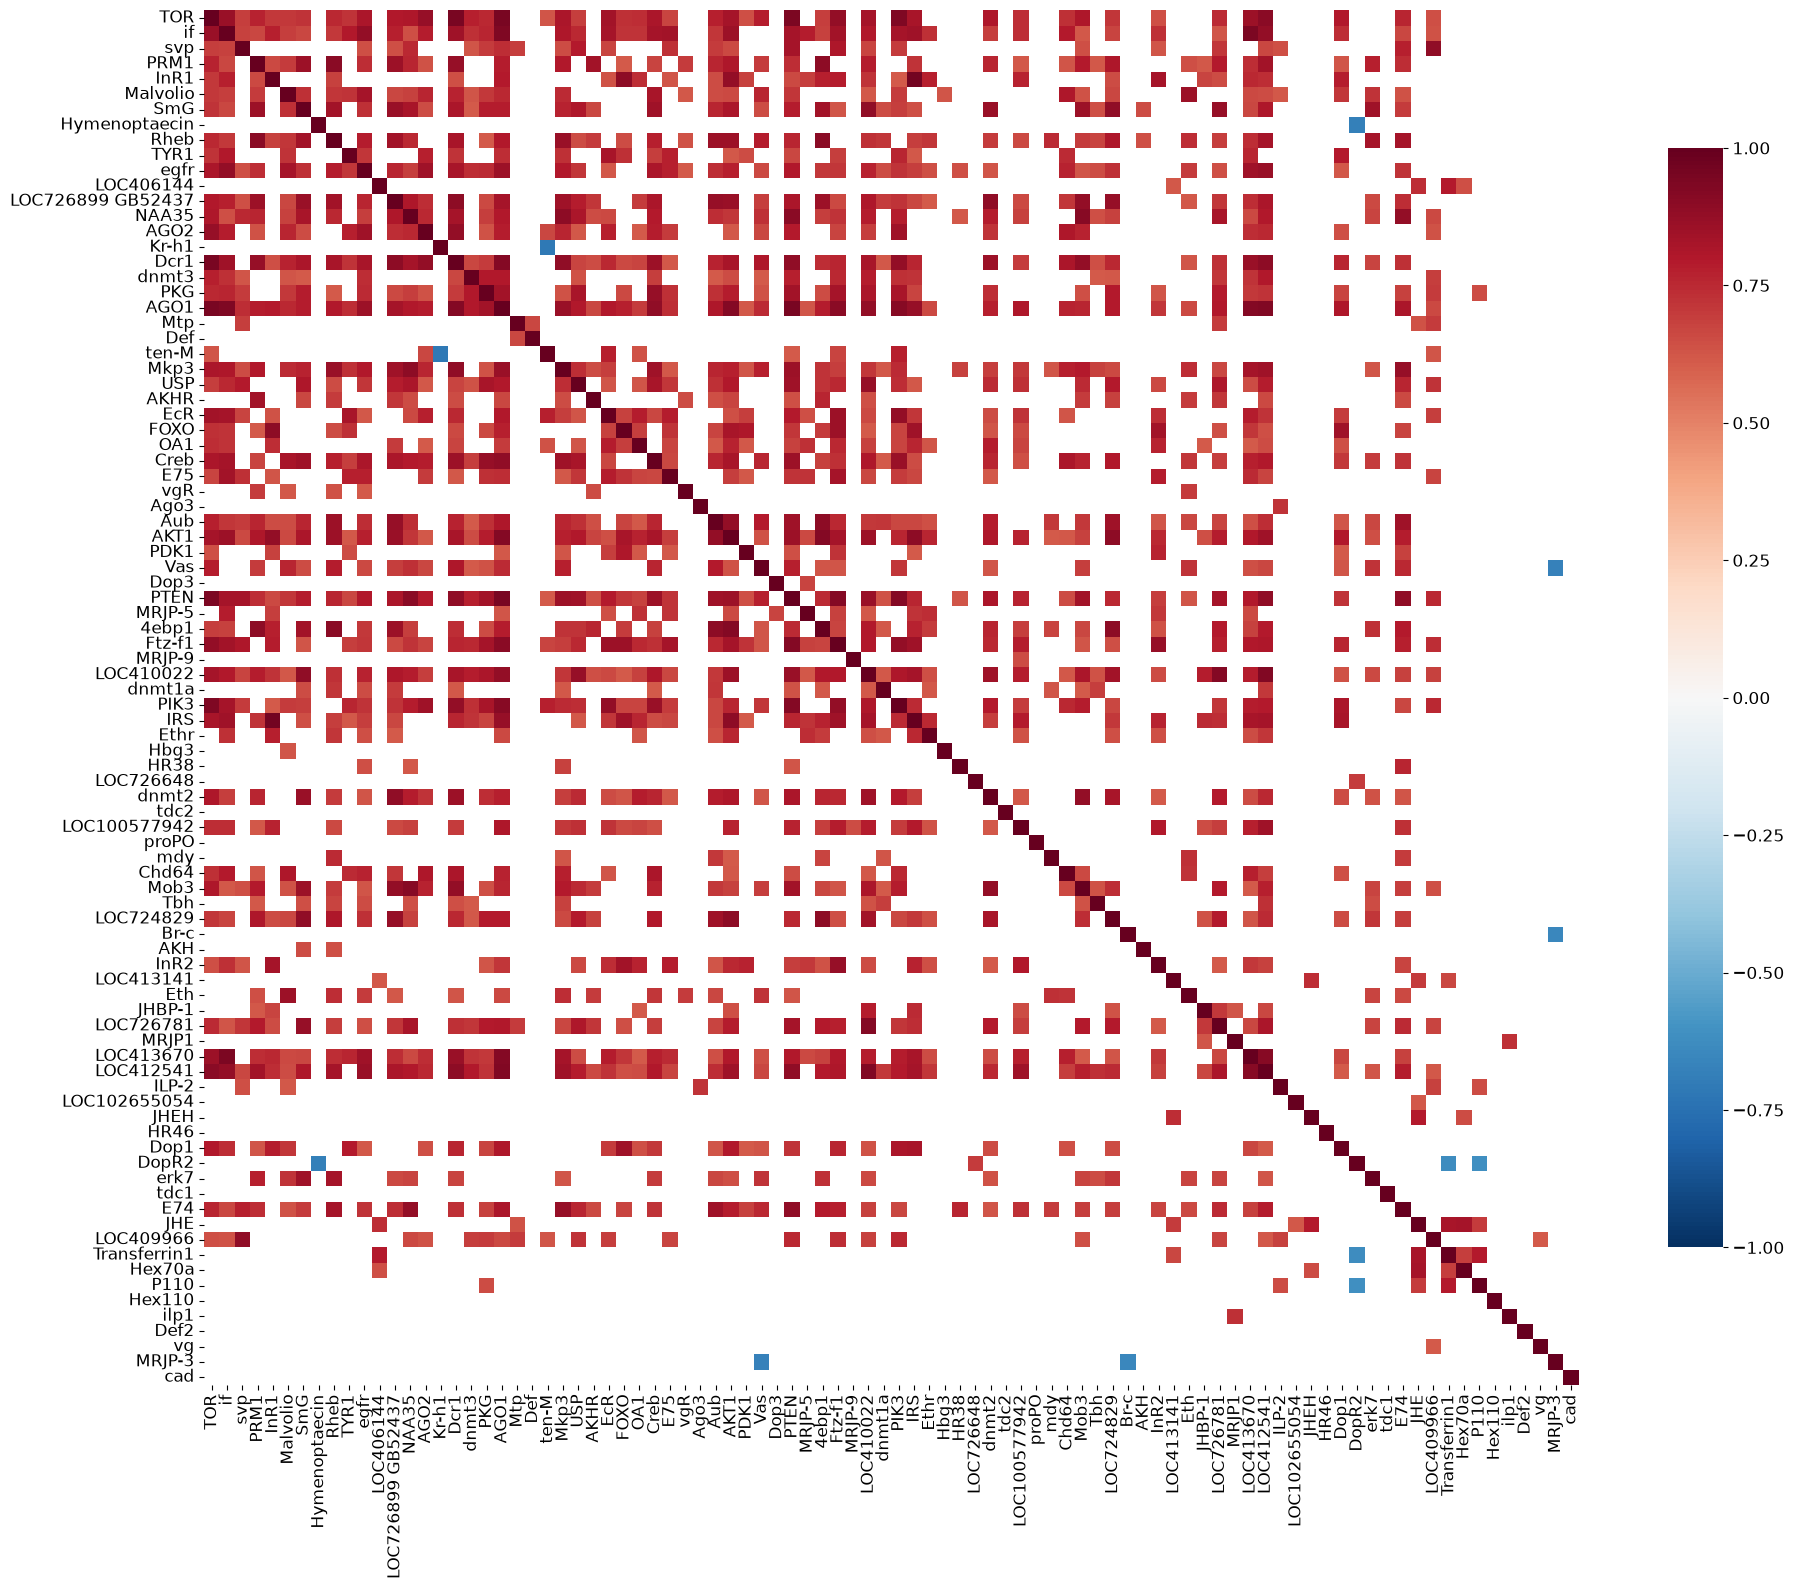

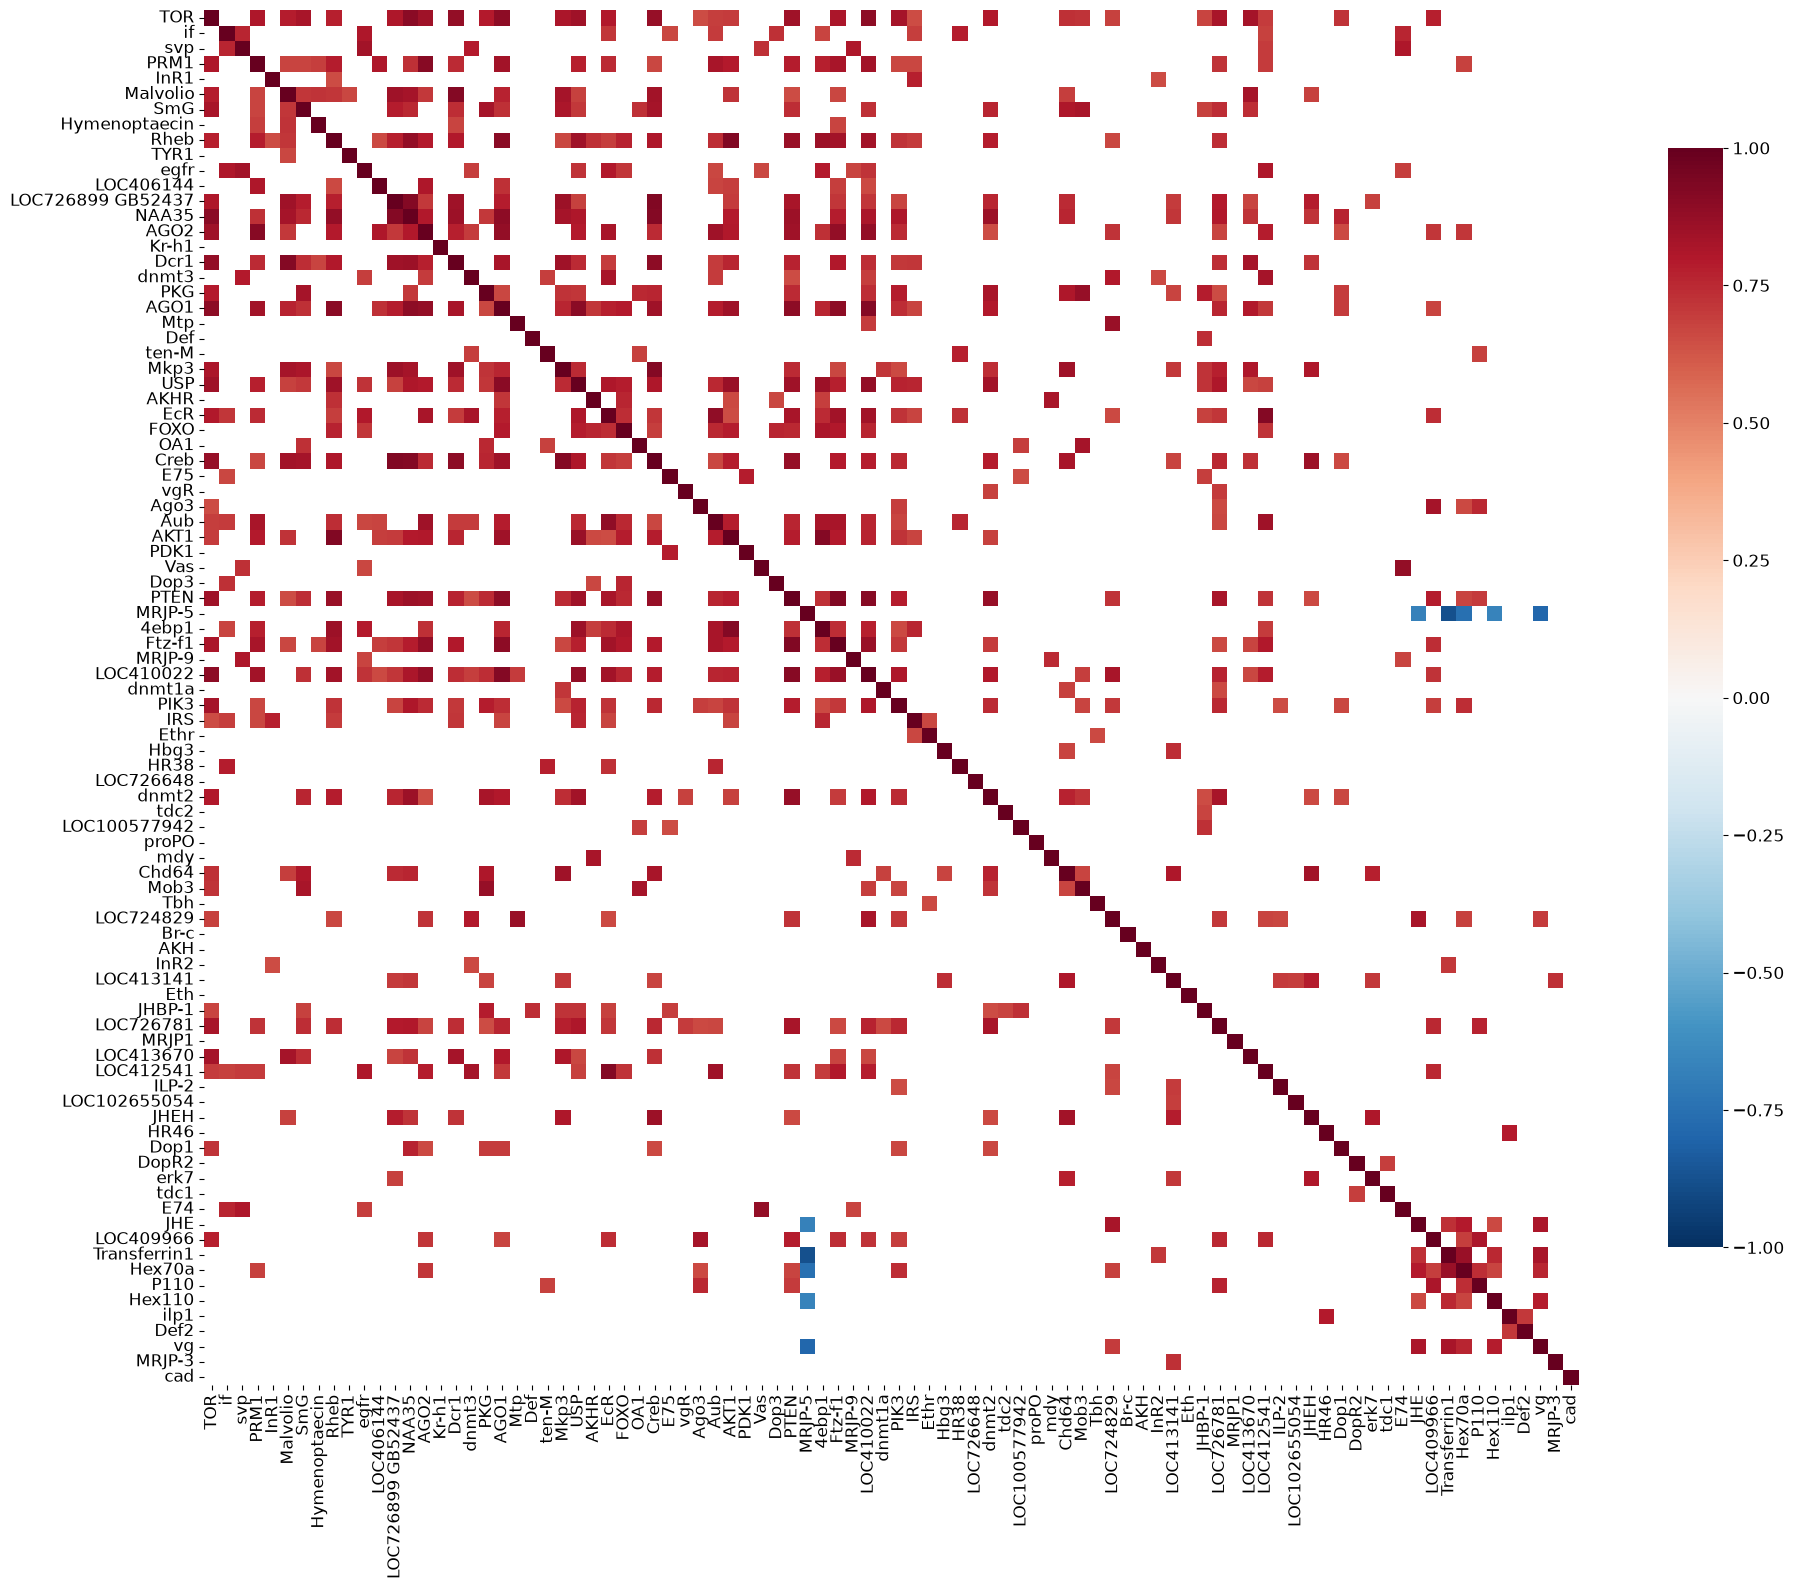

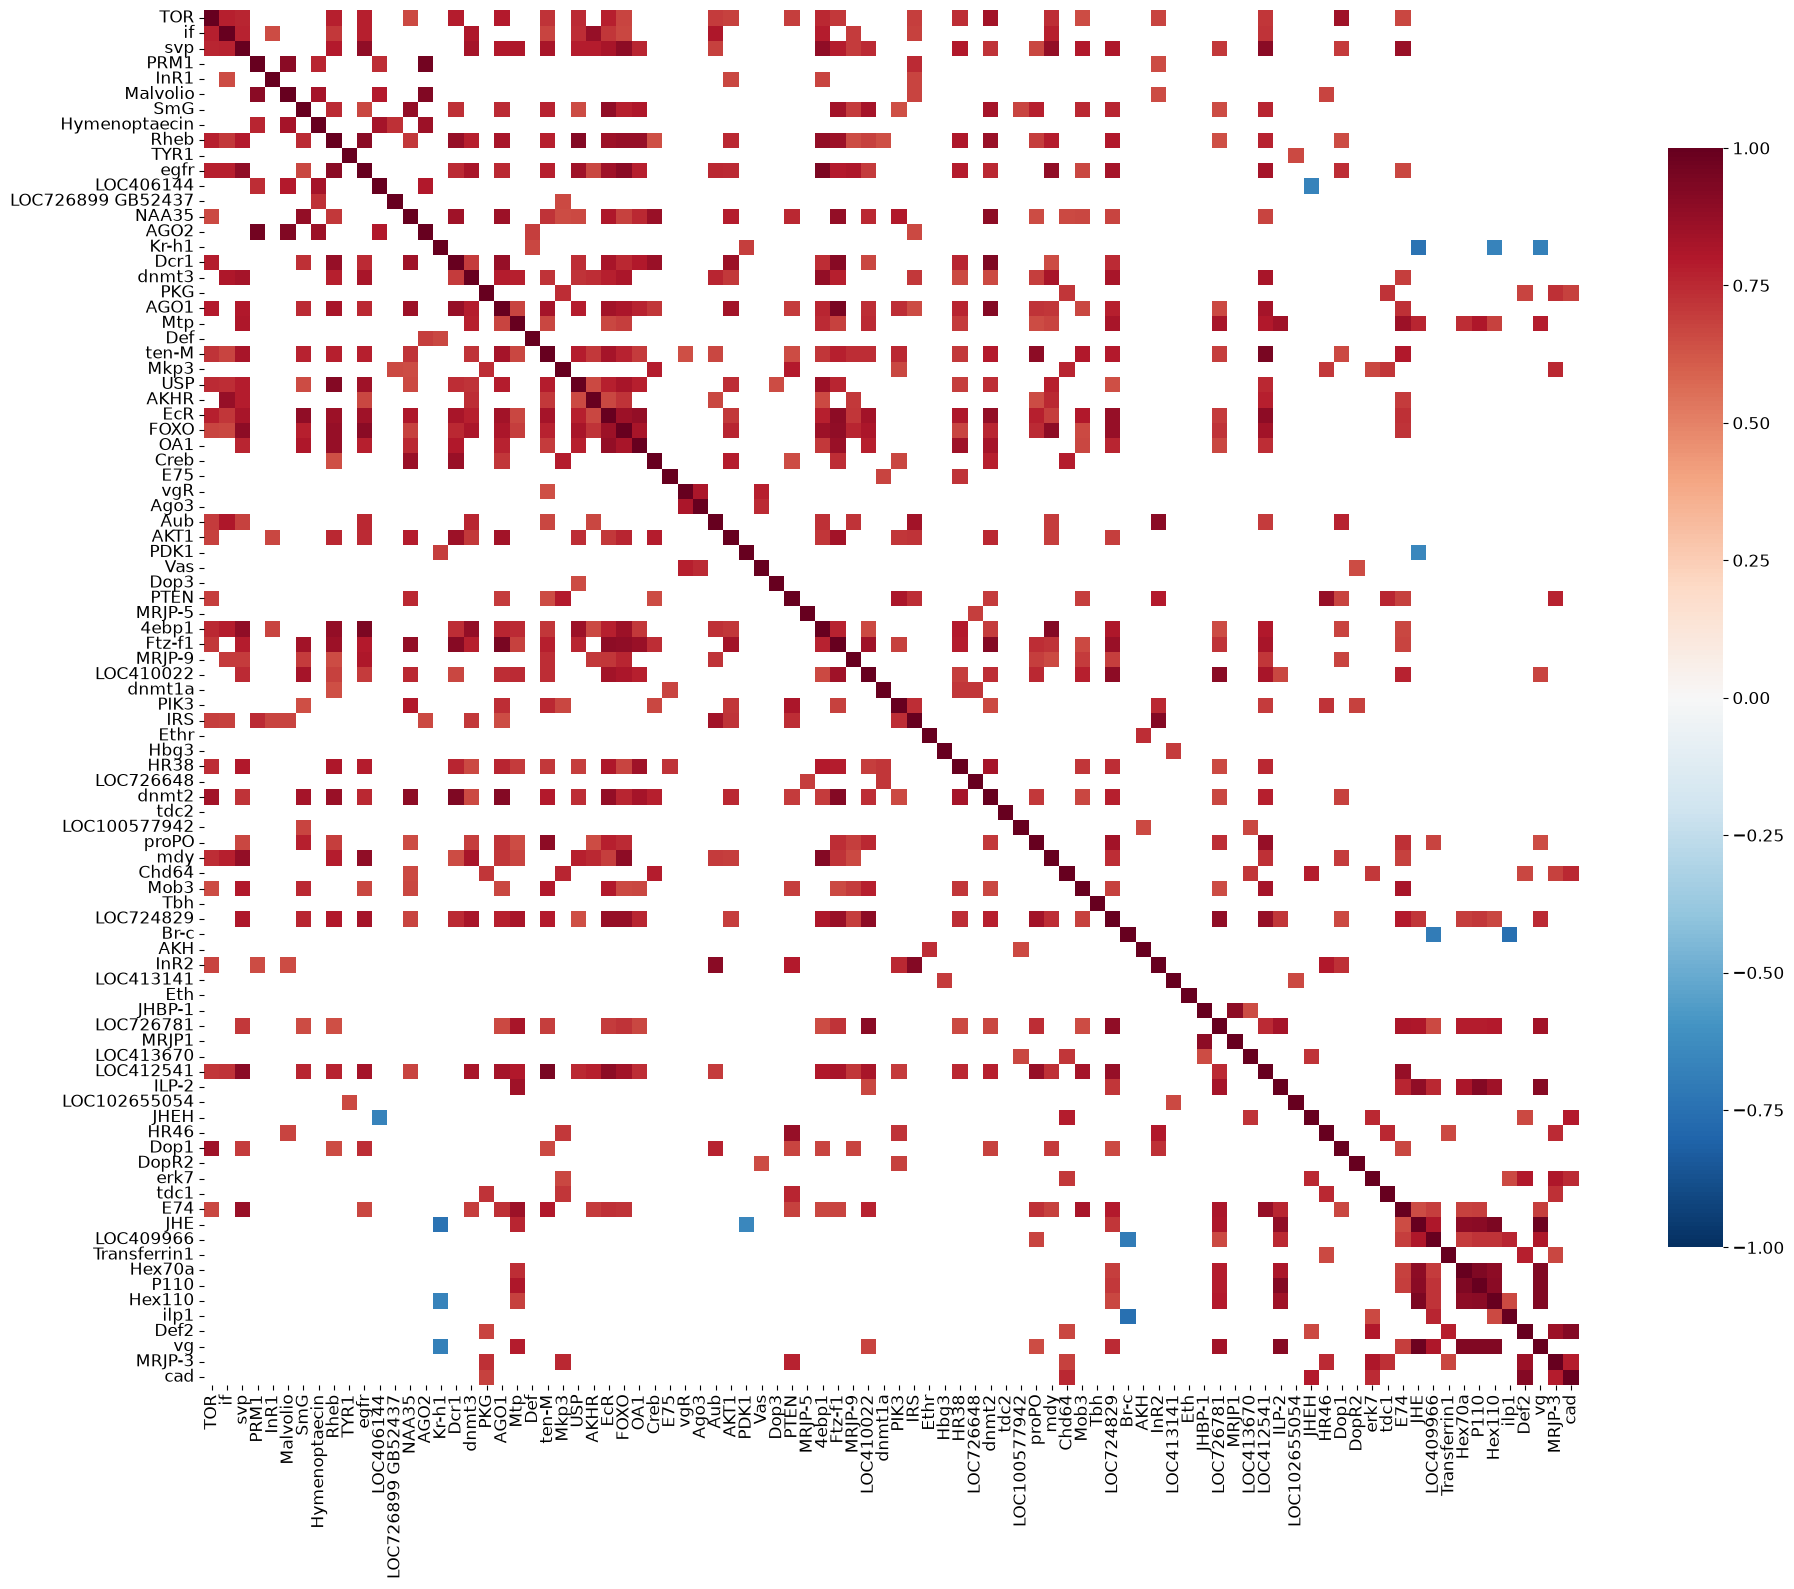

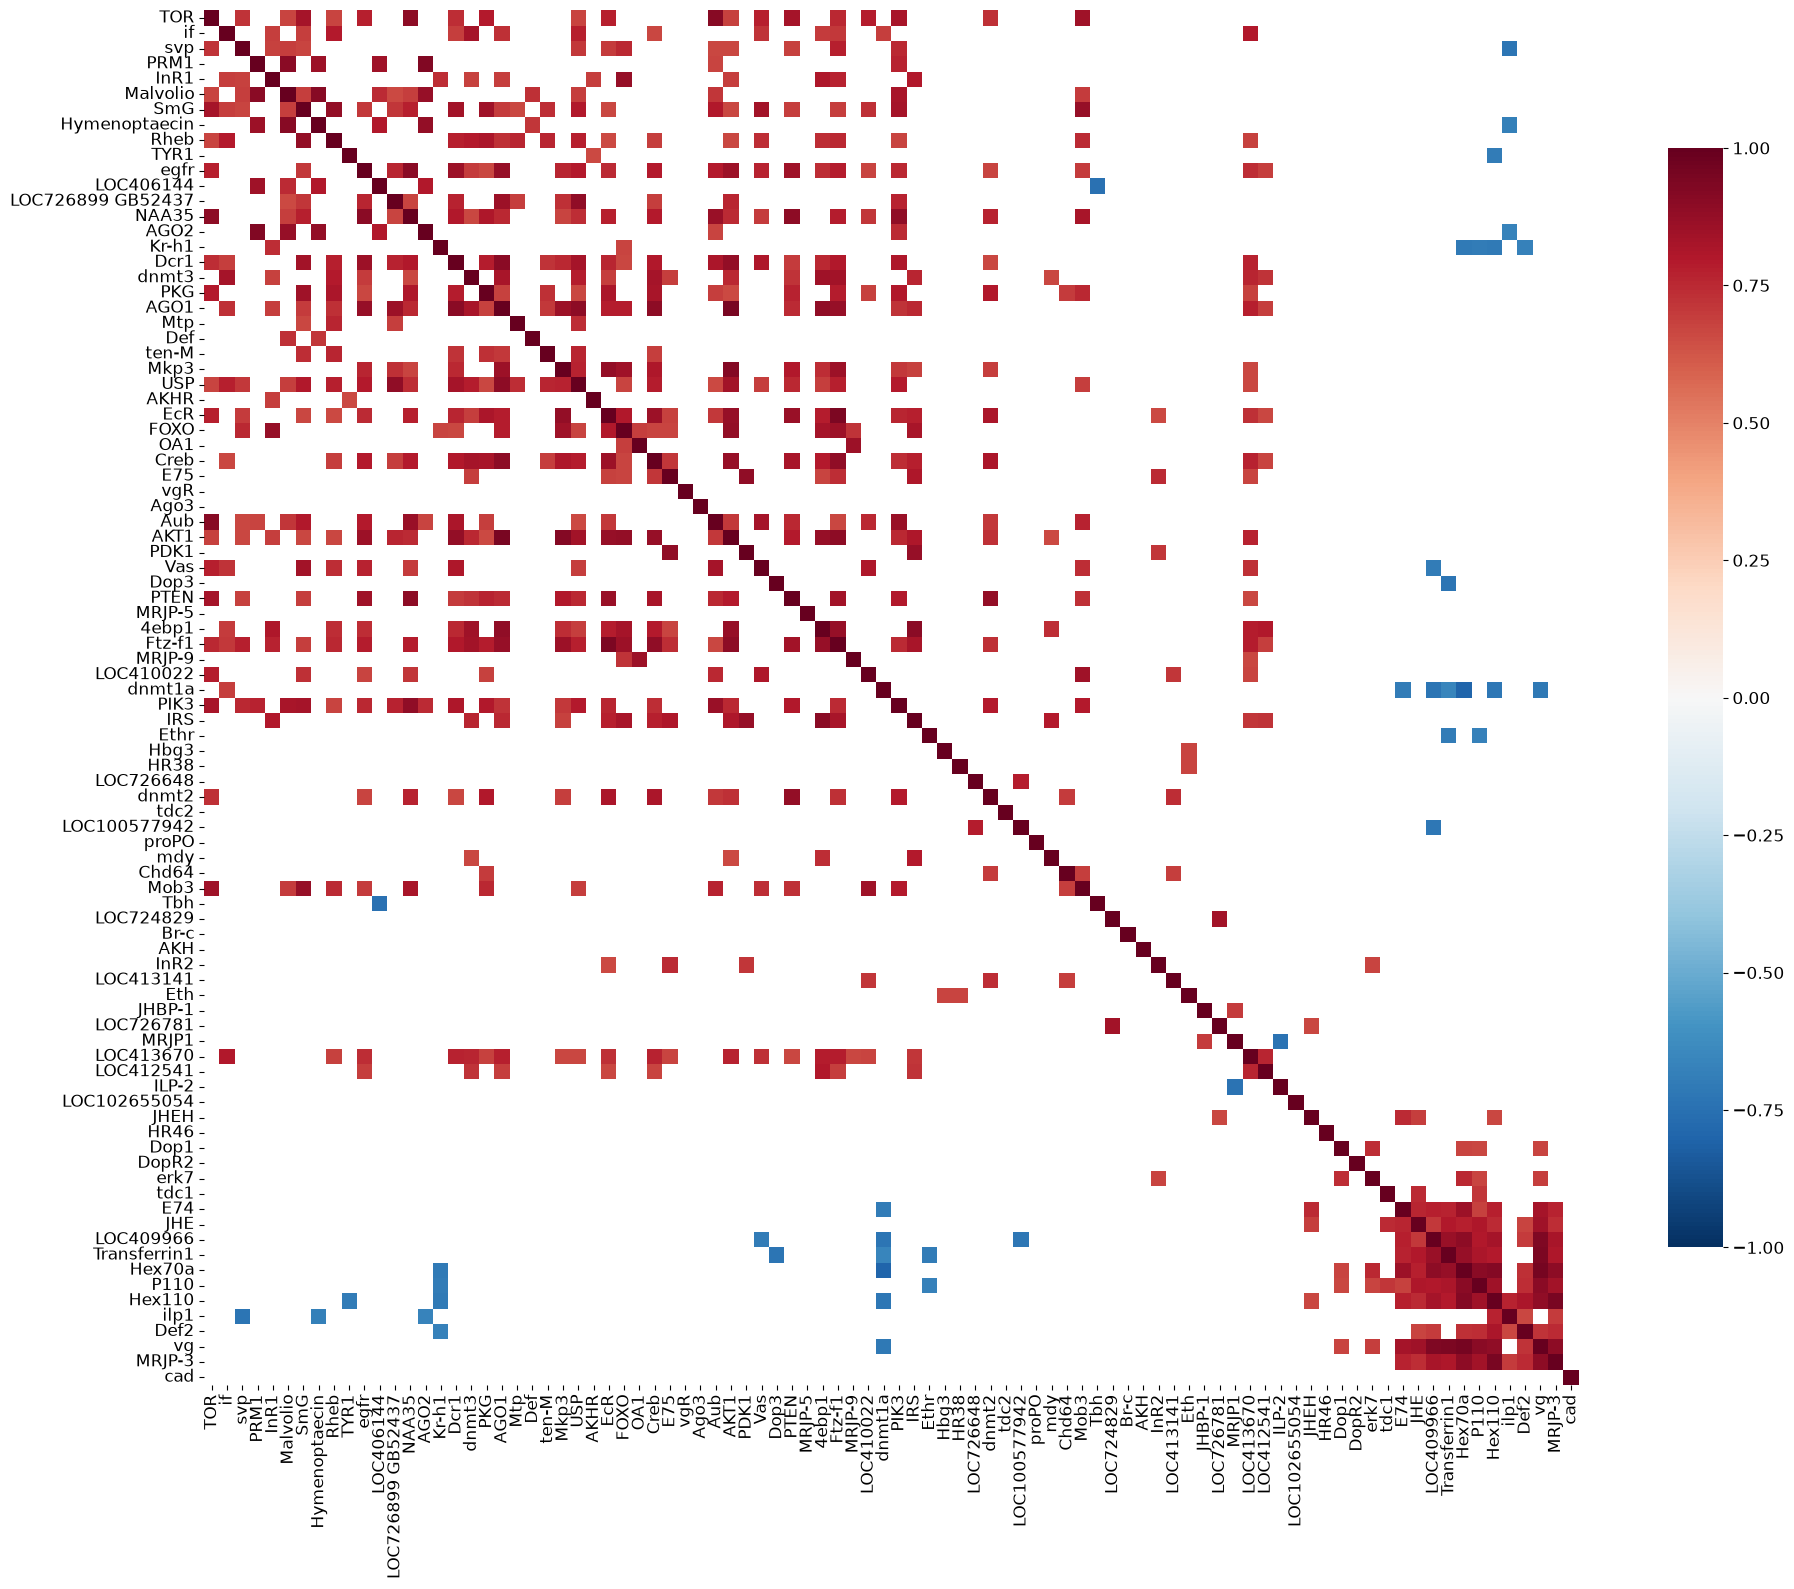

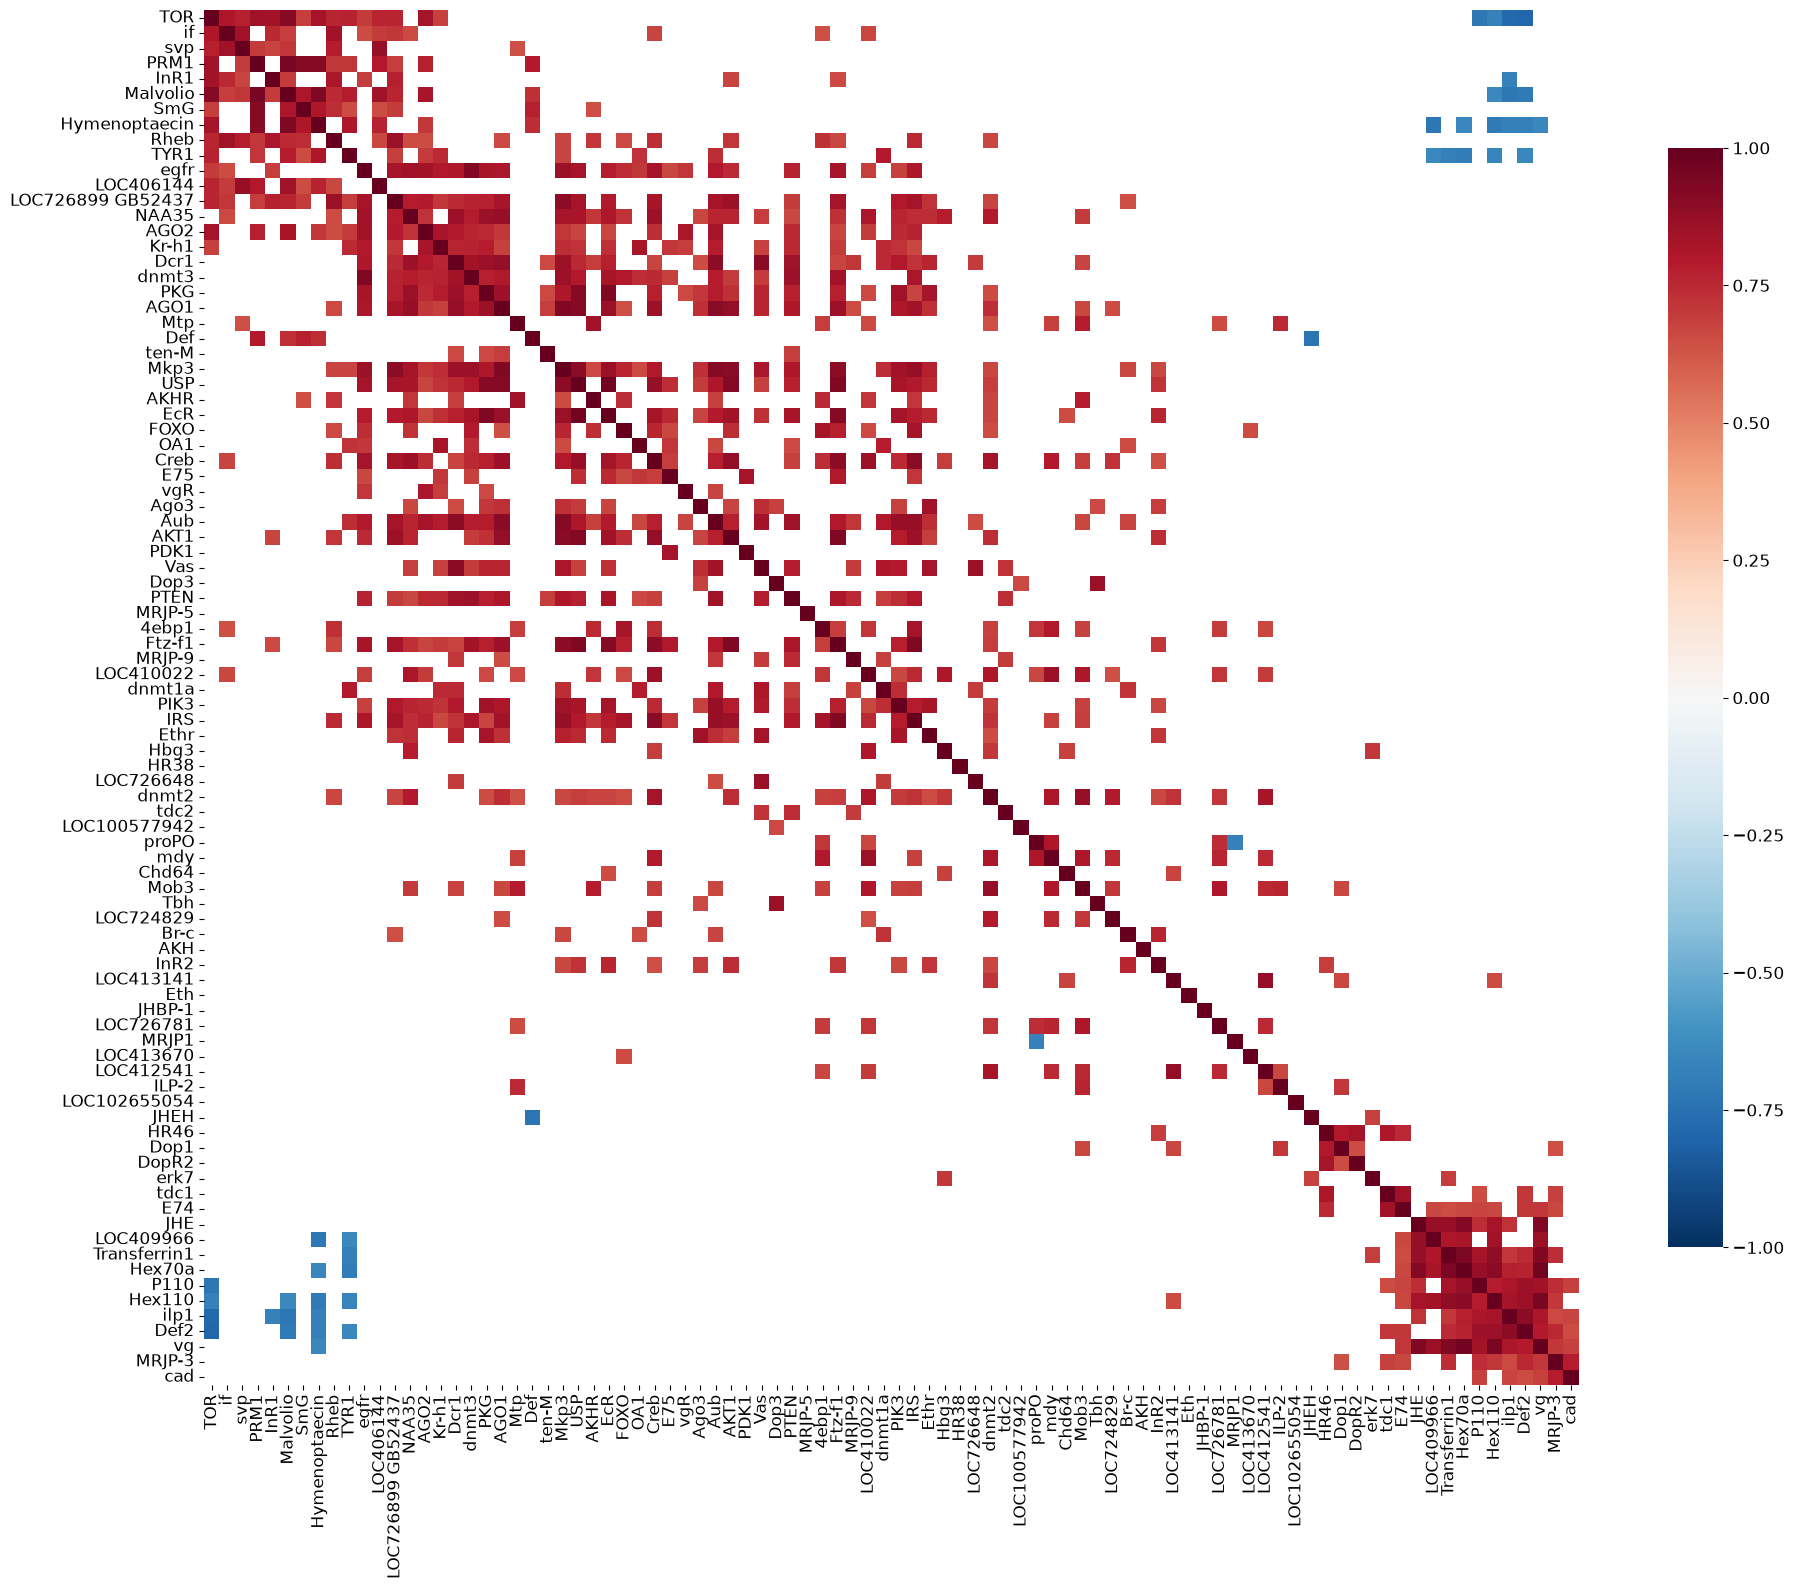

Heatmaps generated for each day.
Genes ordered by signed significant correlation to Vg at Day 15:
['TOR', 'if', 'svp', 'PRM1', 'InR1', 'Malvolio', 'SmG', 'Hymenoptaecin', 'Rheb', 'TYR1', 'egfr', 'LOC406144', 'LOC726899 GB52437', 'NAA35', 'AGO2', 'Kr-h1', 'Dcr1', 'dnmt3', 'PKG', 'AGO1', 'Mtp', 'Def', 'ten-M', 'Mkp3', 'USP', 'AKHR', 'EcR', 'FOXO', 'OA1', 'Creb', 'E75', 'vgR', 'Ago3', 'Aub', 'AKT1', 'PDK1', 'Vas', 'Dop3', 'PTEN', 'MRJP-5', '4ebp1', 'Ftz-f1', 'MRJP-9', 'LOC410022', 'dnmt1a', 'PIK3', 'IRS', 'Ethr', 'Hbg3', 'HR38', 'LOC726648', 'dnmt2', 'tdc2', 'LOC100577942', 'proPO', 'mdy', 'Chd64', 'Mob3', 'Tbh', 'LOC724829', 'Br-c', 'AKH', 'InR2', 'LOC413141', 'Eth', 'JHBP-1', 'LOC726781', 'MRJP1', 'LOC413670', 'LOC412541', 'ILP-2', 'LOC102655054', 'JHEH', 'HR46', 'Dop1', 'DopR2', 'erk7', 'tdc1', 'E74', 'JHE', 'LOC409966', 'Transferrin1', 'Hex70a', 'P110', 'Hex110', 'ilp1', 'Def2', 'vg', 'MRJP-3', 'cad']


In [18]:
#FIGURE 7

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# Load the data
df = pd.read_excel("Expression_raw_v1.xlsx")

AGE_COL = "Age (Days)"
PROTEIN_SUBSTR = "Vg protein"
DAYS = [1, 3, 6, 10, 15]
#DAYS = [15]
N = 91
ALPHA = 0.05

# Identify protein and gene columns
cols = [c for c in df.columns if PROTEIN_SUBSTR in str(c)]
protein_col = [c for c in cols if "normalized" in str(c).lower()][0] if any("normalized" in str(c).lower() for c in cols) else cols[0]

# Exclude metadata columns; add "Bee_ID" here if needed
exclude_cols = [AGE_COL, protein_col]
gene_cols = [
    c for c in df.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])
]

def robust_spearman(x, y):
    """
    Spearman correlation with protection against NaNs and constant vectors.
    """
    x = pd.Series(x)
    y = pd.Series(y)
    mask = x.notna() & y.notna()
    xx = x[mask]
    yy = y[mask]

    if len(xx) < 3 or xx.nunique() < 2 or yy.nunique() < 2:
        return np.nan, 1.0

    r, p = spearmanr(xx, yy)
    return r, p

def pairwise_corr_pval(df_sub):
    """
    Compute pairwise Spearman correlation and p-value matrices.
    """
    cols = list(df_sub.columns)
    n = len(cols)

    corr_mat = pd.DataFrame(np.nan, index=cols, columns=cols, dtype=float)
    p_mat = pd.DataFrame(np.nan, index=cols, columns=cols, dtype=float)

    for i in range(n):
        corr_mat.iat[i, i] = 1.0
        p_mat.iat[i, i] = 0.0
        for j in range(i + 1, n):
            r, p = robust_spearman(df_sub.iloc[:, i], df_sub.iloc[:, j])
            corr_mat.iat[i, j] = corr_mat.iat[j, i] = r
            p_mat.iat[i, j] = p_mat.iat[j, i] = p

    return corr_mat, p_mat

def bh_correct_pmatrix(p_df):
    """
    Apply Benjamini-Hochberg correction to the upper triangle of a p-value
    matrix and return a symmetric q-value matrix (diagonal = 0).
    """
    cols = list(p_df.columns)
    n = len(cols)

    indices = [(i, j) for i in range(n) for j in range(i + 1, n)]

    p_vals = [
        p_df.iat[i, j] if np.isfinite(p_df.iat[i, j]) else 1.0
        for i, j in indices
    ]

    q_df = pd.DataFrame(
        np.ones((n, n), dtype=float),
        index=cols,
        columns=cols
    )

    # Avoid np.fill_diagonal(q_df.values, ...), which can fail on read-only arrays
    for i in range(n):
        q_df.iat[i, i] = 0.0

    if not p_vals:
        return q_df

    _, q_vals, _, _ = multipletests(p_vals, method="fdr_bh")

    for idx, (i, j) in enumerate(indices):
        q_df.iat[i, j] = q_vals[idx]
        q_df.iat[j, i] = q_vals[idx]

    return q_df

# ---------------------------------------------------
# 1. Rank genes by absolute Spearman correlation
#    with Vg protein at Day 15
# ---------------------------------------------------
day15_df = df[df[AGE_COL] == 15]
vg15 = day15_df[protein_col]

cor_results = []
for g in gene_cols:
    r, p = robust_spearman(day15_df[g], vg15)

    #if np.isnan(r) or p >= ALPHA:
    if np.isnan(r):
        continue

    cor_results.append((g, r, p))

# Get top N by absolute significant correlation
top_n_raw = sorted(cor_results, key=lambda x: abs(x[1]), reverse=True)[:N]

if len(top_n_raw) == 0:
    raise ValueError("No genes passed the p-value threshold at Day 15.")

# Order by signed correlation with Vg at Day 15
ordered_top_genes = [g for g, r, p in sorted(top_n_raw, key=lambda x: x[1])]

# Optional: save Day 15 ranking
top_day15_df = pd.DataFrame(top_n_raw, columns=["Gene", "Spearman_r", "p_value"])
top_day15_df.to_csv("top_day15_vg_significant_genes.csv", index=False)

# ---------------------------------------------------
# 2. Create significance-filtered heatmaps for each day
# ---------------------------------------------------
for day in DAYS:
    day_df = df[df[AGE_COL] == day]

    # Subset to ordered genes
    subset_df = day_df[ordered_top_genes].copy()

    # Remove genes that are constant on this day
    valid_cols = [c for c in subset_df.columns if subset_df[c].nunique(dropna=True) > 1]
    subset_df = subset_df[valid_cols]

    if subset_df.shape[1] < 2:
        print(f"Day {day}: not enough variable genes to compute a heatmap.")
        continue

    # Compute correlation and p-value matrices
    corr_df, p_df = pairwise_corr_pval(subset_df)

    # Apply Benjamini-Hochberg correction; non-significant entries become NaN
    q_df = bh_correct_pmatrix(p_df)
    corr_sig = corr_df.where(q_df < ALPHA)

    # Keep diagonal visible
    for i in range(corr_sig.shape[0]):
        corr_sig.iat[i, i] = 1.0

    plt.figure(figsize=(20, 16))
    sns.heatmap(
        corr_sig,
        annot=False,
        fmt=".2f",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        xticklabels=corr_sig.columns,
        yticklabels=corr_sig.index,
        square=True,
        cbar_kws={"shrink": 0.8}
    )

    #plt.title(f"Day {day} (Spearman correlations, BH-adjusted q < {ALPHA})", fontsize=15)
    plt.tight_layout()
    # plt.savefig(f"spearman_heatmap_day_{day}_p_filtered.png", dpi=300)
    plt.show()
    plt.close()

print("Heatmaps generated for each day.")
print("Genes ordered by signed significant correlation to Vg at Day 15:")
print(ordered_top_genes)

Day 15 M2 (anti-Vg, n = 14): ['Malvolio', 'TOR', 'Hymenoptaecin', 'PRM1', 'SmG', 'LOC406144', 'Rheb', 'svp', 'InR1', 'Def', 'if', 'Kr-h1', 'TYR1', 'AGO2']
Day 15 M1 (pro-Vg, n = 13): ['P110', 'ilp1', 'Def2', 'vg', 'Hex70a', 'Hex110', 'Transferrin1', 'JHE', 'LOC409966', 'MRJP-3', 'cad', 'E74', 'tdc1']
Total genes plotted: 27
Saved: fig_M1_M2_corr_heatmap_day15.png


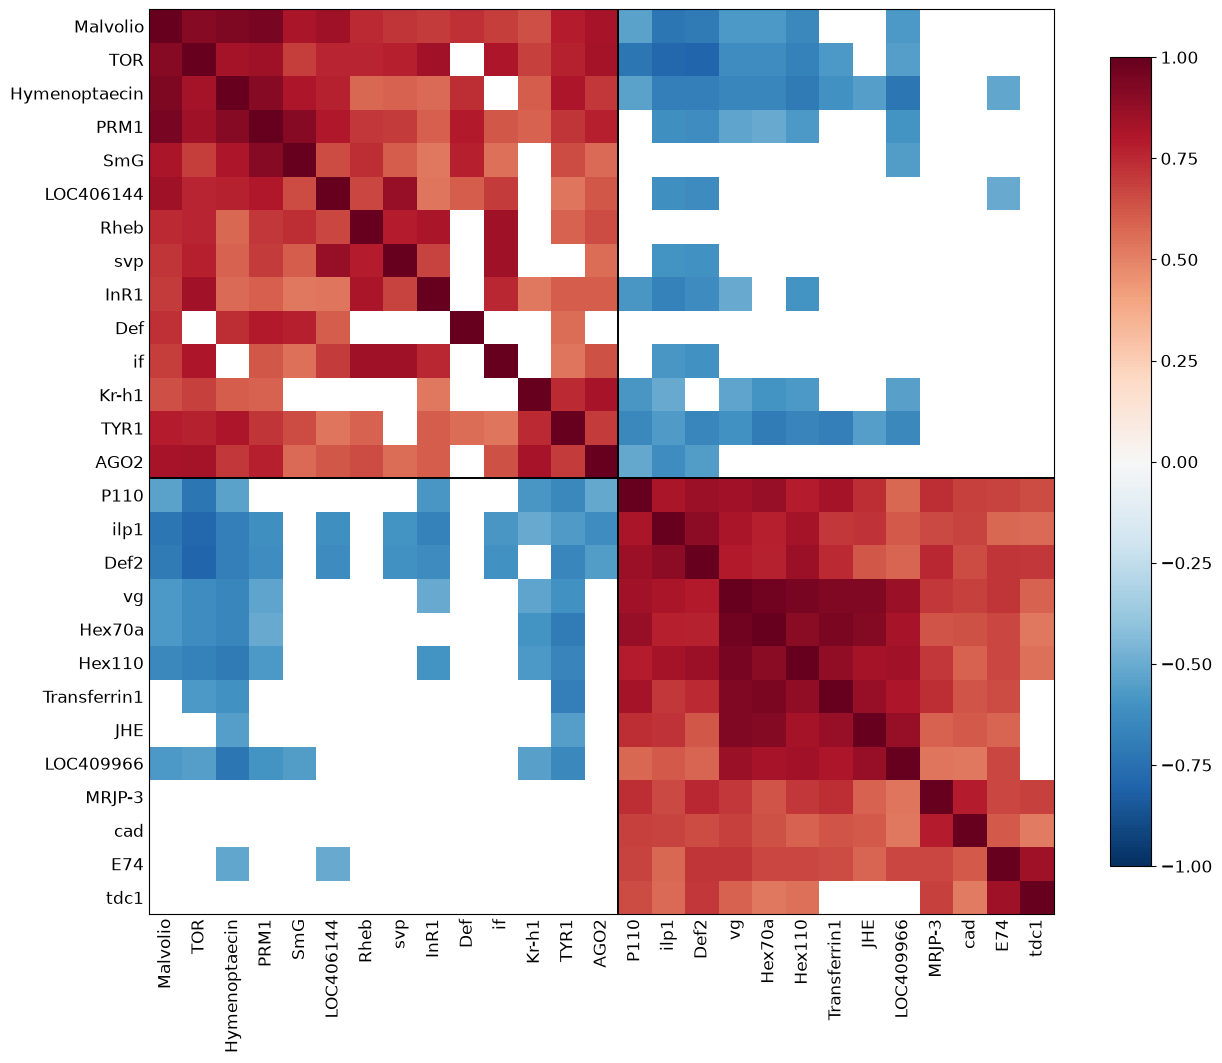


Significant edges (q < 0.08, off-diagonal): 214/351
Within M2 (anti-Vg) sig pairs:    77
Within M1 (pro-Vg) sig pairs:     75
Across M1-M2 sig pairs (negative): 62


In [17]:
# Figure 8

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# ============================================================
# Configuration
# ============================================================
EXCEL_FILE = "Expression_raw_v1.xlsx"
MEMBERSHIP_CSV = "consensus_clusters_day15_K4.csv"
AGE_COL = "Age (Days)"
DAY = 15
ALPHA = 0.05
INCLUDE_VG_PROTEIN = False     # set True to include VG protein as a row/col
OUTPUT_FIG = "fig_M1_M2_corr_heatmap_day15.png"


# ============================================================
# Load Day-15 module memberships
# ============================================================
mem = pd.read_csv(MEMBERSHIP_CSV)

VG_FEATURE = "Vg protein normalized"

m1 = mem[mem["module"] == "M1"].sort_values("stability", ascending=False)
m2 = mem[mem["module"] == "M2"].sort_values("stability", ascending=False)

m1_features = m1["feature"].tolist()
m2_features = m2["feature"].tolist()

if not INCLUDE_VG_PROTEIN:
    m1_features = [f for f in m1_features if f != VG_FEATURE]
    m2_features = [f for f in m2_features if f != VG_FEATURE]

# Stack: anti-Vg (M2) first, then pro-Vg (M1) — matches the layout of Fig 8
ordered_features = m2_features + m1_features
n_m1 = len(m1_features)
n_m2 = len(m2_features)
boundary = n_m2  # split between M2 (top/left) and M1 (bottom/right)

print(f"Day {DAY} M2 (anti-Vg, n = {n_m2}): {m2_features}")
print(f"Day {DAY} M1 (pro-Vg, n = {n_m1}): {m1_features}")
print(f"Total genes plotted: {len(ordered_features)}")


# ============================================================
# Compute pairwise Spearman correlations + BH-adjusted q-values
# ============================================================
df = pd.read_excel(EXCEL_FILE)
df.columns = df.columns.str.strip()

day_df = df[df[AGE_COL] == DAY][ordered_features].copy()

n = len(ordered_features)
rho = np.eye(n)
pval = np.ones((n, n))

for i in range(n):
    xi = day_df.iloc[:, i]
    for j in range(i + 1, n):
        xj = day_df.iloc[:, j]
        m = xi.notna() & xj.notna()
        xx = xi[m]; yy = xj[m]
        if len(xx) >= 3 and xx.nunique() > 1 and yy.nunique() > 1:
            r, p = spearmanr(xx, yy)
            rho[i, j] = rho[j, i] = r
            pval[i, j] = pval[j, i] = p
        else:
            rho[i, j] = rho[j, i] = 0.0
            pval[i, j] = pval[j, i] = 1.0

# BH on the upper triangle
iu = np.triu_indices(n, k=1)
p_flat = pval[iu]
_, q_flat, _, _ = multipletests(np.where(np.isfinite(p_flat), p_flat, 1.0),
                                method="fdr_bh")
qmat = np.ones((n, n))
qmat[iu] = q_flat
qmat[iu[1], iu[0]] = q_flat
np.fill_diagonal(qmat, 0.0)

# Mask non-significant cells (off-diagonal)
mask_sig = qmat < ALPHA
np.fill_diagonal(mask_sig, True)
plot_mat = np.where(mask_sig, rho, np.nan)


# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(13, 11))

cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad(color="white")
norm = TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)

im = ax.imshow(plot_mat, cmap=cmap, norm=norm, aspect="equal",
               interpolation="none")

# Boundary line between modules
ax.axhline(boundary - 0.5, color="black", lw=1.4)
ax.axvline(boundary - 0.5, color="black", lw=1.4)

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(ordered_features, rotation=90, fontsize=12)
ax.set_yticklabels(ordered_features, fontsize=12)
ax.tick_params(axis="x", which="both", length=0)
ax.tick_params(axis="y", which="both", length=0)

#ax.set_title(
#    f"Day {DAY} — M1 (pro-Vg) and M2 (anti-Vg) consensus modules\n"
#    f"Spearman correlations, BH-adjusted q < {ALPHA}",
#    fontsize=12,)

cbar = plt.colorbar(im, ax=ax, shrink=0.85, ticks=np.arange(-1, 1.01, 0.25))
cbar.outline.set_visible(True)

plt.tight_layout()
plt.savefig(OUTPUT_FIG, dpi=200, bbox_inches="tight")
print(f"Saved: {OUTPUT_FIG}")
plt.show()


# ============================================================
# Quick sanity print
# ============================================================
print(f"\nSignificant edges (q < {ALPHA}, off-diagonal): "
      f"{int(mask_sig[iu].sum())}/{len(p_flat)}")
print(f"Within M2 (anti-Vg) sig pairs:    "
      f"{int(mask_sig[:boundary, :boundary][np.triu_indices(boundary, k=1)].sum())}")
print(f"Within M1 (pro-Vg) sig pairs:     "
      f"{int(mask_sig[boundary:, boundary:][np.triu_indices(n_m1, k=1)].sum())}")
print(f"Across M1-M2 sig pairs (negative): "
      f"{int(mask_sig[:boundary, boundary:].sum())}")

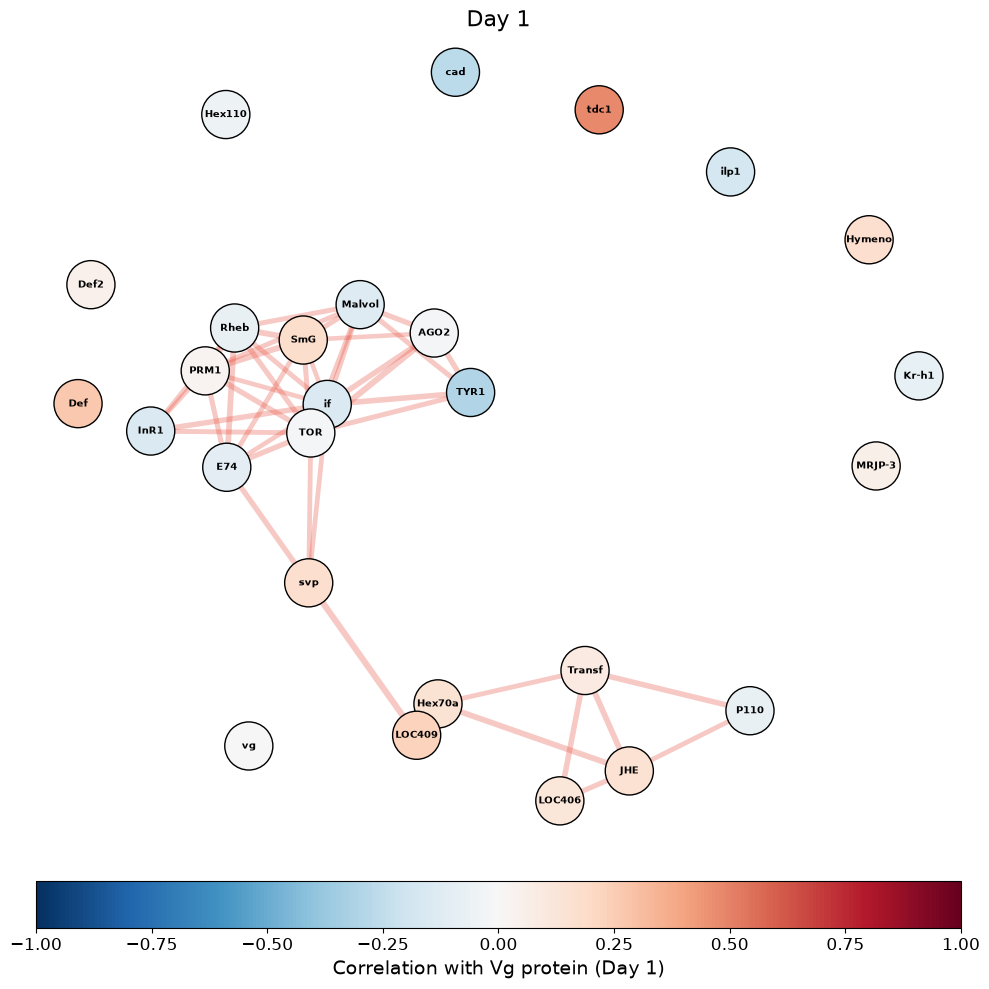

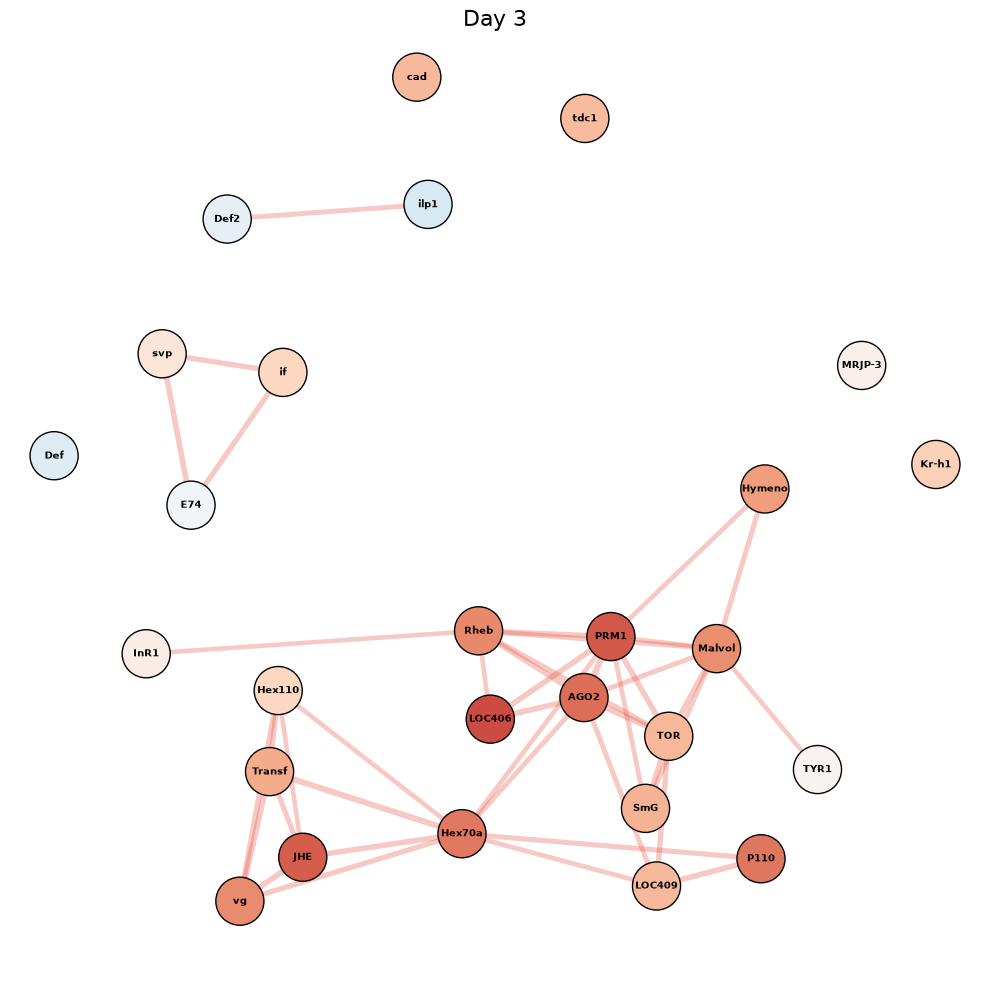

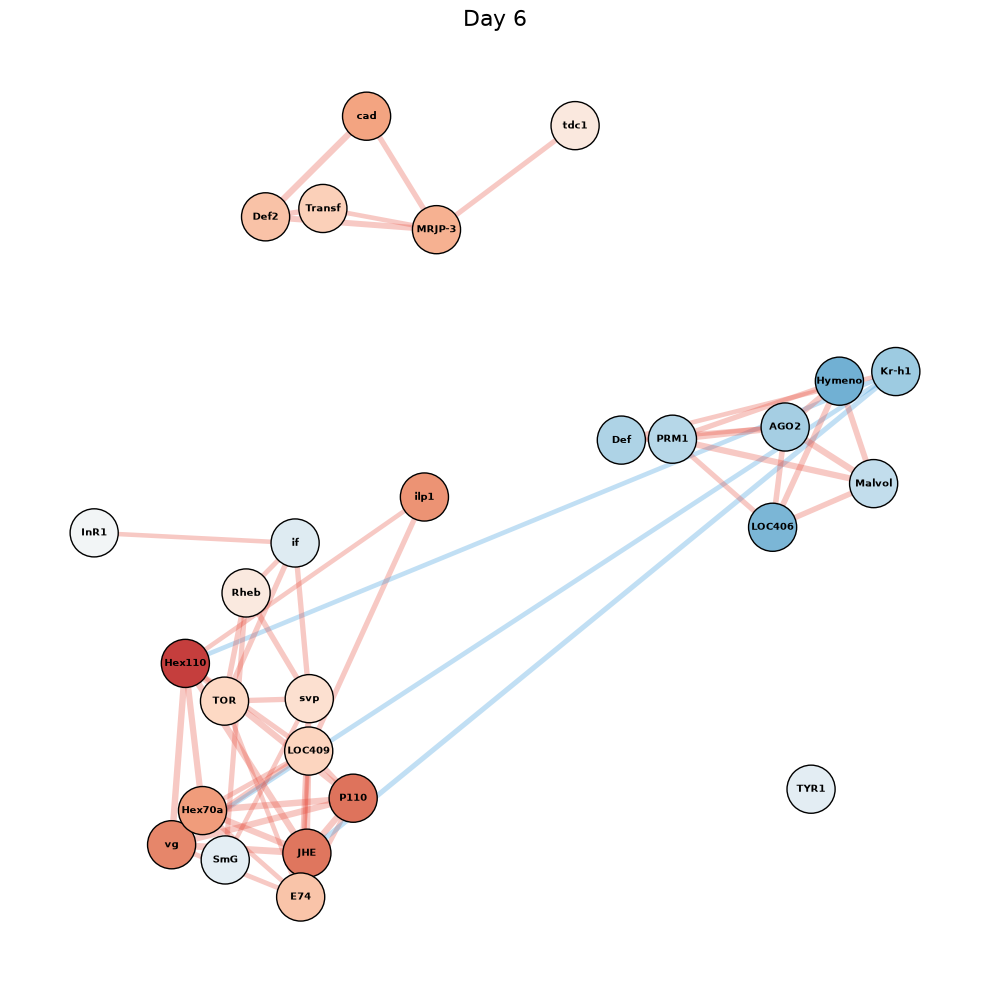

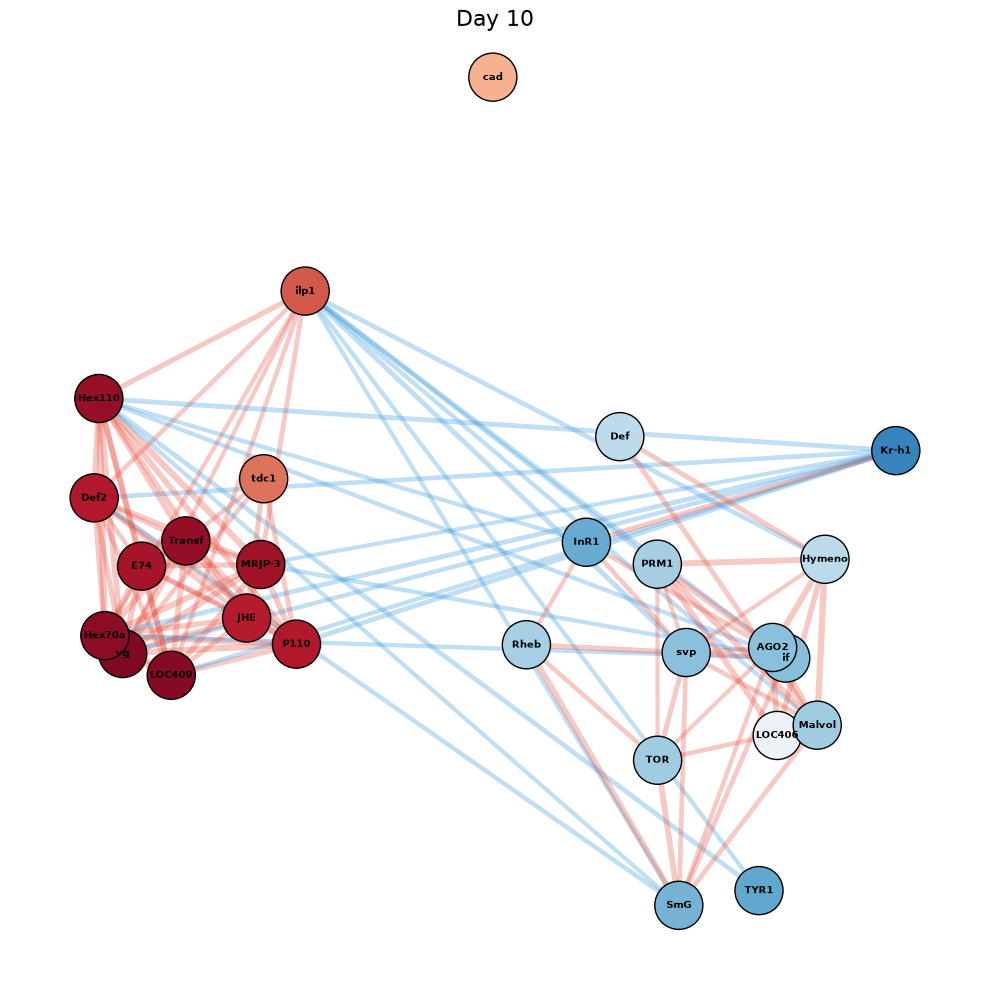

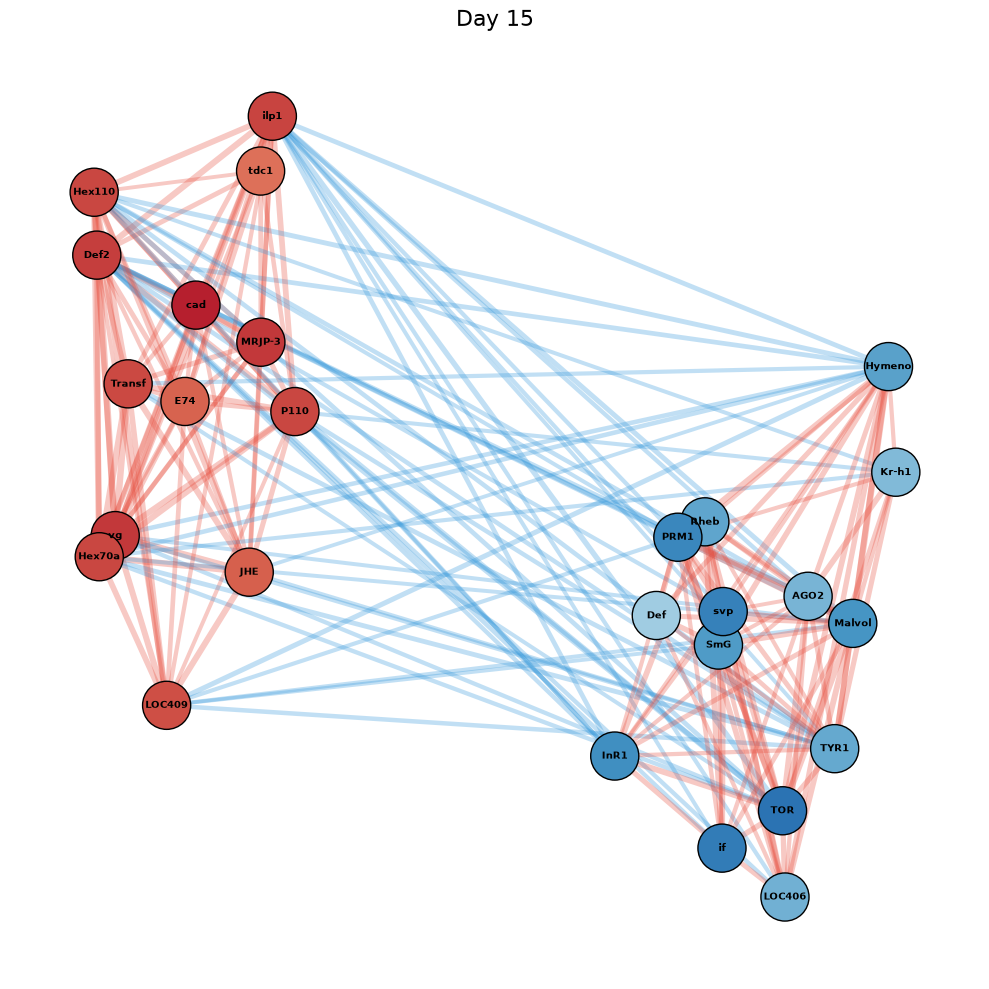

Completed: 5 individual plots generated for 27 M1+M2 genes.
Genes included: ['cad', 'MRJP-3', 'vg', 'Def2', 'ilp1', 'Hex110', 'P110', 'Hex70a', 'Transferrin1', 'LOC409966', 'JHE', 'E74', 'tdc1', 'Def', 'LOC406144', 'TYR1', 'Rheb', 'Hymenoptaecin', 'SmG', 'Malvolio', 'InR1', 'PRM1', 'svp', 'if', 'TOR', 'Kr-h1', 'AGO2']


In [19]:
#FIGURE 9

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests
import networkx as nx

# Load data
DATA_PATH = "Expression_raw_v1.xlsx"
df = pd.read_excel(DATA_PATH)

AGE_COL = "Age (Days)"
PROTEIN_SUBSTR = "Vg protein"
DAYS = [1, 3, 6, 10, 15]

# Identify protein and gene columns
cols = [c for c in df.columns if PROTEIN_SUBSTR in str(c)]
protein_col = [c for c in cols if "normalized" in str(c).lower()][0] if any("normalized" in str(c).lower() for c in cols) else cols[0]
gene_cols = [c for c in df.columns if c not in [AGE_COL, protein_col]]

MEMBERSHIP_CSV = "consensus_clusters_day15_K4.csv"
VG_FEATURE = "Vg protein normalized"
mem = pd.read_csv(MEMBERSHIP_CSV)
m1 = [g for g in mem[mem["module"] == "M1"]["feature"].tolist() if g != VG_FEATURE]
m2 = [g for g in mem[mem["module"] == "M2"]["feature"].tolist() if g != VG_FEATURE]
top_n_genes = m1 + m2
N = len(top_n_genes)

# Create individual plots
for day in DAYS:
    day_df = df[df[AGE_COL] == day]
    vg_day = day_df[protein_col].astype(float).values
    
    node_corrs = []
    labels = {}
    for g in top_n_genes:
        g_data = day_df[g].astype(float).values
        if np.std(g_data) > 1e-12 and np.std(vg_day) > 1e-12:
            #r, _ = pearsonr(g_data, vg_day)
            r, _ = spearmanr(g_data, vg_day)
            node_corrs.append(r if np.isfinite(r) else 0)
        else:
            node_corrs.append(0)
        labels[g] = g[:6]

    G = nx.Graph()
    G.add_nodes_from(top_n_genes)
    
    edge_list = []
    edge_colors = []
    edge_widths = []
    
    # Collect all pairwise correlations among Top N for this day
    pair_data = []
    for i in range(len(top_n_genes)):
        for j in range(i + 1, len(top_n_genes)):
            g1, g2 = top_n_genes[i], top_n_genes[j]
            d1, d2 = day_df[g1].values, day_df[g2].values
            if np.std(d1) > 1e-12 and np.std(d2) > 1e-12:
                #r, p = pearsonr(d1, d2)
                r, p = spearmanr(d1, d2)
                pair_data.append((g1, g2, float(r) if np.isfinite(r) else 0.0,
                                   float(p) if np.isfinite(p) else 1.0))
            else:
                pair_data.append((g1, g2, 0.0, 1.0))

    # Apply Benjamini-Hochberg correction across all pairs for this day
    if pair_data:
        p_raw = [d[3] for d in pair_data]
        _, q_vals, _, _ = multipletests(p_raw, method='fdr_bh')
    else:
        q_vals = []

    for idx, (g1, g2, r, _) in enumerate(pair_data):
        q = q_vals[idx]
        if q < 0.05 and np.abs(r) > 0.5:
            G.add_edge(g1, g2, weight=r)
            edge_list.append((g1, g2))
            edge_colors.append('#e74c3c' if r > 0 else '#3498db')
            edge_widths.append(abs(r) * 5)

    # Use a consistent figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))
    pos = nx.spring_layout(G, k=0.7, iterations=50, seed=42)
    
    # Draw graph elements
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edge_list, edge_color=edge_colors, width=edge_widths, alpha=0.3)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1200, node_color=node_corrs, 
                           cmap='RdBu_r', vmin=-1, vmax=1, edgecolors='black', linewidths=1)
    nx.draw_networkx_labels(G, pos, ax=ax, labels=labels, font_size=7, font_weight='bold')

    ax.set_title(f'Day {day}', fontsize=16)
    ax.axis('off')
    if day==1:
        # Colorbar fix: pass 'ax=ax' to tell matplotlib where to steal space
        sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=-1, vmax=1))
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.06, pad=0.02)
        cbar.set_label(f'Correlation with Vg protein (Day {day})')
    
    plt.tight_layout()
    #plt.savefig(f'M1_M2_network_day_{day}.png')
    plt.show()
    plt.close()

print(f"Completed: 5 individual plots generated for {N} M1+M2 genes.")
print("Genes included:", top_n_genes)

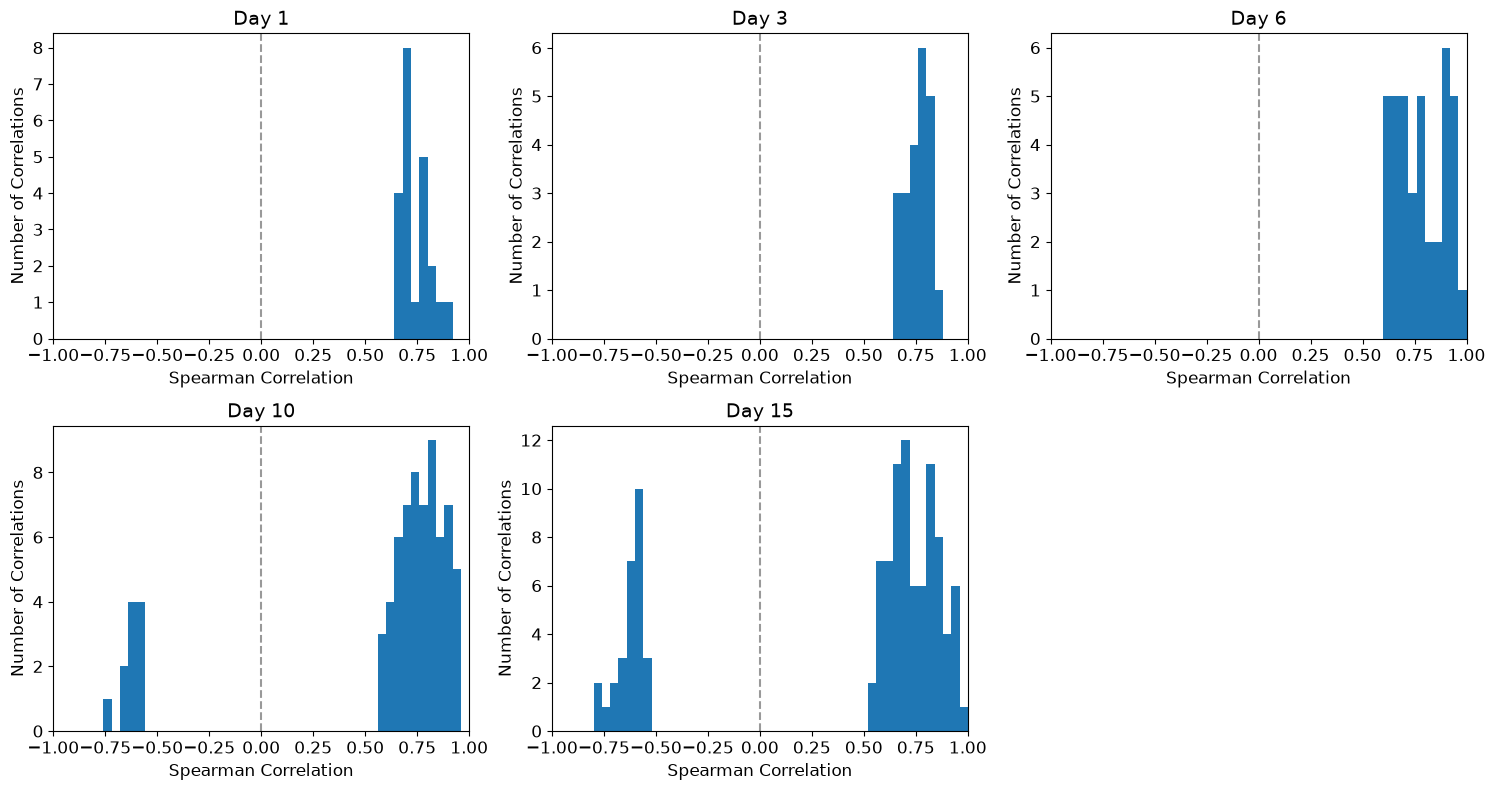

   Day  Number of significant pairs  Mean significant correlation  \
0    1                           22                      0.738102   
1    3                           22                      0.757448   
2    6                           39                      0.776546   
3   10                           73                      0.561306   
4   15                          109                      0.395117   

   Mean absolute significant correlation  Min significant correlation  \
0                               0.738102                     0.647059   
1                               0.757448                     0.658824   
2                               0.776546                     0.608824   
3                               0.748425                    -0.732353   
4                               0.715700                    -0.791133   

   Max significant correlation  
0                     0.888235  
1                     0.861765  
2                     0.982353  
3             

In [28]:
#FIGURE 10

import math
from statsmodels.stats.multitest import multipletests

alpha=0.05
hist_summary = []

# 5 panels in one figure
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for k, day in enumerate(DAYS):
    day_df = df[df[AGE_COL] == day].copy()
    subset_df = day_df[selected_genes].copy()

    # keep only variable genes on that day
    valid_cols = [c for c in subset_df.columns if subset_df[c].nunique(dropna=True) > 1]
    subset_df = subset_df[valid_cols]

    # Collect all pairwise correlations first, then apply BH
    pair_r = []
    pair_p = []

    if len(valid_cols) >= 2:
        for i in range(len(valid_cols)):
            for j in range(i + 1, len(valid_cols)):
                g1, g2 = valid_cols[i], valid_cols[j]
                r, p = robust_spearman(subset_df[g1], subset_df[g2])
                if np.isfinite(r):
                    pair_r.append(r)
                    pair_p.append(float(p) if np.isfinite(p) else 1.0)

    sig_corrs = []
    if pair_r:
        _, q_vals, _, _ = multipletests(pair_p, method='fdr_bh')
        sig_corrs = [pair_r[i] for i, q in enumerate(q_vals) if q < alpha]

    sig_corrs = np.array(sig_corrs, dtype=float)

    ax = axes[k]
    if len(sig_corrs) > 0:
        ax.hist(sig_corrs, bins=50, range=(-1, 1))
        ax.axvline(0, color="black", linestyle="--", alpha=0.4)
    else:
        ax.text(0.5, 0.5, "No significant pairs", ha="center", va="center", transform=ax.transAxes)

    ax.set_title(f"Day {day}")
    ax.set_xlim(-1, 1)
    ax.set_xlabel("Spearman Correlation", fontsize=12)
    ax.set_ylabel("Number of Correlations", fontsize=12)

    hist_summary.append({
        "Day": day,
        "Number of significant pairs": len(sig_corrs),
        "Mean significant correlation": np.mean(sig_corrs) if len(sig_corrs) > 0 else np.nan,
        "Mean absolute significant correlation": np.mean(np.abs(sig_corrs)) if len(sig_corrs) > 0 else np.nan,
        "Min significant correlation": np.min(sig_corrs) if len(sig_corrs) > 0 else np.nan,
        "Max significant correlation": np.max(sig_corrs) if len(sig_corrs) > 0 else np.nan,
    })

# remove unused last panel
if len(DAYS) < len(axes):
    for idx in range(len(DAYS), len(axes)):
        fig.delaxes(axes[idx])

#plt.suptitle(f"Histograms of BH-significant pairwise Spearman correlations (q < {alpha})", y=1.02)
plt.tight_layout()
plt.show()

hist_summary_df = pd.DataFrame(hist_summary)
#hist_summary_df.to_csv("significant_correlation_histogram_summary.csv", index=False)
print(hist_summary_df)

Protein column: Vg protein normalized
Number of BH-significant Day 15 gene-Vg correlations: 18
module_H: ['cad', 'MRJP-3', 'vg', 'Def2', 'ilp1', 'Hex110', 'P110', 'Hex70a', 'Transferrin1', 'LOC409966', 'JHE', 'E74']
module_L: ['TOR', 'if', 'svp', 'PRM1', 'InR1', 'Malvolio']
Total selected genes: 18


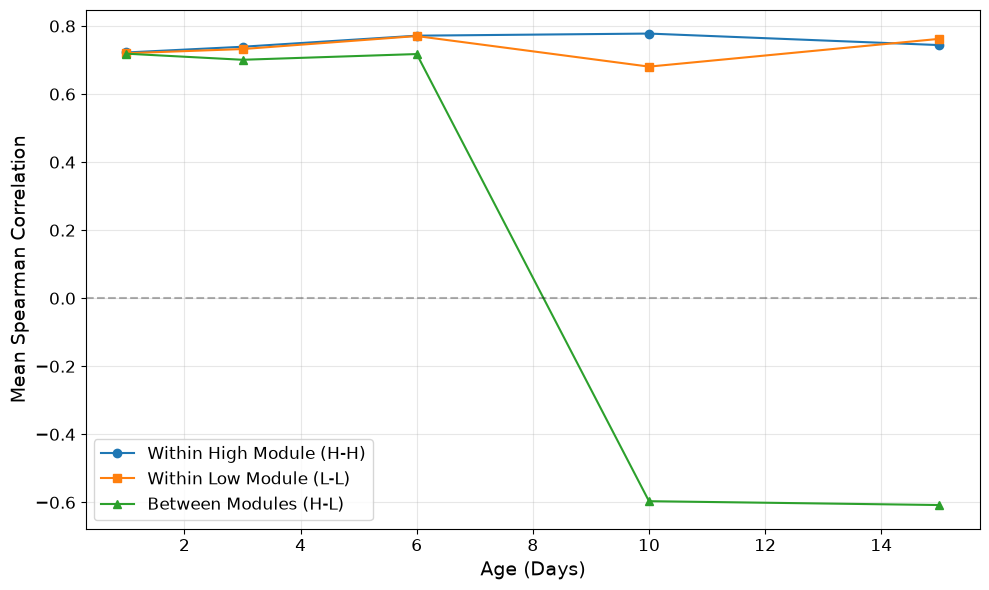

In [22]:
#FIGURE 11

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# Load data
DATA_PATH = "Expression_raw_v1.xlsx"
df = pd.read_excel(DATA_PATH)

AGE_COL = "Age (Days)"
PROTEIN_SUBSTR = "Vg protein"
DAYS = [1, 3, 6, 10, 15]
alpha = 0.05

# Identify protein column and gene columns
cols = [c for c in df.columns if PROTEIN_SUBSTR in str(c)]
protein_col = (
    [c for c in cols if "normalized" in str(c).lower()][0]
    if any("normalized" in str(c).lower() for c in cols)
    else cols[0]
)

gene_cols = [
    c for c in df.columns
    if c not in [AGE_COL, protein_col] and pd.api.types.is_numeric_dtype(df[c])
]

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def robust_spearman(x, y):
    """
    Spearman correlation with NaN/constant protection.
    Returns (rho, pvalue).
    """
    x = pd.Series(x)
    y = pd.Series(y)

    mask = x.notna() & y.notna()
    xx = x[mask]
    yy = y[mask]

    if len(xx) < 3 or xx.nunique() < 2 or yy.nunique() < 2:
        return np.nan, 1.0

    r, p = spearmanr(xx, yy)
    return float(r), float(p)


def pairwise_spearman_sig(df_sub, alpha=0.05):
    """
    Compute pairwise Spearman correlation and p-value matrices.
    Non-significant correlations are set to NaN in corr_sig.
    """
    cols = list(df_sub.columns)
    n = len(cols)

    corr = pd.DataFrame(np.nan, index=cols, columns=cols, dtype=float)
    pval = pd.DataFrame(np.nan, index=cols, columns=cols, dtype=float)

    for i in range(n):
        corr.iat[i, i] = 1.0
        pval.iat[i, i] = 0.0
        for j in range(i + 1, n):
            r, p = robust_spearman(df_sub.iloc[:, i], df_sub.iloc[:, j])
            corr.iat[i, j] = r
            corr.iat[j, i] = r
            pval.iat[i, j] = p
            pval.iat[j, i] = p

    # Apply BH correction to upper triangle
    indices = [(i, j) for i in range(n) for j in range(i + 1, n)]
    p_raw = [
        pval.iat[i, j] if np.isfinite(pval.iat[i, j]) else 1.0
        for i, j in indices
    ]

    q_mat = pd.DataFrame(
        np.ones((n, n), dtype=float),
        index=cols,
        columns=cols
    )

    # Avoid np.fill_diagonal(q_mat.values, ...), which can fail on read-only arrays
    for i in range(n):
        q_mat.iat[i, i] = 0.0

    if p_raw:
        _, q_vals, _, _ = multipletests(p_raw, method="fdr_bh")
        for idx, (i, j) in enumerate(indices):
            q_mat.iat[i, j] = q_vals[idx]
            q_mat.iat[j, i] = q_vals[idx]

    corr_sig = corr.where(q_mat < alpha).copy()

    # Avoid np.fill_diagonal(corr_sig.values, ...)
    for i in range(n):
        corr_sig.iat[i, i] = 1.0

    return corr, pval, corr_sig
def find_top_pairs(day_df, module_H, module_L, alpha=0.05):
    """
    Automatically identify Day 15 top pairs:
      - strongest positive H-H pair
      - most negative H-L pair
      - strongest positive L-L pair
    using only p < alpha.
    """
    selected = module_H + module_L
    selected = [g for g in selected if g in day_df.columns and day_df[g].nunique(dropna=True) > 1]

    pair_records_raw = []

    for i in range(len(selected)):
        for j in range(i + 1, len(selected)):
            g1, g2 = selected[i], selected[j]
            r, p = robust_spearman(day_df[g1], day_df[g2])

            if not np.isfinite(r):
                continue

            if g1 in module_H and g2 in module_H:
                pair_type = "H-H"
            elif g1 in module_L and g2 in module_L:
                pair_type = "L-L"
            else:
                pair_type = "H-L"

            pair_records_raw.append({
                "gene1": g1,
                "gene2": g2,
                "pair_type": pair_type,
                "rho": r,
                "p_value": float(p) if np.isfinite(p) else 1.0,
                "abs_rho": abs(r)
            })

    if not pair_records_raw:
        empty_df = pd.DataFrame(columns=["gene1","gene2","pair_type","rho","p_value","q_value_BH","abs_rho"])
        return empty_df, None, None, None

    # Apply BH correction across all candidate pairs
    p_raw = [d["p_value"] for d in pair_records_raw]
    _, q_vals, _, _ = multipletests(p_raw, method='fdr_bh')
    for idx, rec in enumerate(pair_records_raw):
        rec["q_value_BH"] = q_vals[idx]

    pair_df = pd.DataFrame(pair_records_raw)
    pair_df = pair_df[pair_df["q_value_BH"] < alpha].copy()

    top_hh = None
    top_hl = None
    top_ll = None

    if not pair_df.empty:
        hh_df = pair_df[pair_df["pair_type"] == "H-H"]
        hl_df = pair_df[pair_df["pair_type"] == "H-L"]
        ll_df = pair_df[pair_df["pair_type"] == "L-L"]

        if not hh_df.empty:
            row = hh_df.sort_values("rho", ascending=False).iloc[0]
            top_hh = (row["gene1"], row["gene2"])

        if not hl_df.empty:
            row = hl_df.sort_values("rho", ascending=True).iloc[0]
            top_hl = (row["gene1"], row["gene2"])

        if not ll_df.empty:
            row = ll_df.sort_values("rho", ascending=False).iloc[0]
            top_ll = (row["gene1"], row["gene2"])

    return pair_df, top_hh, top_hl, top_ll


# --------------------------------------------------
# Define modules at Day 15 using significant
# Spearman correlations with Vg
# --------------------------------------------------
day15_data = df[df[AGE_COL] == 15].copy()
vg15 = day15_data[protein_col]

# Collect all gene-Vg correlations at Day 15, then apply BH
gene_rp_d15 = []
for g in gene_cols:
    r, p = robust_spearman(day15_data[g], vg15)
    if np.isfinite(r):
        gene_rp_d15.append((g, r, float(p) if np.isfinite(p) else 1.0))

p_raw_d15 = [p for _, _, p in gene_rp_d15]
_, q_vals_d15, _, _ = multipletests(p_raw_d15, method='fdr_bh')


cors_d15 = [
    (g, r, p) for idx, (g, r, p) in enumerate(gene_rp_d15)
    if q_vals_d15[idx] < alpha
]

cors_sorted_desc = sorted(cors_d15, key=lambda t: t[1], reverse=True)
cors_sorted_asc = sorted(cors_d15, key=lambda t: t[1])

module_H = [g for g, _, _ in cors_sorted_desc[:12]]
module_L = [g for g, _, _ in cors_sorted_asc[:20]]

# Remove overlap if any
module_H_set = set(module_H)
module_L = [g for g in module_L if g not in module_H_set]

selected_genes = module_H + module_L

print("Protein column:", protein_col)
print("Number of BH-significant Day 15 gene-Vg correlations:", len(cors_d15))
print("module_H:", module_H)
print("module_L:", module_L)
print("Total selected genes:", len(selected_genes))

# Optional: save Day 15 gene–Vg correlations
day15_gene_vg_df = pd.DataFrame(cors_d15, columns=["Gene", "Spearman_rho", "p_value"])
day15_gene_vg_df["abs_rho"] = day15_gene_vg_df["Spearman_rho"].abs()
day15_gene_vg_df = day15_gene_vg_df.sort_values("Spearman_rho", ascending=False)
day15_gene_vg_df.to_csv("day15_significant_gene_vg_spearman.csv", index=False)

# --------------------------------------------------
# Average significant pairwise correlations by class
# --------------------------------------------------
trends = []

for day in DAYS:
    day_df = df[df[AGE_COL] == day].copy()
    subset_df = day_df[selected_genes].copy()

    valid_cols = [c for c in subset_df.columns if subset_df[c].nunique(dropna=True) > 1]
    subset_df = subset_df[valid_cols]

    if len(valid_cols) < 2:
        trends.append({
            "Day": day,
            "H-H (Mean)": np.nan,
            "L-L (Mean)": np.nan,
            "H-L (Mean)": np.nan
        })
        continue

    _, _, corr_sig = pairwise_spearman_sig(subset_df, alpha=alpha)

    hh, ll, hl = [], [], []

    valid_gene_set = set(valid_cols)
    module_H_day = [g for g in module_H if g in valid_gene_set]
    module_L_day = [g for g in module_L if g in valid_gene_set]

    for i in range(len(valid_cols)):
        for j in range(i + 1, len(valid_cols)):
            g1, g2 = valid_cols[i], valid_cols[j]
            r = corr_sig.loc[g1, g2]

            if pd.isna(r):
                continue

            if g1 in module_H_day and g2 in module_H_day:
                hh.append(r)
            elif g1 in module_L_day and g2 in module_L_day:
                ll.append(r)
            elif ((g1 in module_H_day and g2 in module_L_day) or
                  (g1 in module_L_day and g2 in module_H_day)):
                hl.append(r)

    trends.append({
        "Day": day,
        "H-H (Mean)": np.mean(hh) if len(hh) > 0 else np.nan,
        "L-L (Mean)": np.mean(ll) if len(ll) > 0 else np.nan,
        "H-L (Mean)": np.mean(hl) if len(hl) > 0 else np.nan
    })

trends_df = pd.DataFrame(trends)
trends_df.to_csv("mean_significant_spearman_trends.csv", index=False)

plt.figure(figsize=(10, 6))
plt.plot(trends_df["Day"], trends_df["H-H (Mean)"], marker="o", label="Within High Module (H-H)")
plt.plot(trends_df["Day"], trends_df["L-L (Mean)"], marker="s", label="Within Low Module (L-L)")
plt.plot(trends_df["Day"], trends_df["H-L (Mean)"], marker="^", label="Between Modules (H-L)")
plt.axhline(0, color="black", linestyle="--", alpha=0.3)
plt.title("")
plt.xlabel("Age (Days)", fontsize=14)
plt.ylabel("Mean Spearman Correlation", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



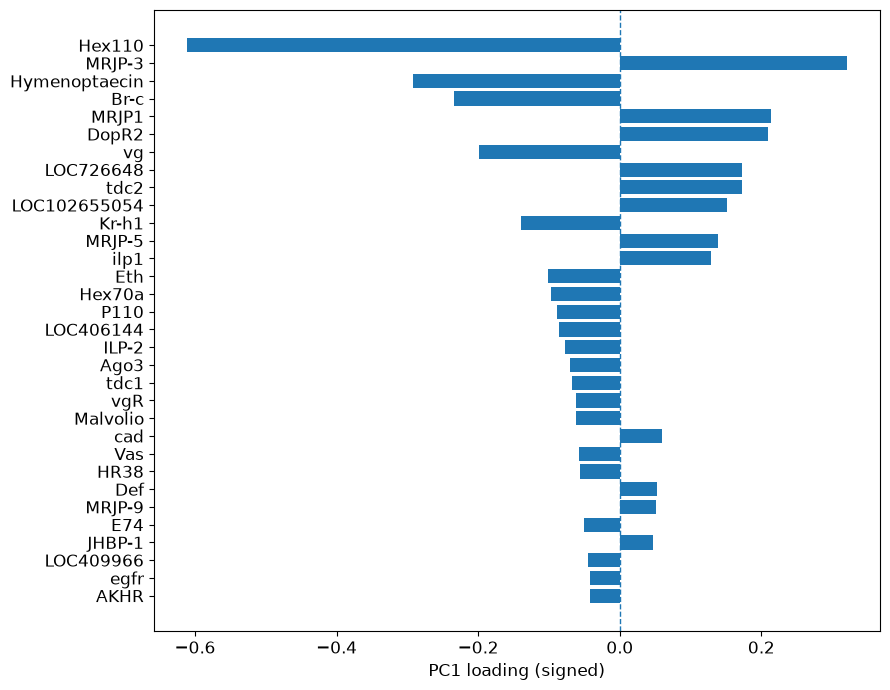

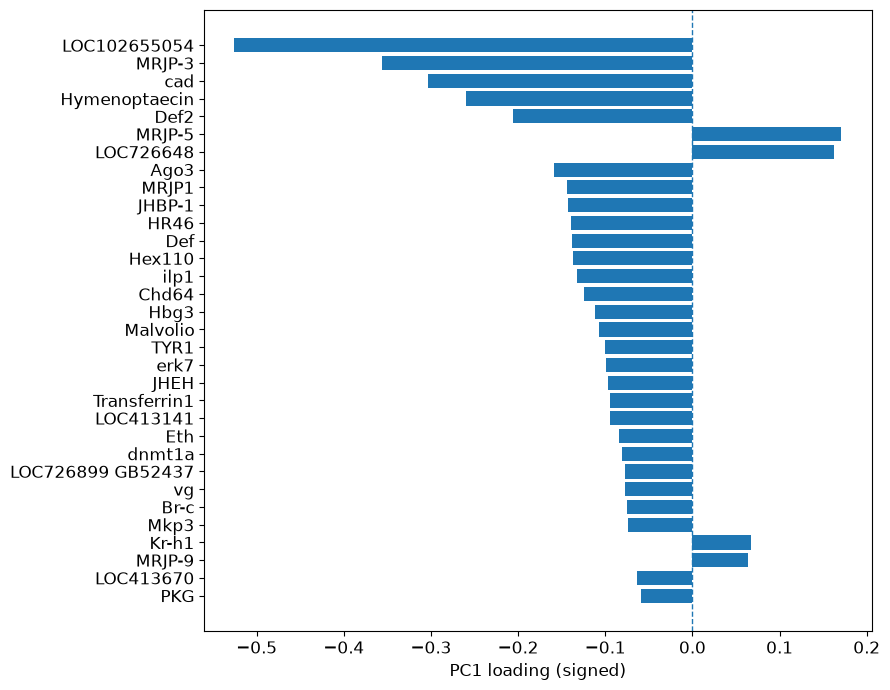

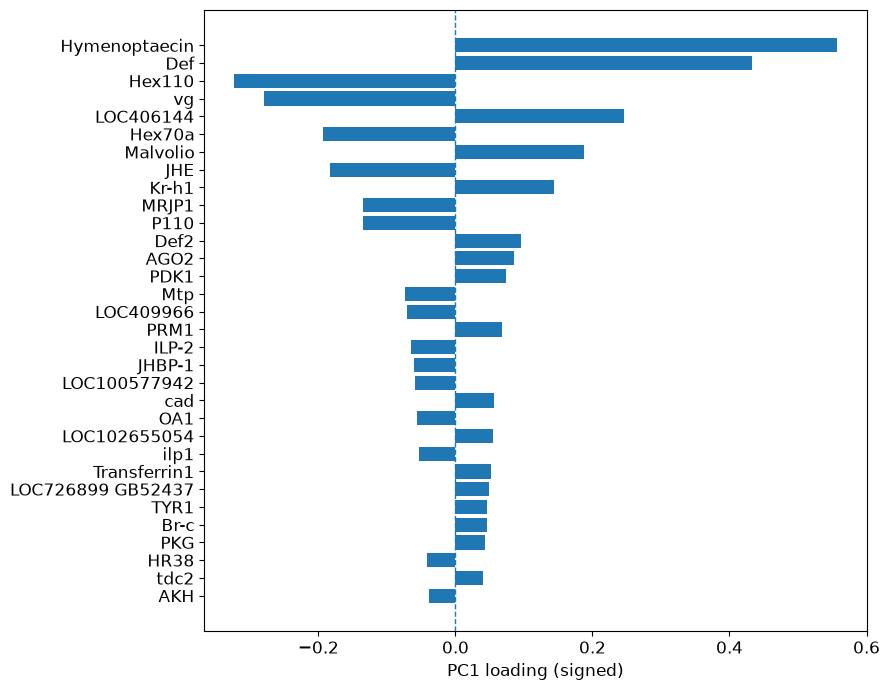

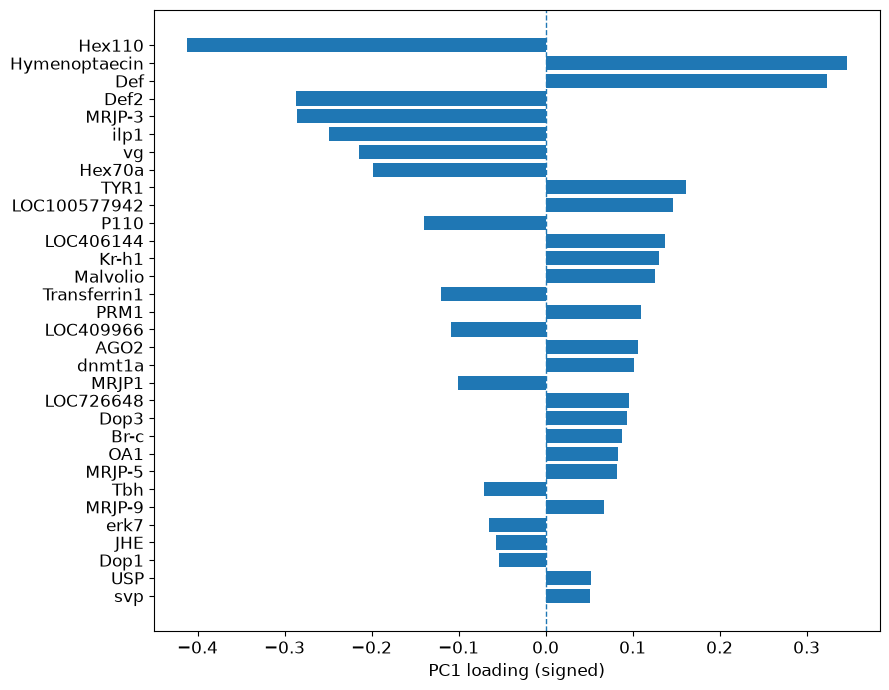

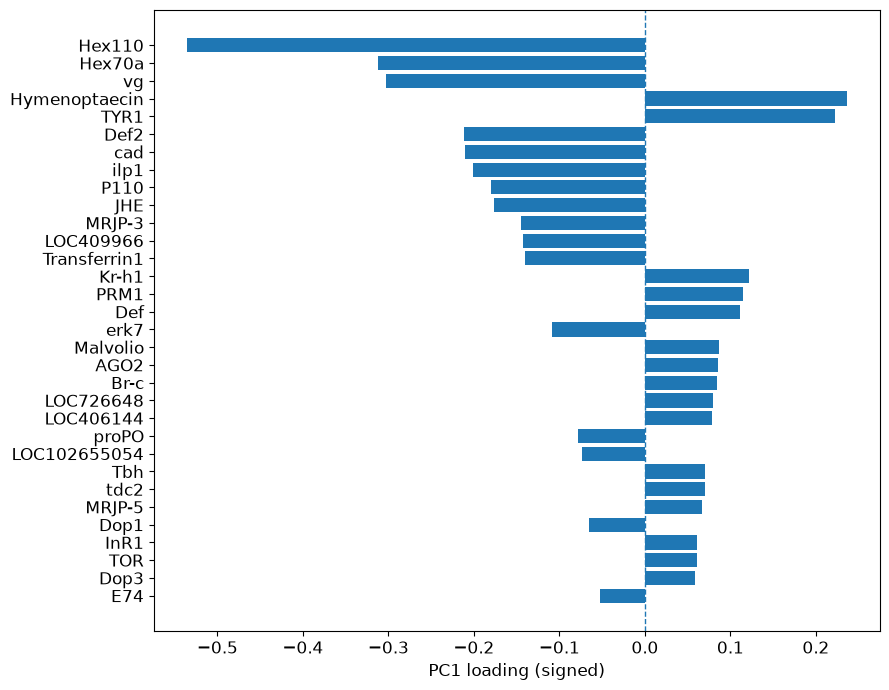

In [23]:
#FIGURE 12

import pandas as pd, numpy as np
import matplotlib.pyplot as plt

FILE_PATH = "Expression_raw_v1.xlsx"
AGE_COL = "Age (Days)"
VG_COL = "Vg protein normalized"

df = pd.read_excel(FILE_PATH)
df.columns = df.columns.str.strip()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
gene_cols = [c for c in numeric_cols if c not in [AGE_COL, VG_COL]]
ages = sorted(df[AGE_COL].dropna().unique().tolist())

def pc1_top20_user_method(df_in, age, gene_cols, age_col=AGE_COL, vg_col=VG_COL):
    """
    Matches user's method:
      - subset by age
      - X = log(expression)
      - center genes across bees
      - covariance on centered data
      - eigendecomposition, take top eigenvector v1
      - scores = Xc @ v1
      - orient so higher scores correspond to lower VG (flip if corr(scores, VG) > 0)
      - return top20 genes by |v1|
    """
    sub = df_in[df_in[age_col] == age].copy()
    X = sub[gene_cols].to_numpy(dtype=float)
    # user's code uses np.log directly
    X = np.log(X)
    X_mean = X.mean(axis=0, keepdims=True)
    Xc = X - X_mean
    S = np.cov(Xc, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(S)  # ascending
    idx = int(np.argmax(eigvals))
    lam1 = float(eigvals[idx])
    v1 = eigvecs[:, idx]
    scores = Xc @ v1

    # Orient so higher scores correspond to lower VG protein
    if vg_col in sub.columns:
        vg_vals = sub[vg_col].to_numpy(dtype=float)
        corr = np.corrcoef(scores, vg_vals)[0, 1]
        if np.isfinite(corr) and corr > 0:
            scores = -scores
            v1 = -v1

    # variance explained
    var_explained = lam1 / float(np.sum(eigvals))

    load_df = pd.DataFrame({"Gene": gene_cols, "PC1_loading": v1})
    load_df["abs_loading"] = load_df["PC1_loading"].abs()
    load_df["loading_sq"] = load_df["PC1_loading"]**2

    top20 = load_df.sort_values("abs_loading", ascending=False).head(32).copy()
    top20_plot = top20.sort_values("abs_loading", ascending=True).reset_index(drop=True)

    return {
        "sub": sub.assign(PC1_score=scores),
        "v1": v1,
        "lam1": lam1,
        "var_explained": var_explained,
        "load_df": load_df,
        "top20": top20.reset_index(drop=True),
        "top20_plot": top20_plot,
    }

# Run for each day
per_day = {}
summary = []
rows = []
for age in ages:
    out = pc1_top20_user_method(df, age, gene_cols)
    per_day[age] = out
    t = out["top20"].copy()
    t.insert(0, "Rank", np.arange(1, len(t)+1))
    t.insert(0, "Day", age)
    rows.append(t)
    summary.append({
        "Day": age,
        "PC1_var_explained": out["var_explained"],
        "Top20_directional_mass": float(out["top20"]["loading_sq"].sum())
    })

all_top = pd.concat(rows, ignore_index=True)
all_top_disp = all_top.copy()
for c in ["PC1_loading", "abs_loading", "loading_sq"]:
    all_top_disp[c] = all_top_disp[c].map(lambda x: float(np.round(x, 6)))

sum_df = pd.DataFrame(summary).sort_values("Day")
sum_df_disp = sum_df.copy()
for c in ["PC1_var_explained","Top20_directional_mass"]:
    sum_df_disp[c] = sum_df_disp[c].map(lambda x: float(np.round(x, 4)))

# Day-specific bar charts (user method)
for age in ages:
    t = per_day[age]["top20_plot"]
    var_expl = per_day[age]["var_explained"]
    plt.figure(figsize=(9, 7))
    y = np.arange(len(t))
    plt.barh(y, t["PC1_loading"].values)
    plt.xticks(fontsize=12)
    plt.yticks(y, t["Gene"].values, fontsize=12)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel("PC1 loading (signed)", fontsize=12)
    #plt.title(f"Day {age}: Top genes by |PC1 loading|")
    plt.tight_layout()
    plt.show()







Using normalized Vg column: Vg protein normalized
Number of numeric gene columns: 90

Using consensus modules from consensus_clusters_day15_K4.csv:
  M1 (pro-Vg) gene count:  13
  M2 (anti-Vg) gene count: 14
  Total genes for embedding:        27

Day-15 Spearman ρ with VG protein for retained genes:
  M1 (pro-Vg):
    cad                    r= 0.7808  p=0.0003574
    MRJP-3                 r= 0.7085  p=0.002126
    vg                     r= 0.7059  p=0.002246
    Def2                   r= 0.6889  p=0.003162
    ilp1                   r= 0.6785  p=0.003861
    Hex110                 r= 0.6706  p=0.004467
    P110                   r= 0.6676  p=0.004712
    Hex70a                 r= 0.6647  p=0.004967
    Transferrin1           r= 0.6588  p=0.005511
    LOC409966              r= 0.6471  p=0.006742
    JHE                    r= 0.6000  p=0.01401
    E74                    r= 0.5912  p=0.01588
    tdc1                   r= 0.5482  p=0.0279
  M2 (anti-Vg):
    Def                    r=-0.

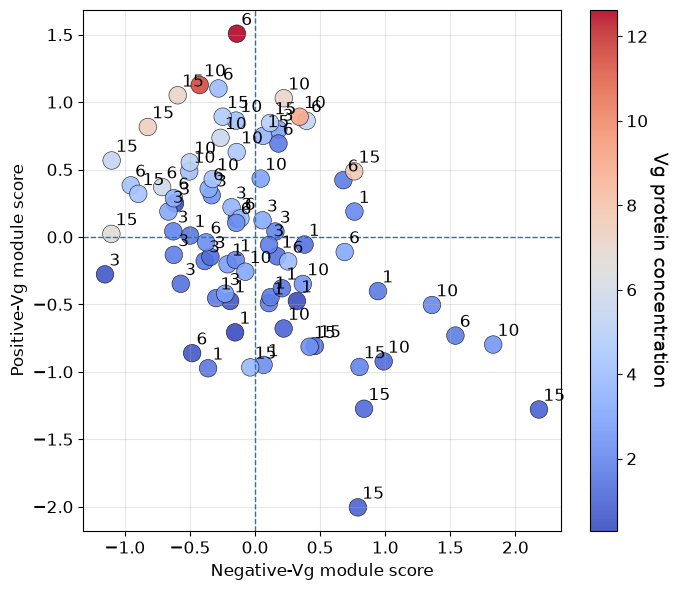

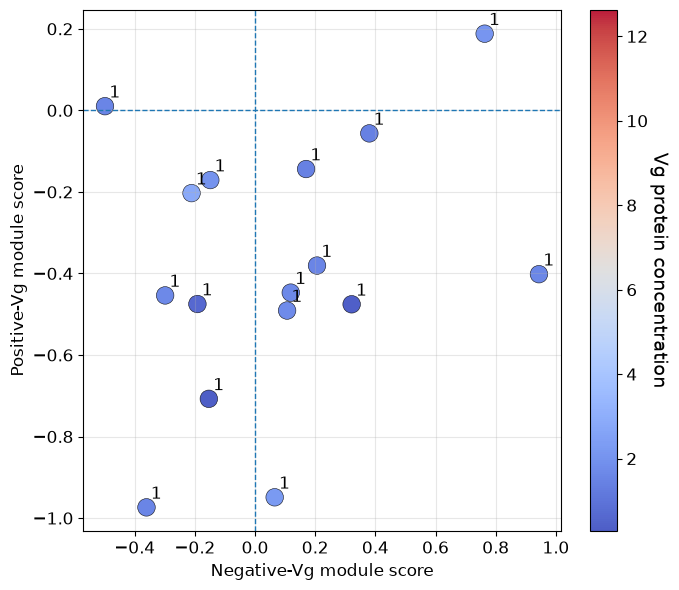

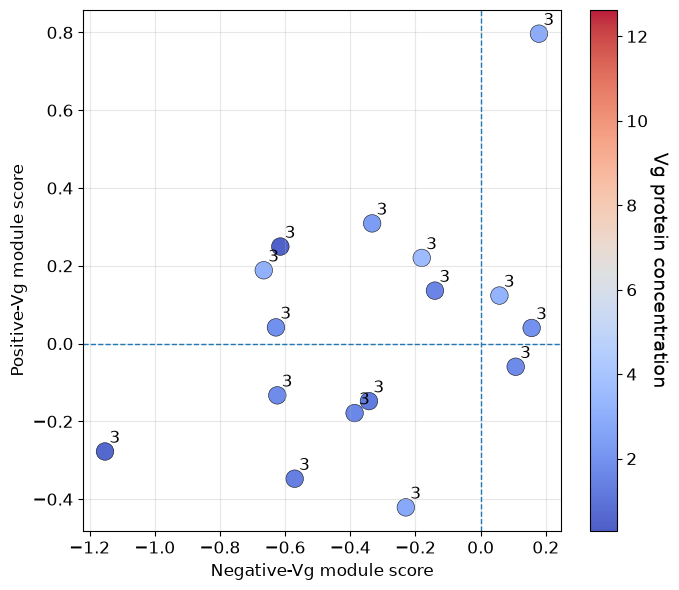

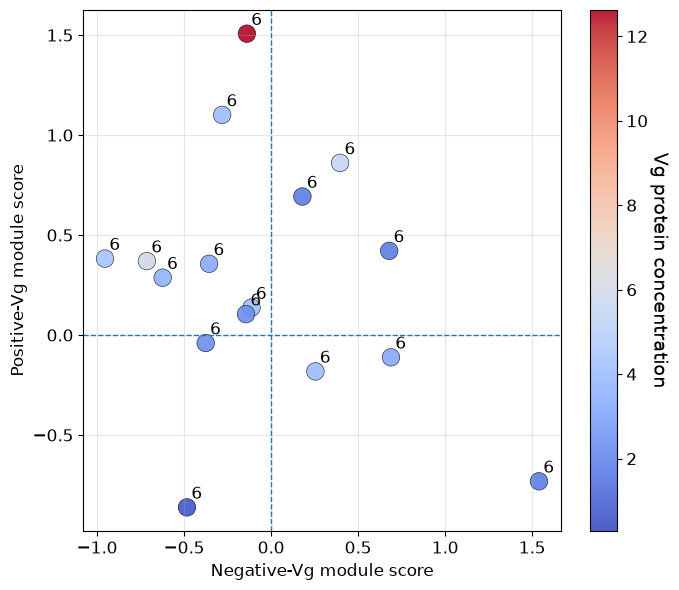

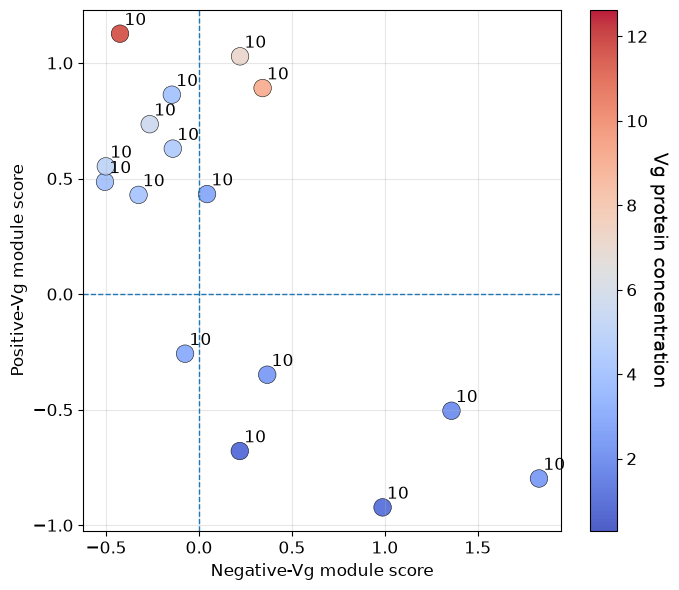

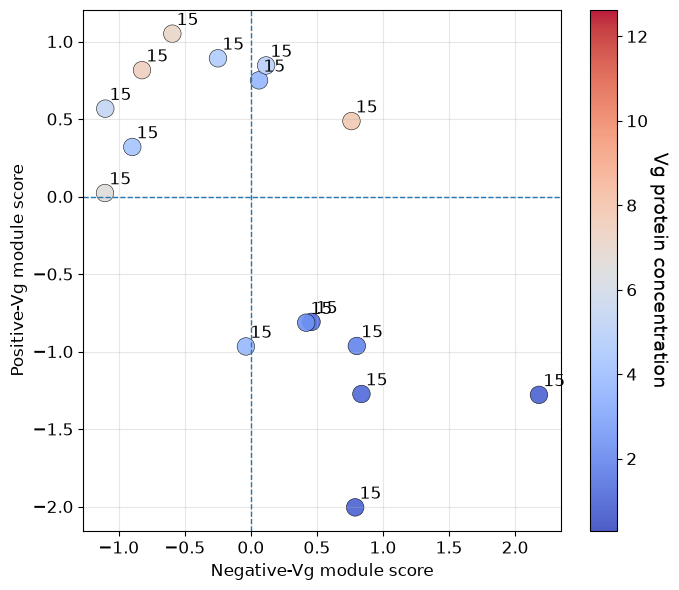

In [24]:
#FIGURE 13-14 - M1 / M2 modules variant

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.ticker import MaxNLocator


# ============================================================
# CONFIG
# ============================================================
FILE_PATH = "Expression_raw_v1.xlsx"
MEMBERSHIP_CSV = "consensus_clusters_day15_K4.csv"

AGE_COL = "Age (Days)"
PROTEIN_SUBSTR = "Vg protein"
SELECTION_DAY = 15
DAYS = [1, 3, 6, 10, 15]

# Module labels in MEMBERSHIP_CSV (M1 = pro-Vg, M2 = anti-Vg by construction
# of the consensus pipeline)
POS_MODULE = "M1"     # pro-Vg / "Vg" module
NEG_MODULE = "M2"     # anti-Vg module

# Expression preprocessing
LOG_TRANSFORM = True   # True -> log1p(expression) before z-scoring

# Embeddings to compute
RUN_PCA = False
RUN_MDS = False
RUN_UMAP = True         # requires: pip install umap-learn

# Plot options
PLOT_ALL_HEATMAP = False
PLOT_SEPARATE_HEATMAPS = False
PLOT_ALL_EMBEDDINGS = True
PLOT_SEPARATE_EMBEDDINGS = True

# For separate day embeddings:
# "global_subset"      -> embed all bees once, then show each day as a subset
# "recompute_each_day" -> recompute embedding independently within each day
SEPARATE_MODE = "global_subset"

# Labeling
SHOW_POINT_LABELS = True
LABEL_CONTENT = "day"   # "day", "index", or "none"
LABEL_STYLE = "offset"  # "offset" or "inside"

# Aesthetics
POINT_SIZE = 160
POINT_ALPHA = 0.9
RANDOM_STATE = 7
HEATMAP_ROW_SORT = "day_then_score"  # "score" or "day_then_score"

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_excel(FILE_PATH)
df.columns = df.columns.str.strip()

# Identify normalized Vg protein column
vg_candidates = [c for c in df.columns if PROTEIN_SUBSTR in str(c)]
if len(vg_candidates) == 0:
    raise ValueError(f"No column containing '{PROTEIN_SUBSTR}' found.")

normalized_candidates = [c for c in vg_candidates if "normalized" in str(c).lower()]
protein_col = normalized_candidates[0] if len(normalized_candidates) > 0 else vg_candidates[0]

# Numeric gene columns only
gene_cols = [
    c for c in df.columns
    if c not in [AGE_COL, protein_col] and pd.api.types.is_numeric_dtype(df[c])
]

if AGE_COL not in df.columns:
    raise ValueError(f"Column '{AGE_COL}' not found.")
if protein_col not in df.columns:
    raise ValueError(f"Normalized Vg column not found.")

print(f"\nUsing normalized Vg column: {protein_col}")
print(f"Number of numeric gene columns: {len(gene_cols)}")

# ============================================================
# HELPERS
# ============================================================
def safe_spearman(x, y):
    """Spearman correlation after pairwise NaN filtering and variance checks."""
    x = pd.to_numeric(pd.Series(x), errors="coerce")
    y = pd.to_numeric(pd.Series(y), errors="coerce")
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.nan, np.nan
    if np.std(x) <= 1e-12 or np.std(y) <= 1e-12:
        return np.nan, np.nan

    r, p = spearmanr(x, y)
    return r, p

def add_labels(ax, coords, labels, style="offset"):
    if len(coords) == 0:
        return

    xs = coords[:, 0]
    ys = coords[:, 1]
    xspan = xs.max() - xs.min() if len(xs) > 1 else 1.0
    yspan = ys.max() - ys.min() if len(ys) > 1 else 1.0
    dx = 0.01 * xspan
    dy = 0.01 * yspan

    for (x, y, lab) in zip(xs, ys, labels):
        if style == "inside":
            ax.text(
                x, y, str(lab),
                ha="center", va="center",
                fontsize=12, color="white", fontweight="bold"
            )
        else:
            ax.text(
                x + dx, y + dy, str(lab),
                ha="left", va="bottom",
                fontsize=12, color="black"
            )

def compute_embedding(X, method="umap", random_state=0):
    method = method.lower()
    n = X.shape[0]

    if method == "pca":
        reducer = PCA(n_components=2, random_state=random_state)
        coords = reducer.fit_transform(X)
        axis_labels = ("PC1", "PC2")

    elif method == "mds":
        reducer = MDS(
            n_components=2,
            random_state=random_state,
            normalized_stress="auto",
            n_init=4        )
        coords = reducer.fit_transform(X)
        axis_labels = ("MDS1", "MDS2")

    elif method == "umap":
        try:
            import umap
        except ImportError as e:
            raise ImportError(
                "UMAP requires 'umap-learn'. Install with: pip install umap-learn"
            ) from e

        n_neighbors = max(2, min(10, n - 1))
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            random_state=random_state
        )
        coords = reducer.fit_transform(X)
        axis_labels = ("UMAP1", "UMAP2")

    else:
        raise ValueError("method must be one of: 'pca', 'mds', 'umap'")

    return coords, axis_labels

def scatter_panel(ax, coords, values, labels, title, axis_labels, norm, cmap="coolwarm"):
    sc = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=values,
        cmap=cmap,
        norm=norm,
        s=POINT_SIZE,
        alpha=POINT_ALPHA,
        edgecolors="black",
        linewidths=0.4
    )

    if SHOW_POINT_LABELS and LABEL_CONTENT != "none":
        add_labels(ax, coords, labels, style=LABEL_STYLE)

    ax.set_title(title)
    ax.set_xlabel(axis_labels[0], fontsize=12)
    ax.set_ylabel(axis_labels[1], fontsize=12)
    ax.grid(True, alpha=0.3)
    if RUN_UMAP and have_umap:
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    return sc

def get_labels_for_plot(sub_df):
    if LABEL_CONTENT == "day":
        return sub_df[AGE_COL].astype(int).values
    elif LABEL_CONTENT == "index":
        return sub_df.index.astype(str).values
    else:
        return np.array([""] * len(sub_df))

# ============================================================
# STEP 1: GET POS / NEG GENES FROM CONSENSUS MODULES (M1 / M2)
# ============================================================
mem = pd.read_csv(MEMBERSHIP_CSV)

# Drop the VG-protein feature itself if it appears in the membership file
VG_FEATURE = protein_col   # exact column name in expression file
mem_genes = mem[mem["feature"] != VG_FEATURE].copy()

pos_genes = mem_genes[mem_genes["module"] == POS_MODULE]["feature"].tolist()
neg_genes = mem_genes[mem_genes["module"] == NEG_MODULE]["feature"].tolist()

# Restrict to genes present in the expression matrix and with finite variance
pos_genes = [g for g in pos_genes if g in gene_cols]
neg_genes = [g for g in neg_genes if g in gene_cols]

top_genes = pos_genes + neg_genes
TOP_N = len(top_genes)

print(f"\nUsing consensus modules from {MEMBERSHIP_CSV}:")
print(f"  {POS_MODULE} (pro-Vg) gene count:  {len(pos_genes)}")
print(f"  {NEG_MODULE} (anti-Vg) gene count: {len(neg_genes)}")
print(f"  Total genes for embedding:        {TOP_N}")

# Sanity: report Day-15 Spearman with VG for each retained gene
day_sel = df[df[AGE_COL] == SELECTION_DAY].copy()
print(f"\nDay-{SELECTION_DAY} Spearman ρ with VG protein for retained genes:")
print(f"  {POS_MODULE} (pro-Vg):")
for g in pos_genes:
    r, p = safe_spearman(day_sel[g], day_sel[protein_col])
    print(f"    {g:22s} r={r: .4f}  p={p:.4g}")
print(f"  {NEG_MODULE} (anti-Vg):")
for g in neg_genes:
    r, p = safe_spearman(day_sel[g], day_sel[protein_col])
    print(f"    {g:22s} r={r: .4f}  p={p:.4g}")

# ============================================================
# STEP 2: BUILD ALL-BEE EXPRESSION MATRIX FOR THOSE GENES
# ============================================================
plot_df = df[[AGE_COL, protein_col] + top_genes].copy()
plot_df = plot_df.dropna(subset=[AGE_COL, protein_col]).reset_index(drop=True)

X = plot_df[top_genes].apply(pd.to_numeric, errors="coerce")

if LOG_TRANSFORM:
    # Treat negative values as missing before log1p
    X = X.mask(X < 0, np.nan)
    X = np.log1p(X)

imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)

scaler = StandardScaler()
X_z = scaler.fit_transform(X_imp)

expr_z = pd.DataFrame(X_z, columns=top_genes, index=plot_df.index)

# ============================================================
# STEP 3: COMPUTE MODULE SCORES
# ============================================================
plot_df["pos_module_score"] = expr_z[pos_genes].mean(axis=1)
plot_df["neg_module_score"] = expr_z[neg_genes].mean(axis=1)

# High signed score = positive-Vg genes high and negative-Vg genes low
plot_df["signed_module_score"] = plot_df["pos_module_score"] - plot_df["neg_module_score"]

# Magnitude, if needed
plot_df["module_magnitude"] = np.abs(plot_df["pos_module_score"]) + np.abs(plot_df["neg_module_score"])

days_all = plot_df[AGE_COL].astype(int).values
labels_all = get_labels_for_plot(plot_df)

# Diverging norm centered at 0 for signed score
score_norm = TwoSlopeNorm(
    vmin=np.nanmin(plot_df["signed_module_score"].values),
    vcenter=0,
    vmax=np.nanmax(plot_df["signed_module_score"].values)
)

# ============================================================
# STEP 4: HEATMAP OF ALL BEES
# ============================================================
if PLOT_ALL_HEATMAP:
    if HEATMAP_ROW_SORT == "score":
        row_order = plot_df["signed_module_score"].sort_values(ascending=False).index
    else:
        row_order = plot_df.sort_values(
            by=[AGE_COL, "signed_module_score"],
            ascending=[True, False]
        ).index

    heatmap_expr = expr_z.loc[row_order, top_genes].values
    days_sorted = plot_df.loc[row_order, AGE_COL].astype(int).values

    heat_norm = TwoSlopeNorm(
        vmin=np.nanmin(heatmap_expr),
        vcenter=0,
        vmax=np.nanmax(heatmap_expr)
    )

    fig, ax = plt.subplots(figsize=(14, 10))
    im = ax.imshow(heatmap_expr, aspect="auto", cmap="coolwarm", norm=heat_norm)

    # divider between positive and negative modules
    ax.axvline(len(pos_genes) - 0.5, color="black", linewidth=2)

    if HEATMAP_ROW_SORT == "day_then_score":
        for i in range(1, len(days_sorted)):
            if days_sorted[i] != days_sorted[i - 1]:
                ax.axhline(i - 0.5, color="black", linewidth=1.5)

    ax.set_xticks(np.arange(len(top_genes)))
    ax.set_xticklabels(top_genes, rotation=90)
    ax.set_yticks(np.arange(len(days_sorted)))
    ax.set_yticklabels(days_sorted)

    ax.set_xlabel(f"{POS_MODULE} (pro-Vg) genes first, {NEG_MODULE} (anti-Vg) genes second")
    ax.set_ylabel("Bee (label = day)")
    ax.set_title(
        "All bees: normalized expression heatmap\n"
        f"Columns split by consensus module ({POS_MODULE} | {NEG_MODULE})"
        + (" | log1p(expression) before z-scoring" if LOG_TRANSFORM else "")
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Normalized expression (z-score)")

    ax.text(
        len(pos_genes)/2 - 0.5, -2.5, f"{POS_MODULE} (pro-Vg)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )
    ax.text(
        len(pos_genes) + len(neg_genes)/2 - 0.5, -2.5, f"{NEG_MODULE} (anti-Vg)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# STEP 5: SEPARATE HEATMAP FOR EACH DAY
# ============================================================
if PLOT_SEPARATE_HEATMAPS:
    days_unique = sorted(plot_df[AGE_COL].dropna().astype(int).unique())
    heat_norm = TwoSlopeNorm(
        vmin=np.nanmin(expr_z[top_genes].values),
        vcenter=0,
        vmax=np.nanmax(expr_z[top_genes].values)
    )

    fig, axes = plt.subplots(len(days_unique), 1, figsize=(14, 3 * len(days_unique)))
    if len(days_unique) == 1:
        axes = [axes]

    for ax, day in zip(axes, days_unique):
        idx = plot_df.index[plot_df[AGE_COL].astype(int) == day]
        idx = plot_df.loc[idx, "signed_module_score"].sort_values(ascending=False).index

        mat = expr_z.loc[idx, top_genes].values
        im = ax.imshow(mat, aspect="auto", cmap="coolwarm", norm=heat_norm)

        ax.axvline(len(pos_genes) - 0.5, color="black", linewidth=2)

        ax.set_xticks(np.arange(len(top_genes)))
        ax.set_xticklabels(top_genes, rotation=90)
        ax.set_yticks(np.arange(len(idx)))
        ax.set_yticklabels([f"{day}" for _ in idx])

        ax.set_title(f"Day {day} | bees sorted by signed module score")
        ax.set_ylabel("Bee")

    axes[-1].set_xlabel(f"{POS_MODULE} (pro-Vg) genes first, {NEG_MODULE} (anti-Vg) genes second")
    cbar = fig.colorbar(im, ax=axes, shrink=0.9)
    cbar.set_label("Normalized expression (z-score)")

    plt.tight_layout()
    plt.show()

# ============================================================
# STEP 6: GLOBAL EMBEDDINGS FOR ALL BEES
# ============================================================
X_embed = expr_z[top_genes].values

coords_global = {}
axis_global = {}

if RUN_PCA:
    coords_global["pca"], axis_global["pca"] = compute_embedding(X_embed, method="pca", random_state=RANDOM_STATE)

if RUN_MDS:
    coords_global["mds"], axis_global["mds"] = compute_embedding(X_embed, method="mds", random_state=RANDOM_STATE)

have_umap = False
if RUN_UMAP:
    try:
        coords_global["umap"], axis_global["umap"] = compute_embedding(X_embed, method="umap", random_state=RANDOM_STATE)
        have_umap = True
    except ImportError as e:
        print(f"\n{e}")
        print("Skipping UMAP.")
        have_umap = False

# ============================================================
# STEP 7: ALL-BEE EMBEDDINGS COLORED BY SIGNED MODULE SCORE
# ============================================================
if PLOT_ALL_EMBEDDINGS:
    methods_to_plot = []
    if RUN_PCA:
        methods_to_plot.append("pca")
    if RUN_MDS:
        methods_to_plot.append("mds")
    if RUN_UMAP and have_umap:
        methods_to_plot.append("umap")

    if len(methods_to_plot) > 0:
        fig, axes = plt.subplots(1, len(methods_to_plot), figsize=(7 * len(methods_to_plot), 6))
        if len(methods_to_plot) == 1:
            axes = [axes]

        last_sc = None
        for ax, method in zip(axes, methods_to_plot):
            title = ""
            last_sc = scatter_panel(
                ax=ax,
                coords=coords_global[method],
                values=plot_df["signed_module_score"].values,
                labels=labels_all,
                title=title,
                axis_labels=axis_global[method],
                norm=score_norm,
                cmap="coolwarm"
            )

        cbar = fig.colorbar(last_sc, ax=ax, shrink=0.95)
        cbar.set_label("Signed module score", rotation=270, labelpad=15)
        plt.tight_layout()
        plt.show()

# ============================================================
# STEP 8: SEPARATE EMBEDDINGS FOR EACH DAY
# One figure per day per method
# ============================================================
if PLOT_SEPARATE_EMBEDDINGS:
    methods_to_plot = []
    if RUN_PCA:
        methods_to_plot.append("pca")
    if RUN_MDS:
        methods_to_plot.append("mds")
    if RUN_UMAP and have_umap:
        methods_to_plot.append("umap")

    days_unique = sorted(plot_df[AGE_COL].dropna().astype(int).unique())

    for method in methods_to_plot:
        for day in days_unique:
            mask = plot_df[AGE_COL].astype(int) == day
            idx = plot_df.index[mask]
            sub_df = plot_df.loc[idx].copy()

            if len(sub_df) < 2:
                print(f"Skipping {method.upper()} Day {day}: not enough bees.")
                continue

            if SEPARATE_MODE == "global_subset":
                coords_day = coords_global[method][mask.values]
                axis_labels_day = axis_global[method]
                #title = f"Day {day} ({method.upper()})"

            elif SEPARATE_MODE == "recompute_each_day":
                X_day = expr_z.loc[idx, top_genes].values
                coords_day, axis_labels_day = compute_embedding(
                    X_day, method=method, random_state=RANDOM_STATE
                )
                #title = f"Day {day} ({method.upper()} recomputed)"

            else:
                raise ValueError("SEPARATE_MODE must be 'global_subset' or 'recompute_each_day'")

            labels_day = get_labels_for_plot(sub_df)

            fig, ax = plt.subplots(figsize=(7, 6))

            sc = scatter_panel(
                ax=ax,
                coords=coords_day,
                values=sub_df["signed_module_score"].values,
                labels=labels_day,
                title="",
                #title=title,
                axis_labels=axis_labels_day,
                norm=score_norm,
                cmap="coolwarm"
            )

            cbar = fig.colorbar(sc, ax=ax)
            cbar.set_label("Signed module score", rotation=270, labelpad=15)

            plt.tight_layout()
            plt.show()

            # Optional: save each figure
            # fig.savefig(f"{method}_day_{day}.png", dpi=300, bbox_inches="tight")
            # plt.close(fig)
# ============================================================
# STEP 9: POSITIVE VS NEGATIVE MODULE SCATTER
# ============================================================
vg_norm = Normalize(
    vmin=np.nanmin(plot_df[protein_col].values),
    vmax=np.nanmax(plot_df[protein_col].values)
)


fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(
    plot_df["neg_module_score"],
    plot_df["pos_module_score"],
#    c=plot_df["signed_module_score"],
    c=plot_df[protein_col],
#    cmap="coolwarm",
    cmap="coolwarm",
#    norm=score_norm,
    norm=vg_norm,
    s=POINT_SIZE,
    alpha=POINT_ALPHA,
    edgecolors="black",
    linewidths=0.4
)

if SHOW_POINT_LABELS and LABEL_CONTENT != "none":
    add_labels(
        ax,
        np.column_stack([plot_df["neg_module_score"].values, plot_df["pos_module_score"].values]),
        labels_all,
        style="offset"
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Negative-Vg module score", fontsize=12)
ax.set_ylabel("Positive-Vg module score", fontsize=12)
#ax.set_title("Per-bee positive vs negative Vg-associated module expression")
cbar = plt.colorbar(sc, ax=ax)
#cbar.set_label("Signed module score")
cbar.set_label("Vg protein concentration", rotation=270, labelpad=15)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# STEP 9B: POSITIVE VS NEGATIVE MODULE SCATTER FOR EACH DAY
# One separate figure per day
# Colored by normalized Vg protein instead of signed module score
# ============================================================
days_unique = sorted(plot_df[AGE_COL].dropna().astype(int).unique())


for day in days_unique:
    sub_df = plot_df[plot_df[AGE_COL].astype(int) == day].copy()

    if len(sub_df) < 2:
        print(f"Skipping Day {day}: not enough bees.")
        continue

    if LABEL_CONTENT == "day":
        labels_day = sub_df[AGE_COL].astype(int).values
    elif LABEL_CONTENT == "index":
        labels_day = sub_df.index.astype(str).values
    else:
        labels_day = np.array([""] * len(sub_df))

    fig, ax = plt.subplots(figsize=(7, 6))

    coords_day = np.column_stack([
        sub_df["neg_module_score"].values,
        sub_df["pos_module_score"].values
    ])

    sc = ax.scatter(
        sub_df["neg_module_score"],
        sub_df["pos_module_score"],
        c=sub_df[protein_col],
        cmap="coolwarm",
        norm=vg_norm,
        s=POINT_SIZE,
        alpha=POINT_ALPHA,
        edgecolors="black",
        linewidths=0.4
    )

    if SHOW_POINT_LABELS and LABEL_CONTENT != "none":
        add_labels(ax, coords_day, labels_day, style=LABEL_STYLE)

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_xlabel("Negative-Vg module score", fontsize=12)
    ax.set_ylabel("Positive-Vg module score", fontsize=12)
    #ax.set_title(f"Day {day}")
    ax.grid(True, alpha=0.3)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Vg protein concentration", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

=== Rank-Based Normalization LDA Results ===

Knockdown Control: n=37, mean LDA = -0.776 ± 1.100
Knockdown TYR1 KD: n=26, mean LDA = 1.104 ± 0.791
Expression data: n=80, mean LDA = 0.006 ± 1.519

Age-LDA correlation: ρ = -0.632, p = 3.25e-10


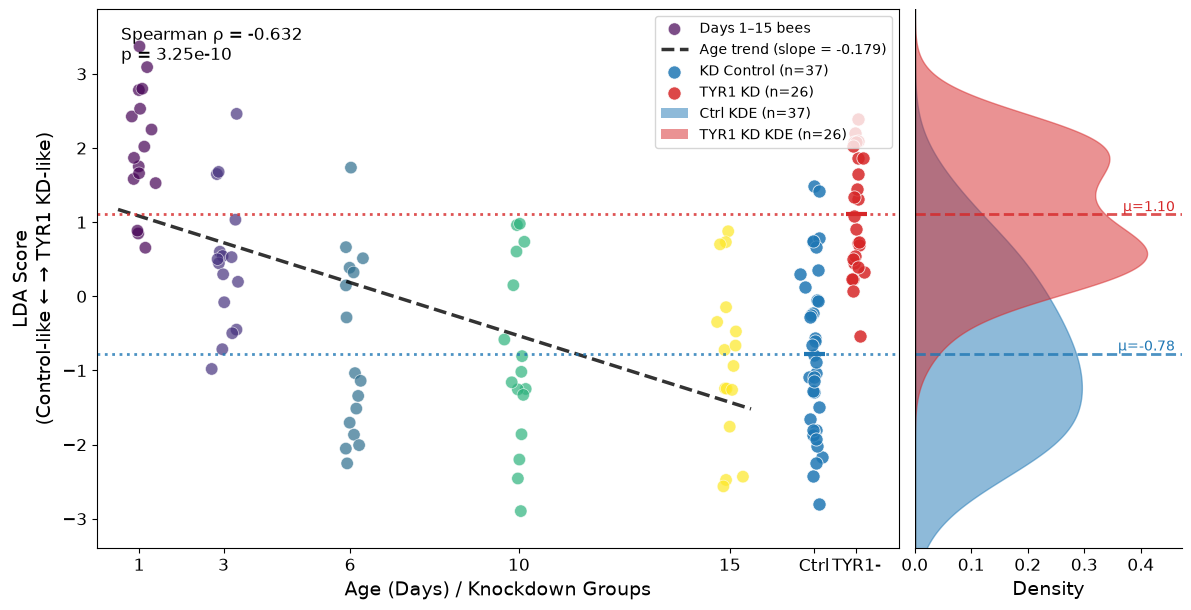

In [25]:
#Figure 15

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, spearmanr
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.stats import rankdata
import warnings
warnings.filterwarnings('ignore')

palette = plt.get_cmap('tab10').colors
control_color, knockdown_color = palette[0], palette[3]


# Reload data
expr_df = pd.read_excel('Expression_raw_v1.xlsx')
kd_df = pd.read_excel('Knockdown Combined Rounds_no outliers.xlsx')

# Gene mapping
gene_mapping = {
    'TYR1 RQ': ('TYR1', 'TYR1'),
    'Vg RQ': ('vg', 'vg'),
    'JHE RQ': ('JHE', 'JHE'),
    'Kr-h1 RQ': ('Kr-h1', 'Kr-h1'),
    'HR46 RQ': ('HR46', 'HR46'),
    'Ftz RQ': ('Ftz-f1', 'Ftz-f1'),
    'Ilp1 RQ': ('ilp1', 'ilp1'),
    'InR1 RQ': ('InR1', 'InR1'),
    'Ilp2 RQ': ('ILP-2', 'ILP-2'),
    'InR2 RQ': ('InR2', 'InR2'),
    'AKH RQ': ('AKH', 'AKH'),
    'AKHR RQ': ('AKHR', 'AKHR'),
}

overlapping_genes = [v[1] for v in gene_mapping.values()]

# Prepare raw data
kd_raw = pd.DataFrame()
for kd_col, (expr_col, std_name) in gene_mapping.items():
    kd_raw[std_name] = kd_df[kd_col]
kd_raw['treatment'] = kd_df['treatment']

expr_raw = pd.DataFrame()
for kd_col, (expr_col, std_name) in gene_mapping.items():
    expr_raw[std_name] = expr_df[expr_col]
expr_raw['Age'] = expr_df['Age (Days)']

# Remove samples with missing Kr-h1
kd_raw = kd_raw.dropna(subset=['Kr-h1'])

# Apply rank-based normalization
def rank_normalize(df, genes):
    """Rank-based normalization: convert to percentile ranks (0-1) within each dataset"""
    result = pd.DataFrame(index=df.index)
    for gene in genes:
        result[gene] = rankdata(df[gene]) / len(df)
    return result

kd_rank = rank_normalize(kd_raw, overlapping_genes)
kd_rank['treatment'] = kd_raw['treatment'].values

expr_rank = rank_normalize(expr_raw, overlapping_genes)
expr_rank['Age'] = expr_raw['Age'].values

# Fit LDA
X_kd = kd_rank[overlapping_genes].values
y_kd = (kd_rank['treatment'] == 'TYR-').astype(int).values
X_expr = expr_rank[overlapping_genes].values

lda = LinearDiscriminantAnalysis(n_components=1)
lda.fit(X_kd, y_kd)

# Project both datasets
kd_lda = lda.transform(X_kd).flatten()
expr_lda = lda.transform(X_expr).flatten()

# Add scores to dataframes
kd_rank['LDA_score'] = kd_lda
expr_rank['LDA_score'] = expr_lda

# Get group scores
control_scores = kd_lda[y_kd == 0]
knockdown_scores = kd_lda[y_kd == 1]

print("=== Rank-Based Normalization LDA Results ===\n")
print(f"Knockdown Control: n={len(control_scores)}, mean LDA = {control_scores.mean():.3f} ± {control_scores.std():.3f}")
print(f"Knockdown TYR1 KD: n={len(knockdown_scores)}, mean LDA = {knockdown_scores.mean():.3f} ± {knockdown_scores.std():.3f}")
print(f"Expression data: n={len(expr_lda)}, mean LDA = {expr_lda.mean():.3f} ± {expr_lda.std():.3f}")

r, p = spearmanr(expr_rank['Age'], expr_lda)
print(f"\nAge-LDA correlation: ρ = {r:.3f}, p = {p:.2e}")



# ============================================================
# Combined figure: LDA score vs Age + rotated KDE on the right
# ============================================================

from matplotlib.patches import Patch

# Use a different name here so we don't overwrite X_expr from above
ages = expr_rank['Age'].values
x_expr_jitter = ages + np.random.normal(0, 0.15, len(ages))

# Fixed x-positions for knockdown groups
x_ctrl = 17.0
x_kd = 18.0

x_ctrl_jitter = x_ctrl + np.random.normal(0, 0.08, len(control_scores))
x_kd_jitter = x_kd + np.random.normal(0, 0.08, len(knockdown_scores))

# Shared y-range across all scores
all_scores = np.concatenate([expr_lda, control_scores, knockdown_scores])
ymin, ymax = all_scores.min(), all_scores.max()
ypad = 0.08 * (ymax - ymin if ymax > ymin else 1.0)
ymin -= ypad
ymax += ypad

# KDE evaluated on the SAME LDA-score axis
y_grid = np.linspace(ymin, ymax, 400)
kde_control = gaussian_kde(control_scores)
kde_kd = gaussian_kde(knockdown_scores)

dens_control = kde_control(y_grid)
dens_kd = kde_kd(y_grid)
max_dens = max(dens_control.max(), dens_kd.max())

# Figure layout
fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(1, 2, width_ratios=[4.8, 1.6], wspace=0.03)

ax = fig.add_subplot(gs[0, 0])
ax_kde = fig.add_subplot(gs[0, 1], sharey=ax)

# ----------------------------
# Left panel: LDA score vs age
# ----------------------------
scatter = ax.scatter(
    x_expr_jitter,
    expr_lda,
    c=ages,
    cmap='viridis',
    s=80,
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5,
    label='Days 1–15 bees'
)

# Trend line for age-series only
z = np.polyfit(ages, expr_lda, 1)
p_line = np.poly1d(z)
ax.plot(
    [0.5, 15.5],
    [p_line(0.5), p_line(15.5)],
    'k--',
    linewidth=2.5,
    alpha=0.8,
    label=f'Age trend (slope = {z[0]:.3f})'
)

# Knockdown groups
ax.scatter(
    x_ctrl_jitter,
    control_scores,
    color=control_color,
    s=90,
    alpha=0.85,
    edgecolors='white',
    linewidth=0.6,
    label=f'KD Control (n={len(control_scores)})'
)

ax.scatter(
    x_kd_jitter,
    knockdown_scores,
    color=knockdown_color,
    s=90,
    alpha=0.85,
    edgecolors='white',
    linewidth=0.6,
    label=f'TYR1 KD (n={len(knockdown_scores)})'
)

# Mean bars for knockdown groups
ax.hlines(
    control_scores.mean(),
    x_ctrl - 0.25,
    x_ctrl + 0.25,
    colors=control_color,
    linestyles='-',
    linewidth=3
)

ax.hlines(
    knockdown_scores.mean(),
    x_kd - 0.25,
    x_kd + 0.25,
    colors=knockdown_color,
    linestyles='-',
    linewidth=3
)

# Reference mean lines across main panel
ax.axhline(
    y=control_scores.mean(),
    color=control_color,
    linestyle=':',
    linewidth=2.0,
    alpha=0.8
)
ax.axhline(
    y=knockdown_scores.mean(),
    color=knockdown_color,
    linestyle=':',
    linewidth=2.0,
    alpha=0.8
)

# Correlation annotation
ax.text(
    0.03, 0.97,
    f'Spearman ρ = {r:.3f}\np = {p:.2e}',
    transform=ax.transAxes,
    fontsize=12,
    va='top'
)

ax.set_xlabel('Age (Days) / Knockdown Groups', fontsize=14)
ax.set_ylabel('LDA Score\n(Control-like ← → TYR1 KD-like)', fontsize=14)
ax.set_xticks([1, 3, 6, 10, 15, x_ctrl, x_kd])
ax.set_xticklabels(['1', '3', '6', '10', '15', 'Ctrl', 'TYR1-'])
ax.set_xlim(0, 19)
ax.set_ylim(ymin, ymax)

# ----------------------------
# Right panel: rotated KDE
# ----------------------------
ax_kde.fill_betweenx(
    y_grid, 0, dens_control,
    color=control_color,
    alpha=0.5
)
ax_kde.fill_betweenx(
    y_grid, 0, dens_kd,
    color=knockdown_color,
    alpha=0.5
)

# Mean lines on the KDE panel (same y-axis, so perfectly aligned)
ax_kde.axhline(
    y=control_scores.mean(),
    color=control_color,
    linestyle='--',
    linewidth=2.0,
    alpha=0.8
)
ax_kde.axhline(
    y=knockdown_scores.mean(),
    color=knockdown_color,
    linestyle='--',
    linewidth=2.0,
    alpha=0.8
)

# Baseline at density = 0
ax_kde.axvline(0, color='black', linewidth=1.0)

# KDE panel formatting
ax_kde.set_xlabel('Density', fontsize=14)
ax_kde.set_xlim(0, max_dens * 1.15)
ax_kde.tick_params(axis='y', left=False, labelleft=False)
ax_kde.spines['top'].set_visible(False)
ax_kde.spines['right'].set_visible(False)
ax_kde.spines['left'].set_visible(False)

# Mean annotations on KDE side
x_text = max_dens * 1.12
ax_kde.text(
    x_text, control_scores.mean(),
    f'μ={control_scores.mean():.2f}',
    color=control_color,
    fontsize=10,
    ha='right',
    va='bottom'
)
ax_kde.text(
    x_text, knockdown_scores.mean(),
    f'μ={knockdown_scores.mean():.2f}',
    color=knockdown_color,
    fontsize=10,
    ha='right',
    va='bottom'
)

# Combined legend
handles, labels = ax.get_legend_handles_labels()
handles += [
    Patch(facecolor=control_color, edgecolor='none', alpha=0.5,
          label=f'Ctrl KDE (n={len(control_scores)})'),
    Patch(facecolor=knockdown_color, edgecolor='none', alpha=0.5,
          label=f'TYR1 KD KDE (n={len(knockdown_scores)})')
]
labels += [
    f'Ctrl KDE (n={len(control_scores)})',
    f'TYR1 KD KDE (n={len(knockdown_scores)})'
]

ax.legend(handles, labels, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

KD: 63 rows  (37 Ctrl, 26 TYR-)
Expression: 80 rows across days [np.int64(1), np.int64(3), np.int64(6), np.int64(10), np.int64(15)]
  bootstrap iter 500/2000
  bootstrap iter 1000/2000
  bootstrap iter 1500/2000
  bootstrap iter 2000/2000

=== Per-group LDA score (point estimate + 95% bootstrap CI) ===
  group   mean  boot_mean  ci_lo  ci_hi
Control -0.776     -0.968 -1.311 -0.701
   TYR-  1.104      1.377  0.998  1.866
  Day 1  2.003      1.840 -0.185  3.752
  Day 3  0.451      0.364 -1.096  1.747
  Day 6 -0.714     -0.628 -1.791  0.491
 Day 10 -0.836     -0.781 -1.806  0.376
 Day 15 -0.872     -0.762 -2.333  0.827

=== Contrasts (Δmeans, 95% CI, two-sided bootstrap p) ===
                  contrast  estimate   ci_lo   ci_hi  p_boot
    Aging (Day 15 − Day 1)   -2.8750 -5.8576  0.7490  0.1190
Knockdown (TYR− − Control)    1.8803  1.6985  3.1766  0.0005
         Day 15 vs Control   -0.0963 -1.3254  1.9341  0.8150
            Day 15 vs TYR−   -1.9766 -3.7718 -0.5941  0.0090
          Da

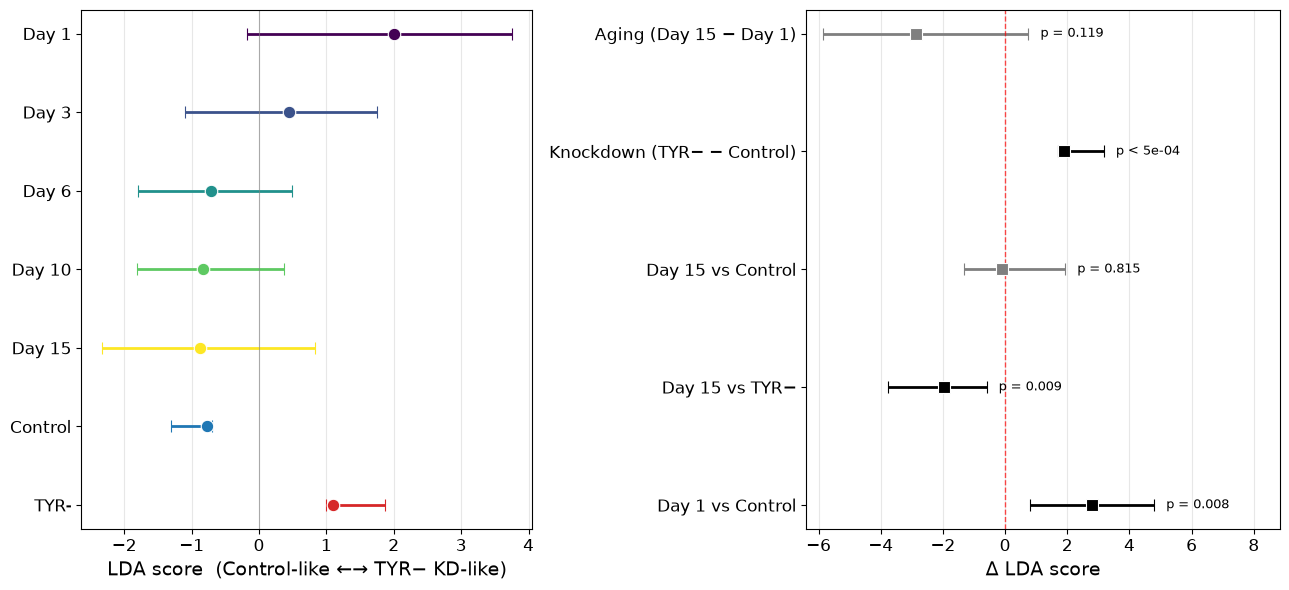

In [26]:
#Statistics for Figure 15

"""
Joint stratified bootstrap for LDA-projected scores.

For each of n_boot iterations:
  1. Resample KD rows stratified by treatment (Control / TYR-).
  2. Resample expression rows stratified by Age (1, 3, 6, 10, 15).
  3. Re-rank-normalize each resampled dataset on its own genes.
  4. Refit LDA on the resampled KD data.
  5. Sign-align the LDA axis so mean(TYR-) > mean(Control)
     (LDA direction is otherwise arbitrary across refits).
  6. Project KD + expression onto the new axis and record per-group means.

This propagates LDA-fit uncertainty into all 7 group CIs uniformly
and lets us form bootstrap CIs / p-values for any contrast.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Config
# ============================================================
EXPR_PATH = 'Expression_raw_v1.xlsx'
KD_PATH   = 'Knockdown Combined Rounds_no outliers.xlsx'  
N_BOOT    = 2000
RNG_SEED  = 0

palette = plt.get_cmap('tab10').colors
control_color, knockdown_color = palette[0], palette[3]

gene_mapping = {
    'TYR1 RQ': 'TYR1',  'Vg RQ': 'vg',   'JHE RQ': 'JHE',     'Kr-h1 RQ': 'Kr-h1',
    'HR46 RQ': 'HR46',  'Ftz RQ': 'Ftz-f1','Ilp1 RQ': 'ilp1', 'InR1 RQ': 'InR1',
    'Ilp2 RQ': 'ILP-2', 'InR2 RQ': 'InR2','AKH RQ': 'AKH',    'AKHR RQ': 'AKHR',
}
GENES = list(gene_mapping.values())
DAYS  = [1, 3, 6, 10, 15]

# ============================================================
# Load + preprocess
# ============================================================
expr_df = pd.read_excel(EXPR_PATH)
kd_df   = pd.read_excel(KD_PATH)

kd_raw = pd.DataFrame({std: kd_df[kd_col] for kd_col, std in gene_mapping.items()})
kd_raw['treatment'] = kd_df['treatment'].values
kd_raw = kd_raw.dropna(subset=['Kr-h1']).reset_index(drop=True)

expr_raw = pd.DataFrame({std: expr_df[kd_col_to_expr := std]
                         for std in GENES})  # expr file uses the std names
expr_raw['Age'] = expr_df['Age (Days)'].values

print(f"KD: {len(kd_raw)} rows  ({(kd_raw['treatment']=='Control').sum()} Ctrl, "
      f"{(kd_raw['treatment']=='TYR-').sum()} TYR-)")
print(f"Expression: {len(expr_raw)} rows across days {sorted(expr_raw['Age'].unique())}")

def rank_normalize(df, genes):
    out = pd.DataFrame(index=df.index)
    for g in genes:
        out[g] = rankdata(df[g].values) / len(df)
    return out

# ============================================================
# Reference fit (on the original data, no resampling) for plotting overlays
# ============================================================
kd_rank_full   = rank_normalize(kd_raw, GENES)
expr_rank_full = rank_normalize(expr_raw, GENES)

X_kd_full = kd_rank_full[GENES].values
y_kd_full = (kd_raw['treatment'] == 'TYR-').astype(int).values
lda_full  = LinearDiscriminantAnalysis(n_components=1).fit(X_kd_full, y_kd_full)

kd_lda_full   = lda_full.transform(X_kd_full).flatten()
expr_lda_full = lda_full.transform(expr_rank_full[GENES].values).flatten()
# Convention: positive = TYR--like
if kd_lda_full[y_kd_full == 1].mean() < kd_lda_full[y_kd_full == 0].mean():
    kd_lda_full   = -kd_lda_full
    expr_lda_full = -expr_lda_full

ref_means = {
    'Control': kd_lda_full[y_kd_full == 0].mean(),
    'TYR-':    kd_lda_full[y_kd_full == 1].mean(),
}
for d in DAYS:
    ref_means[f'Day {d}'] = expr_lda_full[expr_raw['Age'].values == d].mean()

# ============================================================
# Bootstrap
# ============================================================
rng = np.random.default_rng(RNG_SEED)

ctrl_idx = np.where(kd_raw['treatment'].values == 'Control')[0]
tyr_idx  = np.where(kd_raw['treatment'].values == 'TYR-'   )[0]
day_idx  = {d: np.where(expr_raw['Age'].values == d)[0] for d in DAYS}

groups = ['Control', 'TYR-'] + [f'Day {d}' for d in DAYS]
boot_means = {g: np.empty(N_BOOT) for g in groups}

for b in range(N_BOOT):
    # --- resample KD stratified by treatment
    samp_ctrl = rng.choice(ctrl_idx, size=len(ctrl_idx), replace=True)
    samp_tyr  = rng.choice(tyr_idx,  size=len(tyr_idx),  replace=True)
    kd_b      = kd_raw.iloc[np.concatenate([samp_ctrl, samp_tyr])].reset_index(drop=True)
    y_b       = (kd_b['treatment'] == 'TYR-').astype(int).values

    # --- resample expression stratified by day
    samp_days = np.concatenate([rng.choice(day_idx[d], size=len(day_idx[d]), replace=True)
                                for d in DAYS])
    expr_b    = expr_raw.iloc[samp_days].reset_index(drop=True)

    # --- re-rank-normalize each resample independently
    kd_rank_b   = rank_normalize(kd_b,   GENES)
    expr_rank_b = rank_normalize(expr_b, GENES)

    # --- refit LDA, project, sign-align
    lda_b = LinearDiscriminantAnalysis(n_components=1).fit(kd_rank_b[GENES].values, y_b)
    kd_proj   = lda_b.transform(kd_rank_b[GENES].values).flatten()
    expr_proj = lda_b.transform(expr_rank_b[GENES].values).flatten()
    if kd_proj[y_b == 1].mean() < kd_proj[y_b == 0].mean():
        kd_proj   = -kd_proj
        expr_proj = -expr_proj

    boot_means['Control'][b] = kd_proj[y_b == 0].mean()
    boot_means['TYR-'][b]    = kd_proj[y_b == 1].mean()
    for d in DAYS:
        boot_means[f'Day {d}'][b] = expr_proj[expr_b['Age'].values == d].mean()

    if (b + 1) % 500 == 0:
        print(f"  bootstrap iter {b+1}/{N_BOOT}")

# ============================================================
# Per-group CIs
# ============================================================
def pct_ci(x, lo=2.5, hi=97.5):
    return np.percentile(x, [lo, hi])

summary = []
for g in groups:
    arr = boot_means[g]
    lo, hi = pct_ci(arr)
    summary.append({'group': g, 'mean': ref_means[g],
                    'boot_mean': arr.mean(), 'ci_lo': lo, 'ci_hi': hi})
summary_df = pd.DataFrame(summary)
print("\n=== Per-group LDA score (point estimate + 95% bootstrap CI) ===")
print(summary_df.round(3).to_string(index=False))

# ============================================================
# Contrasts
# ============================================================
def boot_contrast(a_name, b_name):
    """Return point estimate, CI, and two-sided bootstrap p-value
    for the difference in means (a - b)."""
    diff = boot_means[a_name] - boot_means[b_name]
    pt   = ref_means[a_name] - ref_means[b_name]
    lo, hi = pct_ci(diff)
    # two-sided p: 2 * min(P(diff <= 0), P(diff >= 0)), with continuity guard
    p_left  = (diff <= 0).mean()
    p_right = (diff >= 0).mean()
    p = 2 * min(p_left, p_right)
    p = max(p, 1.0 / N_BOOT)  # floor at 1/N_BOOT (can't claim p=0)
    return pt, lo, hi, p, diff

contrasts = [
    ('Aging (Day 15 − Day 1)',           'Day 15', 'Day 1'),
    ('Knockdown (TYR− − Control)',       'TYR-',   'Control'),
    ('Day 15 vs Control',                'Day 15', 'Control'),
    ('Day 15 vs TYR−',                   'Day 15', 'TYR-'),
    ('Day 1 vs Control',                 'Day 1',  'Control'),
]
contrast_rows = []
contrast_dists = {}
for label, a, b in contrasts:
    pt, lo, hi, p, dist = boot_contrast(a, b)
    contrast_rows.append({'contrast': label, 'estimate': pt,
                          'ci_lo': lo, 'ci_hi': hi, 'p_boot': p})
    contrast_dists[label] = dist
contrast_df = pd.DataFrame(contrast_rows)
print("\n=== Contrasts (Δmeans, 95% CI, two-sided bootstrap p) ===")
print(contrast_df.round(4).to_string(index=False))

# ============================================================
# Figure: forest of group means + contrasts panel
# ============================================================
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 6),
                               gridspec_kw={'width_ratios': [1, 1.05]})

# --- Left: per-group means
order = [f'Day {d}' for d in DAYS] + ['Control', 'TYR-']
y_pos = np.arange(len(order))[::-1]
group_colors = {**{f'Day {d}': plt.cm.viridis(i / (len(DAYS) - 1))
                   for i, d in enumerate(DAYS)},
                'Control': control_color, 'TYR-': knockdown_color}

for yi, g in zip(y_pos, order):
    row = summary_df[summary_df['group'] == g].iloc[0]
    err = np.array([[row['mean'] - row['ci_lo']],
                    [row['ci_hi'] - row['mean']]])
    axL.errorbar(row['mean'], yi, xerr=err, fmt='o',
                 color=group_colors[g], capsize=4, markersize=9,
                 markeredgecolor='white', markeredgewidth=0.8, lw=2)

axL.axvline(0, color='grey', lw=0.8, alpha=0.6)
axL.set_yticks(y_pos)
axL.set_yticklabels(order)
axL.set_xlabel('LDA score  (Control-like ←→ TYR− KD-like)')
#axL.set_title('Per-group mean LDA score\n(95% bootstrap CI, n_boot = {})'.format(N_BOOT))
axL.grid(axis='x', alpha=0.3)

# --- Right: contrasts
y_c = np.arange(len(contrast_df))[::-1]
for yi, (_, row) in zip(y_c, contrast_df.iterrows()):
    err = np.array([[row['estimate'] - row['ci_lo']],
                    [row['ci_hi'] - row['estimate']]])
    crosses_zero = row['ci_lo'] <= 0 <= row['ci_hi']
    color = 'tab:gray' if crosses_zero else 'black'
    axR.errorbar(row['estimate'], yi, xerr=err, fmt='s',
                 color=color, capsize=4, markersize=8,
                 markeredgecolor='white', markeredgewidth=0.8, lw=2)
    p_str = f"p = {row['p_boot']:.3g}" if row['p_boot'] > 1.0/N_BOOT \
            else f"p < {1.0/N_BOOT:.0e}"
    axR.text(row['ci_hi'], yi, '   ' + p_str, va='center', fontsize=9)

axR.axvline(0, color='red', lw=1, ls='--', alpha=0.7)
axR.set_yticks(y_c)
axR.set_yticklabels(contrast_df['contrast'])
axR.set_xlabel('Δ LDA score')
#axR.set_title('Contrasts (95% bootstrap CI)')
axR.grid(axis='x', alpha=0.3)

# Pad x-limits so the p-value annotations fit
xmin, xmax = axR.get_xlim()
axR.set_xlim(xmin, xmax + 0.30 * (xmax - xmin))

plt.tight_layout()
plt.show()



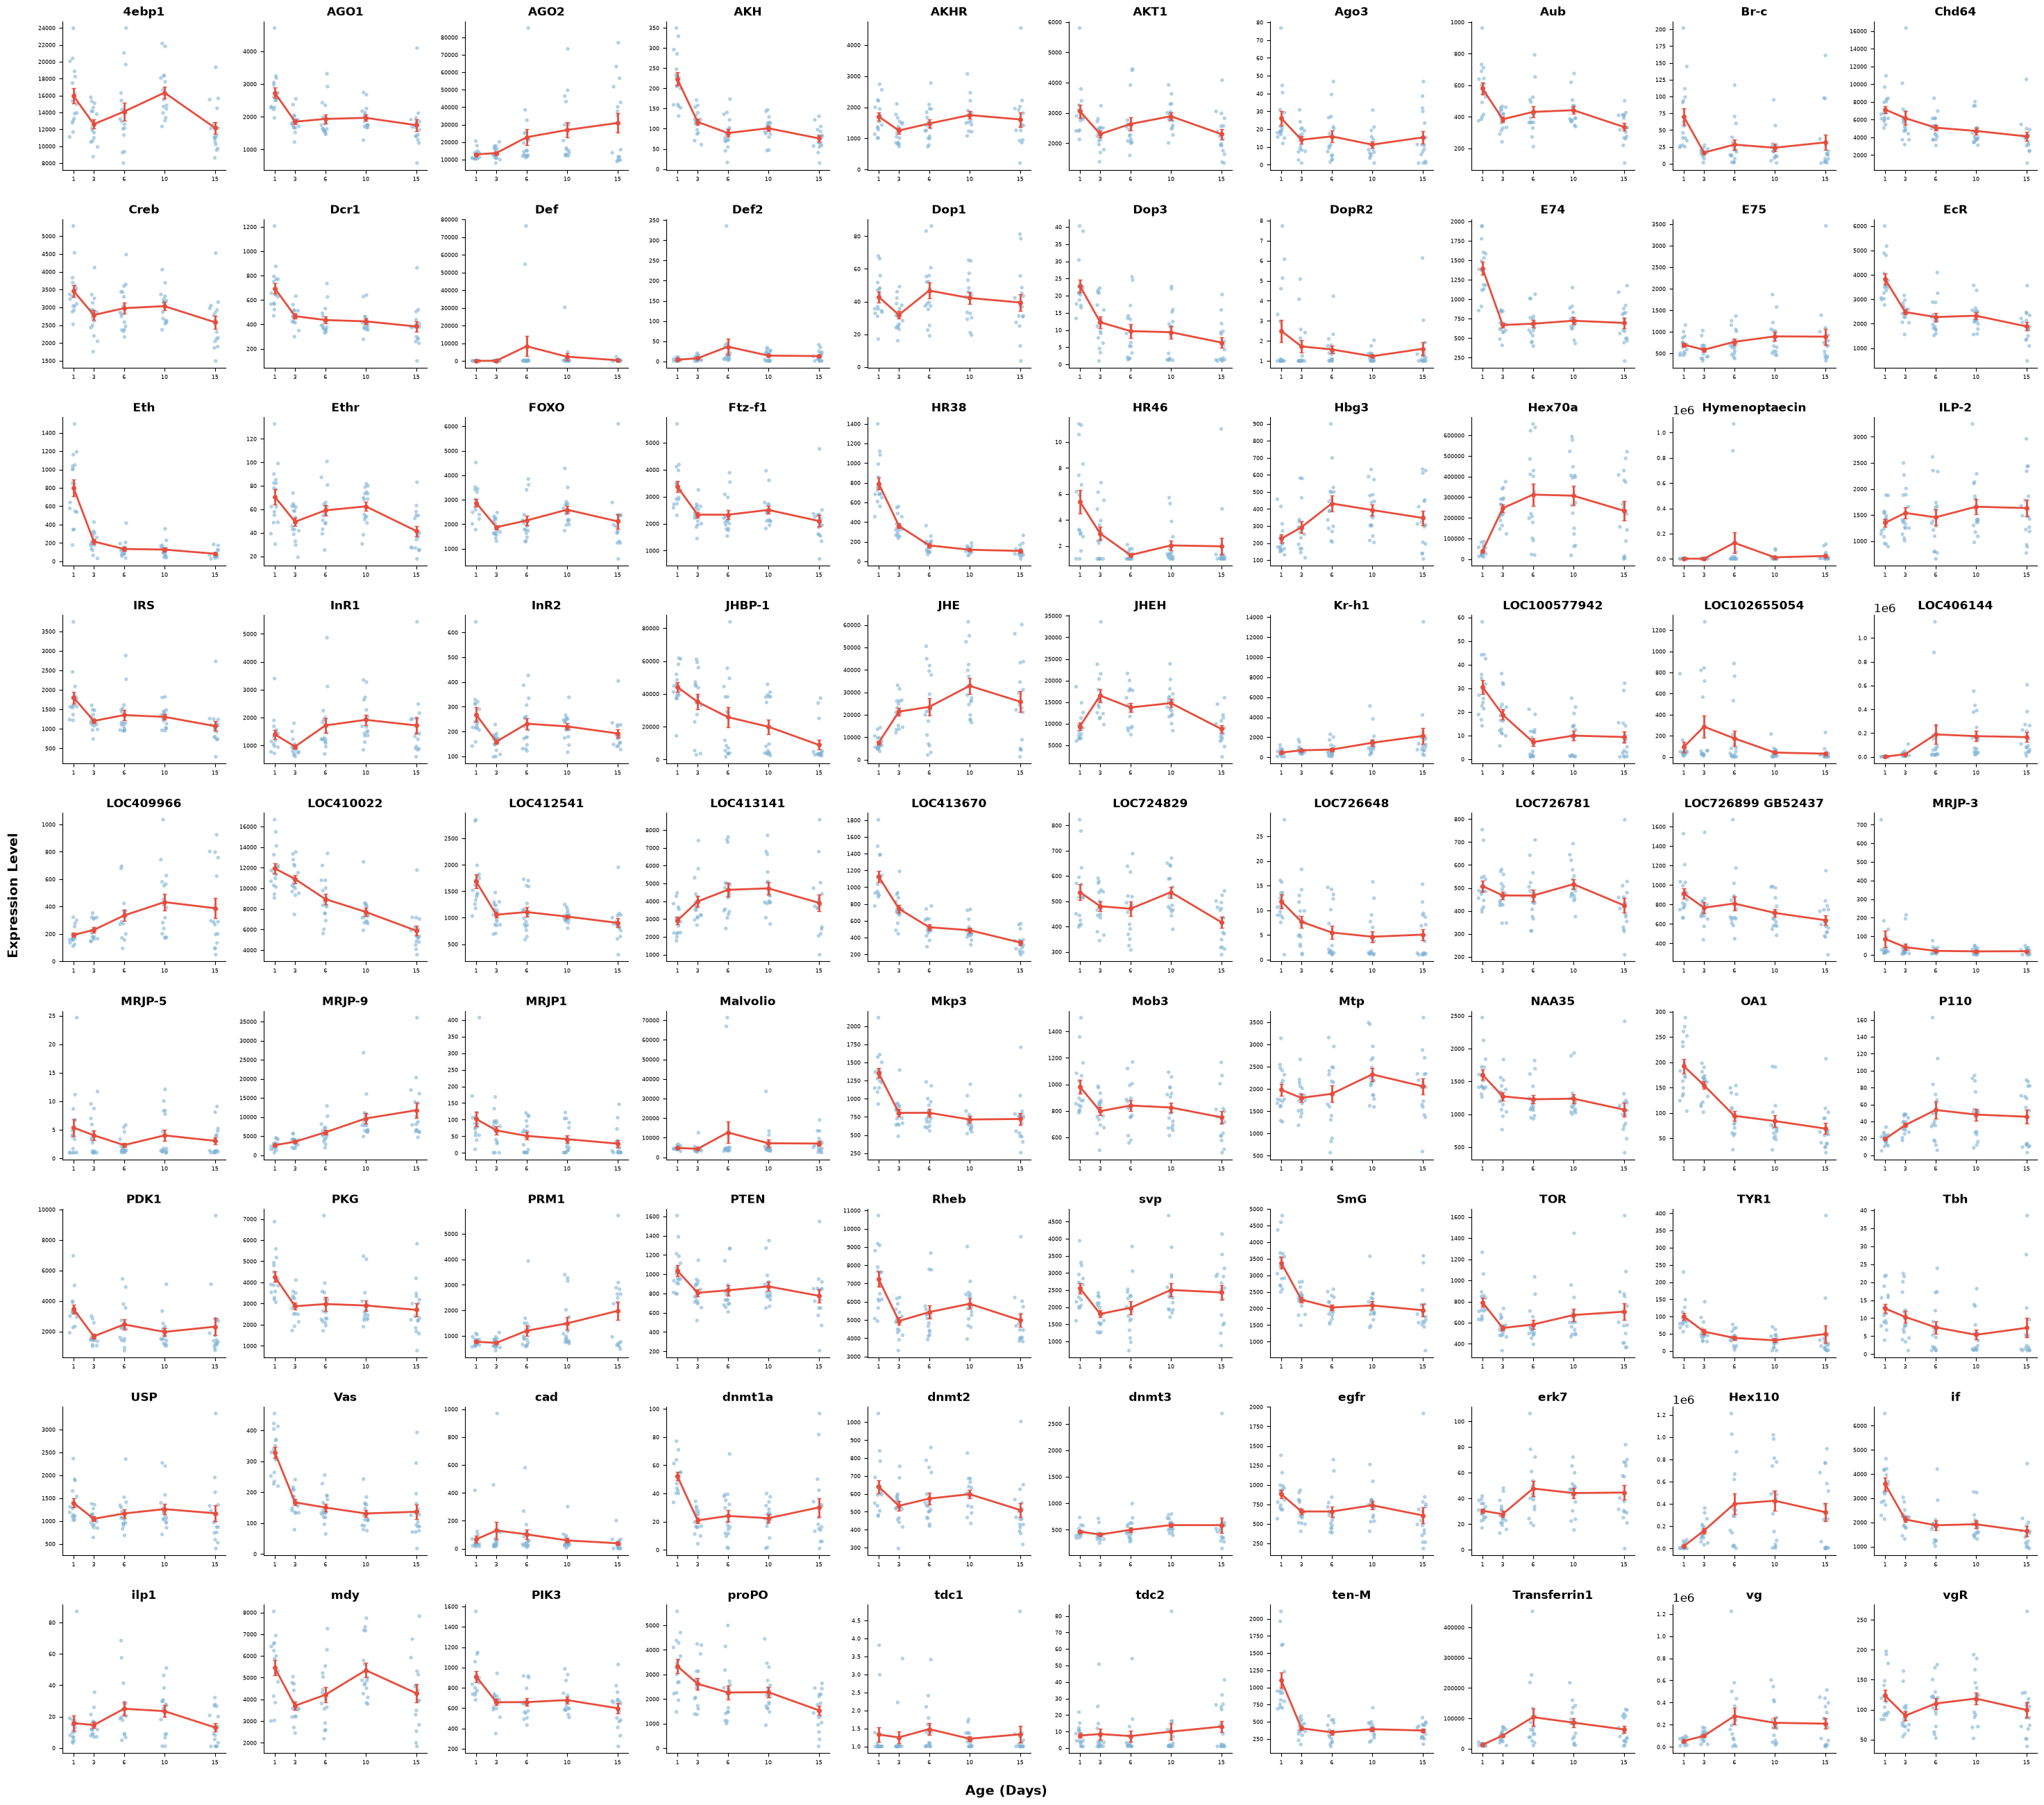

In [27]:
#Supplementary Figure

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the expression data
expr_df = pd.read_excel('Expression_raw_v1.xlsx')

# Get all gene columns (excluding Age and Vg protein normalized - but include vg)
gene_cols = [col for col in expr_df.columns if col not in ['Age (Days)', 'Vg protein normalized']]

# Create figure with subplots
n_genes = len(gene_cols)
n_cols = 10
n_rows = 9  # 9 rows x 10 cols = 90 plots

fig, axes = plt.subplots(n_rows, n_cols, figsize=(30, 27))
axes = axes.flatten()

# Colors for individual points and mean line
point_color = '#7FB3D5'  # Light blue for individual points
mean_color = '#E74C3C'   # Red for mean line
ages = [1, 3, 6, 10, 15]

for i, gene in enumerate(gene_cols):
    ax = axes[i]
    
    # Get data for this gene
    gene_data = expr_df[['Age (Days)', gene]].copy()
    
    # Plot individual points with jitter
    np.random.seed(42)
    for age in ages:
        age_values = gene_data[gene_data['Age (Days)'] == age][gene].values
        jitter = np.random.normal(0, 0.2, len(age_values))
        ax.scatter([age] * len(age_values) + jitter, age_values, 
                   c=point_color, s=15, alpha=0.6, edgecolors='none')
    
    # Calculate and plot mean ± SEM
    means = gene_data.groupby('Age (Days)')[gene].mean()
    sems = gene_data.groupby('Age (Days)')[gene].sem()
    
    ax.errorbar(ages, means.values, yerr=sems.values, 
                color=mean_color, linewidth=2, marker='o', markersize=4,
                capsize=2, capthick=1)
    
    # Set title and labels
    ax.set_title(gene, fontsize=12, fontweight='bold')
    ax.set_xticks(ages)
    ax.set_xticklabels(ages, fontsize=6)
    ax.tick_params(axis='y', labelsize=6)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide any unused subplots
for j in range(n_genes, len(axes)):
    axes[j].axis('off')

# Add common labels
fig.text(0.5, 0.02, 'Age (Days)', ha='center', fontsize=14, fontweight='bold')
fig.text(0.02, 0.5, 'Expression Level', va='center', rotation='vertical', fontsize=14, fontweight='bold')

# Add title
#fig.suptitle('Time Dynamics of All 90 Genes in Expression Data\n(Individual bees shown as blue dots, mean ± SEM in red)', fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0.03, 0.03, 1, 0.98])
#plt.savefig('/mnt/results/Figure12_all_genes_time_dynamics.png', dpi=200, bbox_inches='tight', facecolor='white')
#plt.savefig('/mnt/results/Figure12_all_genes_time_dynamics.svg', bbox_inches='tight', facecolor='white')
plt.show()

